# Predicting Contraceptive Use Among Kenyan Women
## Data Cleaning, EDA, Modelling & Deployment
### The Insight Architects Group

---

**Dataset:** Kenya Demographic and Health Survey (KDHS) 2022 — Women's Questionnaire  
**Respondents:** 32,156 women aged 15–49 across all 47 counties  
**Target Variable:** `contraceptive_use` — Type of contraceptive method currently used  
**Methodology:** CRISP-DM  
**Tools:** Python · scikit-learn · LightGBM · SHAP · Flask

---

> *"Behind every data point in this dataset is a real woman — a mother, a daughter, a community member — navigating her reproductive health choices within the realities of her county, her household, and her circumstances. This notebook is our attempt to let the data speak on her behalf."*
>
> — **The Insight Architects**

---

## 1. Business Understanding

### 1.1 Business Overview

Kenya's family planning story is one of remarkable progress shadowed by persistent inequality. Nationally, modern contraceptive use among married women has climbed steadily over the decades. But that national average hides a reality that aggregate statistics cannot capture: in Mandera, barely 1 in 100 women uses a modern method. In Embu, more than half do. That gap — over 50 percentage points — is not just a number. It represents women who lack access, information, or the agency to make reproductive choices that are freely available to women in other parts of the same country.

The 2022 Kenya Demographic and Health Survey gives us an unprecedented window into this inequality. With 32,156 respondents, it is the most detailed snapshot of Kenyan women's reproductive health in years. Our task is to move beyond describing that inequality — and toward predicting it, explaining it, and putting those predictions into the hands of the people who can act on them.

Kenya has made significant progress in family planning over the past three decades, yet contraceptive uptake remains deeply unequal across the country's 47 counties. The 2022 Kenya Demographic and Health Survey (KDHS), a nationally representative dataset of 32,156 women aged 15–49, captures this inequality in unprecedented detail — recording sociodemographic variables such as education, wealth, residence, marital status, and county of residence alongside contraceptive use patterns. Since manual analysis of such a large, multi-variable dataset is impractical for health planners, machine learning can be used to automatically identify the sociodemographic profiles of women most at risk of contraceptive non-use.

This project develops a contraceptive use prediction model using the 2022 KDHS dataset to help the Ministry of Health and family planning partners identify underserved population segments and deploy targeted interventions efficiently and at scale.

### 1.2 Problem Statement

Kenya's modern contraceptive prevalence rate among married women is approximately 60% nationally, but this average conceals major geographic and socioeconomic inequalities. In arid and semi-arid counties such as Turkana, West Pokot, and Mandera, contraceptive uptake falls 20–30 percentage points below the national average, while more urbanised counties like Nairobi and Kiambu report markedly higher rates. Without a data-driven segmentation of at-risk populations, health interventions are distributed uniformly rather than targeted where they are needed most.

**Key challenges include:**

- **Class imbalance** — modern method users (38%) significantly outnumber folkloric and traditional method users (4% combined)
- **High dimensionality** — 5,925 variables in the raw survey requiring careful feature selection down to the most relevant predictors
- **Multicollinearity** — closely related variables such as age, children ever born, and marital status overlap in predictive power
- **Categorical encoding** — ordinal variables like wealth index and education level require careful treatment to preserve their natural ordering

**Objective:** Build a model that accurately predicts contraceptive use among Kenyan women aged 15–49 using sociodemographic features, and identify which factors most strongly drive or prevent modern contraceptive uptake.

### 1.3 Stakeholders

| Stakeholder | How They Use This Model |
|---|---|
| Kenya Ministry of Health — Division of Reproductive Health | Identify counties and demographic groups with highest predicted non-use; allocate field officers and resources accordingly |
| County Health Management Teams (all 47 counties) | Generate county-specific risk profiles to guide local family planning outreach programmes |
| UNFPA Kenya Country Office | Target funding and technical assistance toward highest-risk population segments |
| USAID Kenya | Use model outputs to evaluate programme effectiveness and redirect investments to underserved regions |
| FP2030 Programme | Monitor progress toward family planning targets by tracking predicted non-use rates over time |
| Community Health Promoters (CHPs) | Use county-level risk scores to prioritise household visits in high-risk clusters |

### 1.4 Success Metrics

The model will be considered successful if:

- **Accuracy ≥ 78%** on the held-out test set
- **ROC-AUC ≥ 0.82**, measuring the model's ability to distinguish users from non-users
- **Macro F1-Score ≥ 0.75**, ensuring minority classes are not neglected
- **Balanced Precision and Recall**, especially for non-use prediction — failing to identify at-risk women has real public health consequences
- **SHAP explanations identify at least 5 key features** that policymakers can directly act on
- The model generalises to unseen data via stratified 5-fold cross-validation
- The model improves over a simple logistic regression baseline

### 1.5 Key Business Questions

1. What is the overall distribution of contraceptive use types (modern, traditional, folkloric, none) among Kenyan women aged 15–49?
2. Which counties have the highest predicted rates of contraceptive non-use, and what sociodemographic profiles characterise these women?
3. How do education level and wealth index jointly influence the likelihood of modern contraceptive use?
4. Does urban or rural residence remain a significant predictor of contraceptive use when controlling for wealth and education?
5. Which machine learning model best predicts contraceptive use, and which sociodemographic features are the strongest predictors according to SHAP analysis?

---

## Notebook Structure

| # | Section | CRISP-DM Phase |
|---|---|---|
| 1 | Setup & Imports | — |
| 2 | Data Loading & Initial Inspection | Data Understanding |
| 3 | Pre-Cleaning Audit | Data Understanding |
| 4 | Data Cleaning Pipeline | Data Preparation |
| 5 | Post-Cleaning Validation | Data Preparation |
| 6 | Before vs. After Comparison | Data Preparation |
| 7.1 | EDA — Univariate | Data Understanding |
| 7.2 | EDA — Bivariate | Data Understanding |
| 7.3 | EDA — Multivariate | Data Understanding |
| 8 | Key EDA Findings & Modelling Implications | Data Understanding |
| 9 | Feature Engineering | Data Preparation |
| 10 | Train / Test Split & Class Imbalance Handling | Data Preparation |
| 11.1 | Baseline Model — Logistic Regression | Modelling |
| 11.2 | Model 2 — Random Forest | Modelling |
| 11.3| Model 3 — LightGBM (Tuned) | Modelling |
| 11.4| MLP | Modelling |
| 11.5| Tab Transformer | Modelling |
| 12 | Model Comparison & Selection | Evaluation |
| 13| Hyperparameter Tuning |Evaluation|
| 14 | SHAP Explainability | Evaluation |
| 15 | Business Recommendations | Evaluation |
| 16 | Deployment — Flask API | Deployment |

## 2. Setup & Imports

In [1]:
! pip install shap

In [2]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import os, warnings, joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (9, 5)
os.makedirs('images', exist_ok=True)

# Modelling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder, StandardScaler,
                                    LabelEncoder, label_binarize)
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve,
                             average_precision_score, precision_recall_curve)
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import shap
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("Libraries imported successfully ✓")

Libraries imported successfully ✓


## 3. Data Understanding

The raw file has 5,925 columns. We have loaded only the 17 theory-driven predictors plus the target and the unique respondent id `caseid`. Variable codes were verified against the **DHS-7 Standard Recode Manual**.

#### Data Loading

In [3]:
# Selected DHS variables (verified against the DHS-7 Recode Manual)
cols_needed = ['caseid','v012','v013','v024','v025','v106','v190','v501','v502',
               'v201','v218','v228','v714','v136','v130','v151',
               'v701','v212','v302a','v313']

df = pd.read_csv('KDHS_2022_women.csv', usecols=cols_needed, low_memory=False)

df.rename(columns={
    'v012':'age', 'v013':'age_group', 'v024':'county', 'v025':'residence_type',
    'v106':'education_level', 'v190':'wealth_index', 'v501':'marital_status',
    'v502':'union_status', 'v201':'children_ever_born', 'v218':'living_children',
    'v228':'pregnancy_loss', 'v714':'currently_working', 'v136':'household_size',
    'v130':'religion', 'v151':'household_head_sex', 'v701':'partner_education',
    'v212':'age_first_birth', 'v302a':'ever_used_contraceptive', 'v313':'contraceptive_use'
}, inplace=True)

print('Shape:', df.shape)
df.head()

Shape: (32156, 20)


,caseid,age,age_group,county,residence_type,education_level,religion,household_size,household_head_sex,wealth_index,children_ever_born,age_first_birth,living_children,pregnancy_loss,ever_used_contraceptive,contraceptive_use,marital_status,union_status,partner_education,currently_working
0,1 4 2,34,4,1,1,0,7,6,1,4,4,21.0,4,0,0,0,1,1,0.0,0
1,1 7 2,38,5,1,1,2,1,3,1,5,1,22.0,1,1,2,3,1,1,3.0,0
2,1 10 1,33,4,1,1,1,1,2,2,5,1,21.0,1,0,2,3,4,2,NaN,1
3,1 13 2,39,5,1,1,2,1,8,1,5,5,19.0,5,0,2,3,1,1,1.0,1
4,1 20 2,30,4,1,1,1,96,4,1,4,2,20.0,2,0,0,0,2,1,1.0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32156 entries, 0 to 32155
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   caseid                   32156 non-null  object 
 1   age                      32156 non-null  int64  
 2   age_group                32156 non-null  int64  
 3   county                   32156 non-null  int64  
 4   residence_type           32156 non-null  int64  
 5   education_level          32156 non-null  int64  
 6   religion                 32156 non-null  int64  
 7   household_size           32156 non-null  int64  
 8   household_head_sex       32156 non-null  int64  
 9   wealth_index             32156 non-null  int64  
 10  children_ever_born       32156 non-null  int64  
 11  age_first_birth          23343 non-null  float64
 12  living_children          32156 non-null  int64  
 13  pregnancy_loss           32156 non-null  int64  
 14  ever_used_contraceptiv

#### A Quick Numeric Summary

Before we clean anything, we take a look at the raw numbers — not to draw conclusions yet, but just to check that the ranges make sense and nothing looks obviously wrong. Some columns like education and wealth are still stored as DHS integer codes here, so the numbers will not mean much on their own. We are mainly looking for anything unusual, like a negative age or a variable with an extreme outlier.

In [5]:
print("Rows and columns:", df.shape)
df.describe().T

Rows and columns: (32156, 20)


,count,mean,std,min,25%,50%,75%,max
age,32156.0,29.142617,9.546172,15.0,21.0,28.0,36.0,49.0
age_group,32156.0,3.439327,1.895748,1.0,2.0,3.0,5.0,7.0
county,32156.0,24.814716,13.788612,1.0,13.0,26.0,37.0,47.0
residence_type,32156.0,1.614815,0.486647,1.0,1.0,2.0,2.0,2.0
education_level,32156.0,1.545963,0.888795,0.0,1.0,2.0,2.0,3.0
religion,32156.0,5.366401,14.473739,1.0,2.0,2.0,4.0,96.0
household_size,32156.0,5.424555,2.645393,1.0,4.0,5.0,7.0,24.0
household_head_sex,32156.0,1.383692,0.486292,1.0,1.0,1.0,2.0,2.0
wealth_index,32156.0,2.967160,1.416338,1.0,2.0,3.0,4.0,5.0
children_ever_born,32156.0,2.406425,2.364101,0.0,0.0,2.0,4.0,15.0


#### Data Preview

Here is what the raw data looks like — column names and the first few rows — before any cleaning or decoding is applied.

In [6]:
# 3.1 Checking for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])

Missing values per column:
age_first_birth       8813
partner_education    14039
dtype: int64


In [7]:
# 3.2 Target variable — raw distribution before decoding
target_labels = {0:'No method', 1:'Folkloric', 2:'Traditional', 3:'Modern'}
print('Target (contraceptive_use) distribution:')
print(df['contraceptive_use'].map(target_labels).value_counts())
print()
print((df['contraceptive_use'].map(target_labels).value_counts(normalize=True)*100).round(1))

Target (contraceptive_use) distribution:
contraceptive_use
No method      18694
Modern         12195
Traditional     1214
Folkloric         53
Name: count, dtype: int64

contraceptive_use
No method      58.1
Modern         37.9
Traditional     3.8
Folkloric       0.2
Name: proportion, dtype: float64


In [8]:
# 3.3 Checking for duplicates — are they real, or just women with similar profiles?

# pandas flags 274 rows that repeat an earlier row (this is what .duplicated() counts):
print('Rows pandas would call duplicates:', df.drop(columns='caseid').duplicated().sum())

# Now marking all rows involved in a look-alike (both the original AND its copy):
look_alike = df.drop(columns='caseid').duplicated(keep=False)
print('Total rows that have a look-alike:', look_alike.sum())

# If these were real duplicates, the IDs would repeat.
# Checking how many DIFFERENT women (unique caseids) these rows actually are:
print('Number of different women among them:', df.loc[look_alike, 'caseid'].nunique())

Rows pandas would call duplicates: 274
Total rows that have a look-alike: 532
Number of different women among them: 532


**Finding: there are no real duplicates.**

Pandas flags 274 rows as "duplicates," and in total 532 rows share a look-alike profile across our selected columns. But when we check their respondent IDs (`caseid`), all 532 belong to **different women**. They simply share the same age, county, education level, and so on — which is perfectly plausible in a country of millions.

Think of it like two students who are both "16, from Nairobi, in Form 3." On paper they look identical, but they are still two different people with two different admission numbers. We have not dropped any rows.

## 4. Data Cleaning

Real-world survey data is never perfectly ready to model. The KDHS is better than most — it is carefully designed and nationally representative — but it still needs deliberate handling. We made three specific decisions here, and we want to be transparent about each one.

1. **Decoding** the numeric DHS codes into plain-English labels
2. **Handling structural missing values correctly** — the gaps are "not applicable," not errors
3. **Keeping all rows** — even the apparent duplicates, which turn out not to be real duplicates at all

#### 4.1 Decoding Categorical Codes

The raw DHS file stores every categorical variable as a number. Education level 1 means Primary; wealth quintile 3 means Middle; and so on. Working with raw numbers would make every chart and model output confusing to read and easy to misinterpret. We translate every code into its plain-English label using the DHS-7 Recode Manual as our reference.

In [9]:
label_maps = {
    'residence_type':     {1:'Urban', 2:'Rural'},
    'education_level':    {0:'No education', 1:'Primary', 2:'Secondary', 3:'Higher'},
    'wealth_index':       {1:'Poorest', 2:'Poorer', 3:'Middle', 4:'Richer', 5:'Richest'},
    'household_head_sex': {1:'Male', 2:'Female'},
    'currently_working':  {0:'No', 1:'Yes'},
    'pregnancy_loss':     {0:'No', 1:'Yes'},
    'marital_status':     {0:'Never married', 1:'Married', 2:'Living together',
                           3:'Widowed', 4:'Divorced', 5:'Separated'},
    'union_status':       {0:'Never in union', 1:'Currently in union', 2:'Formerly in union'},
    'age_group':          {1:'15-19',2:'20-24',3:'25-29',4:'30-34',5:'35-39',6:'40-44',7:'45-49'},
    'contraceptive_use':  {0:'No method', 1:'Folkloric', 2:'Traditional', 3:'Modern'},
    'religion':           {1:'Roman Catholic', 2:'Protestant/Other Christian',
                           3:'Evangelical/Born Again', 4:'African Instituted Church',
                           5:'Orthodox', 7:'Muslim', 8:'Hindu', 9:'Traditionalist',
                           10:'No religion', 96:'Other'},
}
county_map = {1:'Mombasa',2:'Kwale',3:'Kilifi',4:'Tana River',5:'Lamu',6:'Taita Taveta',
 7:'Garissa',8:'Wajir',9:'Mandera',10:'Marsabit',11:'Isiolo',12:'Meru',13:'Tharaka-Nithi',
 14:'Embu',15:'Kitui',16:'Machakos',17:'Makueni',18:'Nyandarua',19:'Nyeri',20:'Kirinyaga',
 21:"Murang'a",22:'Kiambu',23:'Turkana',24:'West Pokot',25:'Samburu',26:'Trans Nzoia',
 27:'Uasin Gishu',28:'Elgeyo Marakwet',29:'Nandi',30:'Baringo',31:'Laikipia',32:'Nakuru',
 33:'Narok',34:'Kajiado',35:'Kericho',36:'Bomet',37:'Kakamega',38:'Vihiga',39:'Bungoma',
 40:'Busia',41:'Siaya',42:'Kisumu',43:'Homa Bay',44:'Migori',45:'Kisii',46:'Nyamira',47:'Nairobi'}

for col, m in label_maps.items():
    df[col] = df[col].map(m)
df['county'] = df['county'].map(county_map)

# Ever-used (V302A): behavioural pattern variable, decoded for EDA only.
df['ever_used_contraceptive'] = df['ever_used_contraceptive'].map(
    {0:'Never used', 1:'Used previously', 2:'Currently using'})

print('Decoded. Example rows:')
df[['county','education_level','wealth_index','marital_status','contraceptive_use']].head()

Decoded. Example rows:


,county,education_level,wealth_index,marital_status,contraceptive_use
0,Mombasa,No education,Richer,Married,No method
1,Mombasa,Secondary,Richest,Married,Modern
2,Mombasa,Primary,Richest,Divorced,Modern
3,Mombasa,Secondary,Richest,Married,Modern
4,Mombasa,Primary,Richer,Living together,No method


#### 4.2 Handling Missing Values

Two columns have missing values — but neither gap is a mistake. They are **structural absences**, meaning the question simply did not apply to that woman.

**`age_first_birth` — 8,813 missing values.**  
Every single missing value here belongs to a woman who has never given birth. She cannot have an "age at first birth" because she has not had one. Rather than imputing a number we would be inventing, we fill the gap with zero and create a separate `has_given_birth` flag that explicitly tells the model whether the woman has ever had a child.

**`partner_education` — missing for women with no current partner.**  
These women do not have a partner whose education we can record. We fill the gap with the string `'No partner'`, turning it into a valid sixth category rather than a hole in the data.

In [10]:
# --- age_first_birth ---
# Confirming that every missing value is a woman with no children.
missing_afb = df['age_first_birth'].isna()
print('age_first_birth missing:', missing_afb.sum(),
      '| of those with 0 children:', (df.loc[missing_afb, 'children_ever_born'] == 0).sum())

# Making a yes/no column for "has she ever given birth?", then fill the blank with 0 = "not applicable".
df['has_given_birth'] = df['age_first_birth'].notna().astype(int)
df['age_first_birth'] = df['age_first_birth'].fillna(0)

# --- partner_education ---
# Turning the codes into labels, and fill the blanks with a clear "No partner" category.
df['partner_education'] = df['partner_education'].map(
    {0: 'No education', 1: 'Primary', 2: 'Secondary', 3: 'Higher'}).fillna('No partner')

# Checking: there should now be no missing values left anywhere.
print('Remaining missing values in full frame:', int(df.isnull().sum().sum()))

age_first_birth missing: 8813 | of those with 0 children: 8813
Remaining missing values in full frame: 0


#### 4.3 Keeping All Rows

As established in Section 3, the 274 apparent duplicates are not real duplicates — they are distinct women who happen to share the same profile across our selected columns. We keep all 32,156 rows.

In [11]:
print('Rows retained (no rows dropped):', df.shape[0])

Rows retained (no rows dropped): 32156


#### 4.4 Post-Cleaning Validation

Before moving on, we run two quick checks to confirm the cleaning pipeline did exactly what we intended.

In [12]:
assert df.isnull().sum().sum() == 0, 'There are still missing values!'
assert df.shape[0] == 32156, 'Row count changed unexpectedly!'
print('Validation passed.')
print('Final shape:', df.shape)
print('\nDtypes:\n', df.dtypes)

Validation passed.
Final shape: (32156, 21)

Dtypes:
 caseid                      object
age                          int64
age_group                   object
county                      object
residence_type              object
education_level             object
religion                    object
household_size               int64
household_head_sex          object
wealth_index                object
children_ever_born           int64
age_first_birth            float64
living_children              int64
pregnancy_loss              object
ever_used_contraceptive     object
contraceptive_use           object
marital_status              object
union_status                object
partner_education           object
currently_working           object
has_given_birth              int64
dtype: object


#### 4.5 Before & After

A summary table showing what changed between the raw file and the cleaned dataset.

In [13]:
summary = pd.DataFrame({
    'Stage': ['Raw', 'Cleaned'],
    'Rows': [32156, df.shape[0]],
    'Columns': [20, df.shape[1]],
    'Missing values': [8813+14039, int(df.isnull().sum().sum())],
})
summary

,Stage,Rows,Columns,Missing values
0,Raw,32156,20,22852
1,Cleaned,32156,21,0


## 5. Exploratory Data Analysis

Before we build anything, we need to genuinely understand the data. Not just describe it — understand it. What does the contraceptive landscape look like across Kenya? Where are the big gaps? Which variables seem to matter, and which ones are less useful than they first appear?

This section works through three layers of analysis — each one building on what came before:

1. **Univariate** — how is each variable distributed on its own?
2. **Bivariate** — how does contraceptive use vary across different groups?
3. **Multivariate** — what happens when we look at variables together? Do the simple patterns hold up?

Every visual here directly informs a decision we make in the modelling sections that follow.

### Univariate Analysis

We start by looking at each variable on its own — before bringing in any comparisons. This tells us about the shape of the data: what is common, what is rare, and what kind of variation we are working with.

#### 5.1 Distribution of Contraceptive Use (Target Variable)

*Business Question 1: What is the overall distribution of contraceptive use types among Kenyan women aged 15–49?*

We start with the target. How the four classes are distributed tells us immediately whether we have a class imbalance problem — and what kind of problem it is. This single chart sets up much of what follows.

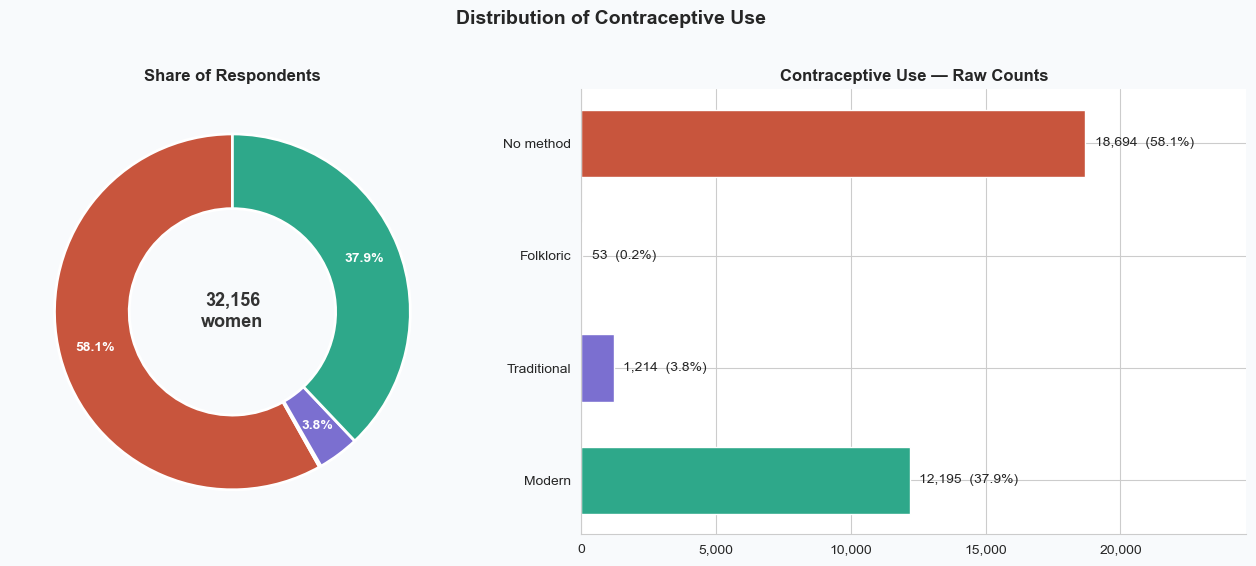

Percentage breakdown:
contraceptive_use
No method      58.1
Modern         37.9
Traditional     3.8
Folkloric       0.2
Name: proportion, dtype: float64


In [14]:
# 5.1 — Target variable: donut chart + horizontal bar side by side
order  = ['No method', 'Folkloric', 'Traditional', 'Modern']
colors = {'No method': '#C8553D', 'Folkloric': '#F2B134',
          'Traditional': '#7B6FD0', 'Modern': '#2EA88A'}

counts   = df['contraceptive_use'].value_counts().reindex(order)
col_list = [colors[c] for c in order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5),
                                gridspec_kw={'width_ratios': [1, 1.3]})
fig.patch.set_facecolor('#F8FAFC')

# Donut
wedges, _, autotexts = ax1.pie(
    counts.values, labels=None, colors=col_list,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    pctdistance=0.8, startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2)
)
for t in autotexts:
    t.set_color("white"); t.set_fontweight("bold")
ax1.text(0, 0, f"{len(df):,}\nwomen", ha="center", va="center",
         fontsize=13, fontweight="bold", color="#333")
ax1.set_title("Share of Respondents", fontsize=12, fontweight="bold")

# Horizontal bar
bars = ax2.barh(counts.index[::-1], counts.values[::-1],
                color=[colors[c] for c in counts.index[::-1]], height=0.6)
for b, v in zip(bars, counts.values[::-1]):
    ax2.text(v + 350, b.get_y() + b.get_height() / 2,
             f"{v:,}  ({v/len(df)*100:.1f}%)", va="center", fontsize=10)
ax2.set_xlim(0, counts.max() * 1.32)
ax2.set_title("Contraceptive Use — Raw Counts", fontsize=12, fontweight="bold")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax2.spines[["top","right"]].set_visible(False)
ax2.set_facecolor("white")

plt.suptitle("Distribution of Contraceptive Use", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("images/target_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

print("Percentage breakdown:")
print((df["contraceptive_use"].value_counts(normalize=True) * 100).round(1))

##### Insight
Most women fall into just two groups — **"No method" (58.1%)** and **"Modern" (37.9%)** — while Traditional (3.8%) and especially Folkloric (53 women, 0.2%) are very small. This is a serious class imbalance, and the Folkloric group in particular is too small to predict reliably with any standard approach. This is why we will apply SMOTE to the training data and use macro-averaged metrics rather than raw accuracy when evaluating models.

#### 5.2 Age Distribution

Age is one of the strongest predictors of contraceptive use — older women have been exposed to pregnancy risk for longer, are more likely to be in stable unions, and are more likely to have reached the family size they want. So we look at how old the women in this sample are, and whether the age spread gives us enough variation to work with.

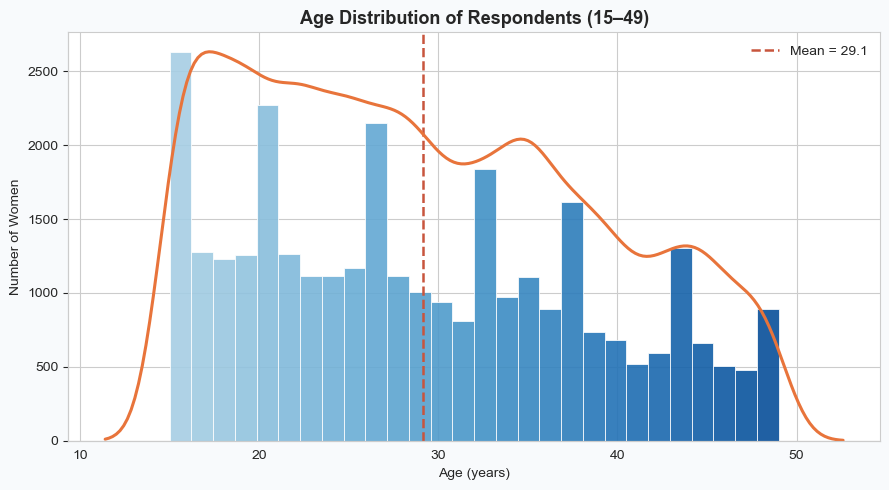

Average age: 29.1  |  Median: 28


In [15]:
# 5.2 — Age distribution: gradient histogram + KDE overlay + mean line
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#F8FAFC')

n, bins, patches = ax.hist(df["age"], bins=28, edgecolor="white", linewidth=0.6, alpha=0.9)
cmap = plt.cm.Blues
for patch, b in zip(patches, bins):
    patch.set_facecolor(cmap(0.35 + 0.55 * (b - 15) / (49 - 15)))

ax2 = ax.twinx()
sns.kdeplot(df["age"], ax=ax2, color="#E8743B", linewidth=2.2)
ax2.set_yticks([]); ax2.set_ylabel("")

ax.axvline(df["age"].mean(), color="#C8553D", linestyle="--", linewidth=1.8,
           label=f"Mean = {df['age'].mean():.1f}")
ax.set_title("Age Distribution of Respondents (15–49)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Age (years)"); ax.set_ylabel("Number of Women")
ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig("images/age_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Average age: {df['age'].mean():.1f}  |  Median: {int(df['age'].median())}")

##### Insight
Most of the women are in their twenties (average age about 29, median 28), and the numbers thin out towards 49. That fits the survey, since it only covers women of reproductive age (15 to 49). Because use of contraception changes a lot with age, age should be a useful predictor later.

#### 5.3 Education Level

Here we see how far the women in the sample went in school.

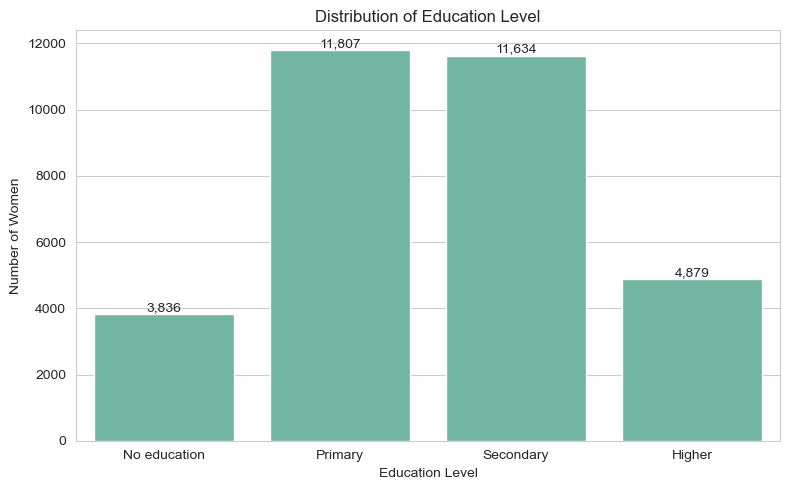

education_level
Primary         36.7
Secondary       36.2
Higher          15.2
No education    11.9
Name: proportion, dtype: float64


In [16]:
# Education Level

edu_order = ['No education', 'Primary', 'Secondary', 'Higher']

plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='education_level', order=edu_order)

# writing the count on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Women")
plt.tight_layout()
plt.savefig('images/education_distribution.png', dpi=120)
plt.show()

print((df['education_level'].value_counts(normalize=True) * 100).round(1))

##### Insight
Primary and secondary are the most common levels (about 37% each), higher education is about 15%, and roughly 12% of the women have no education at all.Since education influences health awareness and access to reproductive health information, this variable is expected to play an important role in predicting contraceptive use. These findings suggest that education should be retained as an important predictor during model development.

#### 5.4 Wealth Index

The wealth index groups households from poorest to richest. We check that every group is well represented.

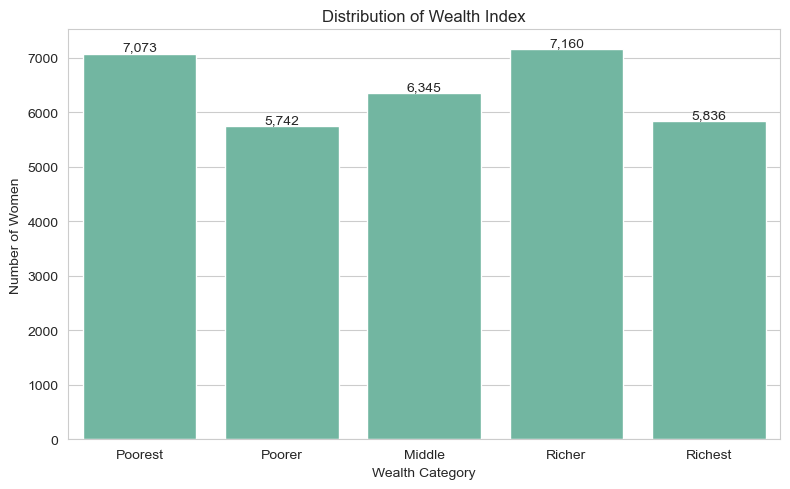

wealth_index
Richer     22.3
Poorest    22.0
Middle     19.7
Richest    18.1
Poorer     17.9
Name: proportion, dtype: float64


In [17]:
# Wealth Index

wealth_order = ['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest']

plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='wealth_index', order=wealth_order)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of Wealth Index")
plt.xlabel("Wealth Category")
plt.ylabel("Number of Women")
plt.tight_layout()
plt.savefig('images/wealth_distribution.png', dpi=120)
plt.show()

print((df['wealth_index'].value_counts(normalize=True) * 100).round(1))

##### Insight
The five wealth groups are fairly evenly represented (each is roughly 18 to 22% of the sample), so we have enough women in every economic group to compare them fairly. The wealth index may therefore have a significant relationship with contraceptive uptake and is an important feature for predictive modelling. The balanced representation across wealth categories reduces the likelihood of biased model predictions

#### 5.5 Residence Type

We also check how many women live in urban versus rural areas.

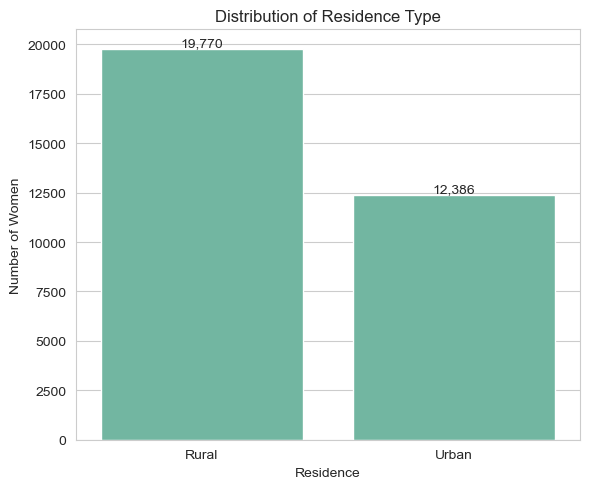

residence_type
Rural    61.5
Urban    38.5
Name: proportion, dtype: float64


In [18]:
# Residence Type

plt.figure(figsize=(6,5))
ax = sns.countplot(data=df, x='residence_type', order=['Rural', 'Urban'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of Residence Type")
plt.xlabel("Residence")
plt.ylabel("Number of Women")
plt.tight_layout()
plt.savefig('images/residence_distribution.png', dpi=120)
plt.show()

print((df['residence_type'].value_counts(normalize=True) * 100).round(1))

##### Insight
About 62% of the women live in rural areas and 38% in urban areas which reflects that the dataset contains respondents from both rural and urban settings, ensuring geographical diversity.Rural respondents form the majority. Residence type may influence contraceptive use due to differences in healthcare accessibility, availability of family planning services, education levels, and economic opportunities. This variable is therefore expected to contribute meaningful information during classification.

### Bivariate Analysis

Now we start making comparisons. For each key variable, we look at whether modern contraceptive use is higher or lower within different groups. This is where we start to see which factors actually make a difference.

We use percentages rather than raw counts throughout this section — because each group has a different number of women, and using counts would make larger groups look better simply because they have more people in them.

In each chart, two bars are shown for each group: the share of women using a modern method, and the share not using one. Together they always add up to 100%.

##### Defining the Modelling Target

For the bivariate analysis, we simplify the target variable into a binary: **modern method vs. everything else**. There are two reasons for this.

First, it directly tracks the modern contraceptive prevalence rate (mCPR) — the figure that the Ministry of Health, UNFPA, and FP2030 actually monitor and report against. Second, the Folkloric group has only 53 women, which is too small to predict or to oversample meaningfully in a multi-class setting.

We will still train a full four-class model later — but for the purposes of understanding which groups use modern methods and which do not, binary framing is clearer and more honest.

In [19]:
# creating a simple yes/no column: 1 if she uses a modern method, 0 otherwise
df['uses_modern'] = (df['contraceptive_use'] == 'Modern').astype(int)

# a small helper so we do not repeat the plotting code for every group.
# it shows, within each group, the share using a modern method and the share not using one
# (the two always add up to 100%).
def modern_vs_not_plot(column, order, title, filename):
    share = (df.groupby(column)['uses_modern']
               .value_counts(normalize=True)
               .rename('proportion')
               .reset_index())
    share['Method'] = share['uses_modern'].map({1: 'Modern', 0: 'Not modern'})
    share['percent'] = share['proportion'] * 100

    plt.figure(figsize=(8,5))
    ax = sns.barplot(data=share, x=column, y='percent', hue='Method',
                     order=order, hue_order=['Modern', 'Not modern'])

    # writing the percentage on top of each bar
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.0f}%',
                        (p.get_x() + p.get_width()/2, p.get_height()),
                        ha='center', va='bottom', fontsize=9)

    plt.title(title)
    plt.ylabel("% of women in the group")
    plt.xlabel(column.replace('_', ' ').title())
    plt.legend(title="")
    plt.tight_layout()
    plt.savefig(f'images/{filename}.png', dpi=120)
    plt.show()

#### 5.6 Modern vs Not-modern Use by Education Level

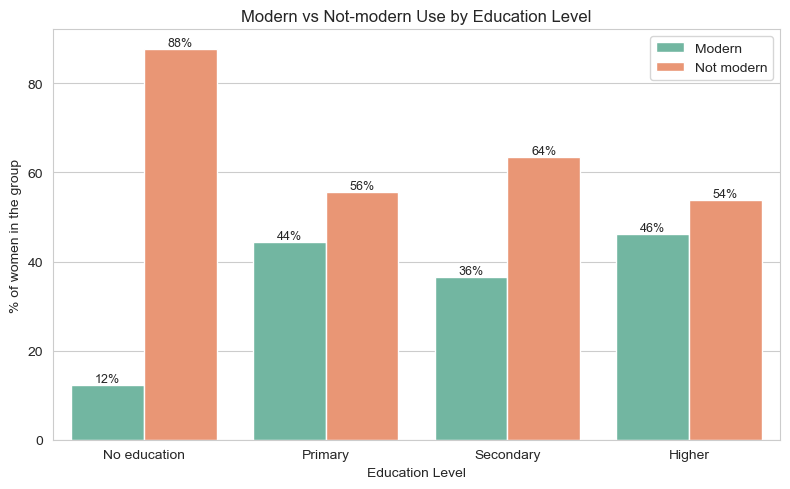

In [20]:
modern_vs_not_plot('education_level',
                   ['No education', 'Primary', 'Secondary', 'Higher'],
                   "Modern vs Not-modern Use by Education Level",
                   "use_by_education")

##### Insight
The clearest gap is between women with no education (only about 12% use a modern method) and women with any education (around 37 to 46%). The rise is not a straight line though, primary-educated women (44%) are actually a bit higher than secondary-educated women (37%). This is probably because many secondary-age women are younger and not yet married. The main takeaway is that having no education is strongly linked to very low modern use.

#### 5.7 Modern vs Not-modern Use by Wealth Index

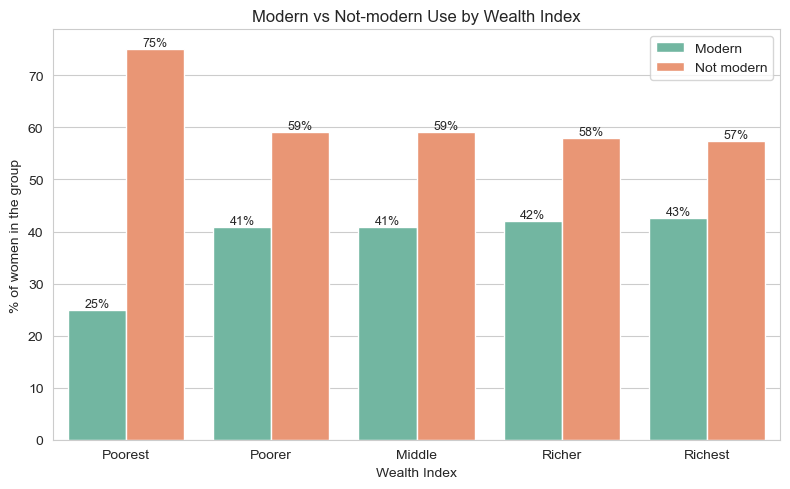

In [21]:
modern_vs_not_plot('wealth_index',
                   ['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest'],
                   "Modern vs Not-modern Use by Wealth Index",
                   "use_by_wealth")

##### Insight
The poorest women stand out with the lowest modern use (about 25%). Above the poorest group, the rate is fairly flat at around 41 to 43%. So the big wealth gap is between the poorest and everyone else, not a steady climb from poor to rich.

#### 5.8 Modern vs Not-modern Use by Residence Type

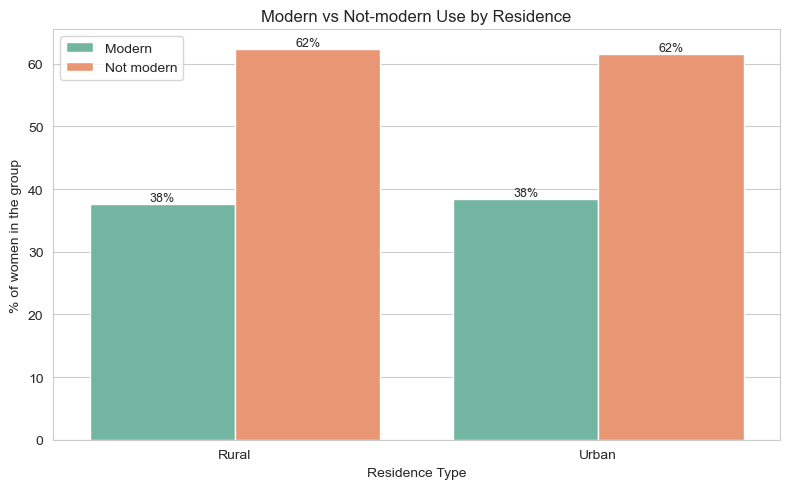

In [22]:
modern_vs_not_plot('residence_type',
                   ['Rural', 'Urban'],
                   "Modern vs Not-modern Use by Residence",
                   "use_by_residence")

##### Insight
Urban and rural women use modern methods at almost exactly the same rate (about 38% each). So on its own, where a woman lives barely makes a difference. This is a useful finding: any urban/rural gap people expect is likely explained by other things like education and wealth, not by residence itself. We check this properly in the multivariate section.

#### 5.9 Modern Use by County

**Business Question 2** : which counties have the lowest use, and therefore the highest non-use?

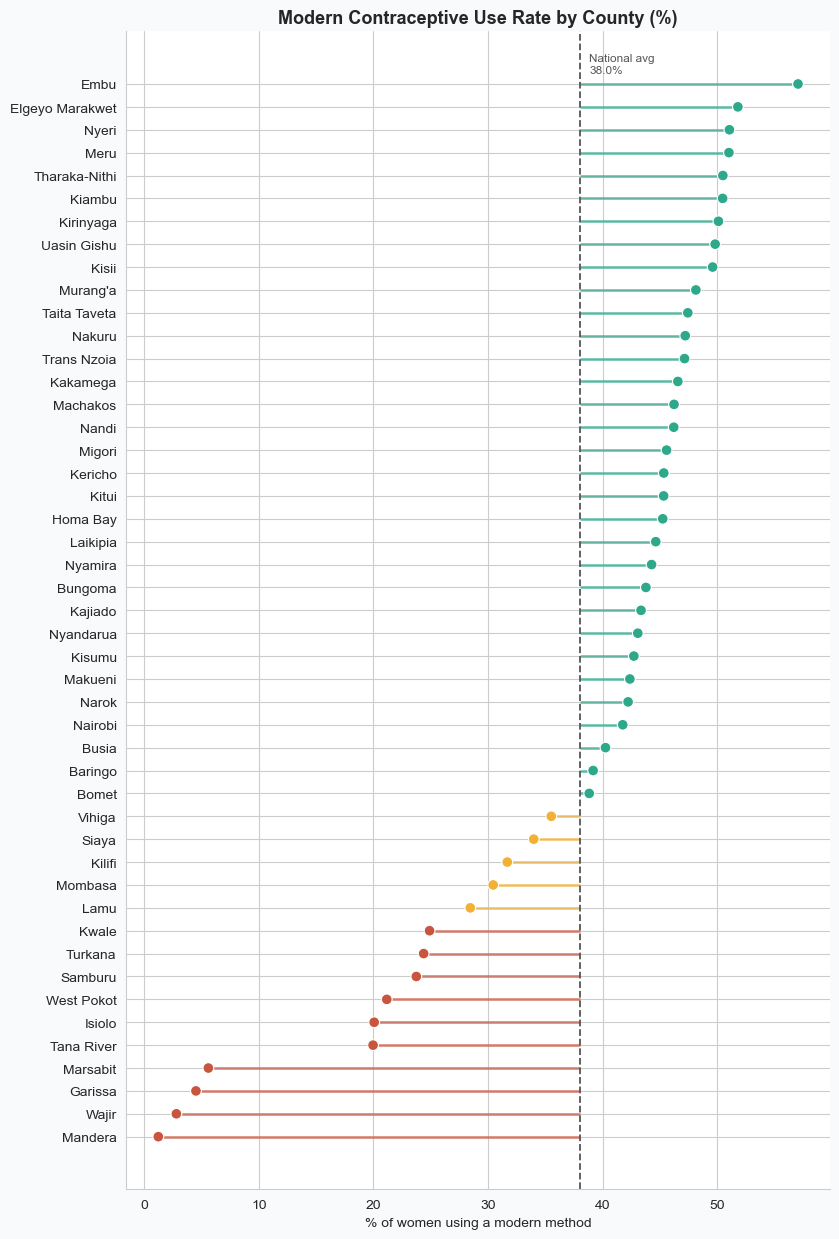

Lowest 5 counties:
county
Mandera        1.2
Wajir          2.8
Garissa        4.5
Marsabit       5.6
Tana River    20.0
Name: uses_modern, dtype: float64

Highest 5 counties:
county
Tharaka-Nithi      50.5
Meru               51.0
Nyeri              51.0
Elgeyo Marakwet    51.8
Embu               57.0
Name: uses_modern, dtype: float64


In [23]:
# 5.9 — County modern-use rate: diverging lollipop, colour-coded
county_rate  = df.groupby("county")["uses_modern"].mean().mul(100).sort_values()
national_avg = county_rate.mean()

fig, ax = plt.subplots(figsize=(8.5, 12.5))
fig.patch.set_facecolor('#F8FAFC')

dot_colors = ["#C8553D" if v < national_avg - 10 else "#F2B134" if v < national_avg else "#2EA88A"
              for v in county_rate.values]

ax.hlines(county_rate.index, national_avg, county_rate.values,
          color=dot_colors, linewidth=2, alpha=0.65)
ax.scatter(county_rate.values, county_rate.index, color=dot_colors,
           s=60, zorder=3, edgecolor="white", linewidth=0.8)
ax.axvline(national_avg, color="#555", linestyle="--", linewidth=1.3)
ax.text(national_avg + 0.8, len(county_rate) - 0.5,
        f"National avg\n{national_avg:.1f}%", fontsize=8.5, color="#555")
ax.set_title("Modern Contraceptive Use Rate by County (%)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("% of women using a modern method")
ax.spines[["top","right"]].set_visible(False)
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig("images/use_by_county.png", dpi=130, bbox_inches="tight")
plt.show()

print("Lowest 5 counties:");  print(county_rate.head().round(1))
print("\nHighest 5 counties:"); print(county_rate.tail().round(1))

##### Insight
County makes a huge difference. Modern use runs from about 1% in Mandera and under 6% in Wajir, Garissa and Marsabit (all in the arid north) up to around 50 to 57% in counties like Embu, Meru, Nyeri and Elgeyo Marakwet. This wide gap is exactly why it makes sense to target family planning by county, and it lines up with the problem we described at the start.

### Multivariate Analysis

Looking at variables one at a time can be misleading — a pattern that seems strong in isolation sometimes disappears when we account for other factors. Here we look at two variables together to see whether the simple patterns we found hold up under scrutiny.

#### 5.10 Education and Wealth Together

**Business Question 3**: do education and wealth reinforce each other, or does one matter more?

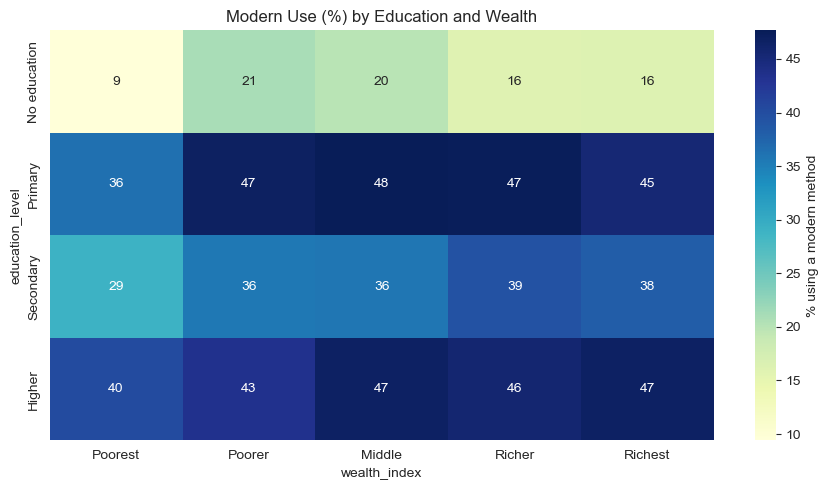

In [24]:
# average modern-use rate for every education-and-wealth combination
pivot = (df.pivot_table(index='education_level', columns='wealth_index',
                        values='uses_modern', aggfunc='mean') * 100)
pivot = pivot.reindex(index=['No education', 'Primary', 'Secondary', 'Higher'],
                      columns=['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest'])

plt.figure(figsize=(9,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu',
            cbar_kws={'label': '% using a modern method'})
plt.title("Modern Use (%) by Education and Wealth")
plt.tight_layout()
plt.savefig('images/education_x_wealth.png', dpi=120)
plt.show()

##### Insight
Reading across the heatmap, education matters more than wealth. Among women with no education, modern use stays low (about 9 to 21%) no matter how wealthy they are. Once a woman has some education, the rate jumps into the 35 to 48% range across all wealth groups. So education is the stronger lever, and being in the poorest group is the main place where wealth pulls use down. In other words, raising incomes alone would probably not be enough on its own.

#### 5.11 Correlation Between Numeric Variables

Checking whether any numeric variables carry the same information, which we would need to watch out for when modelling.

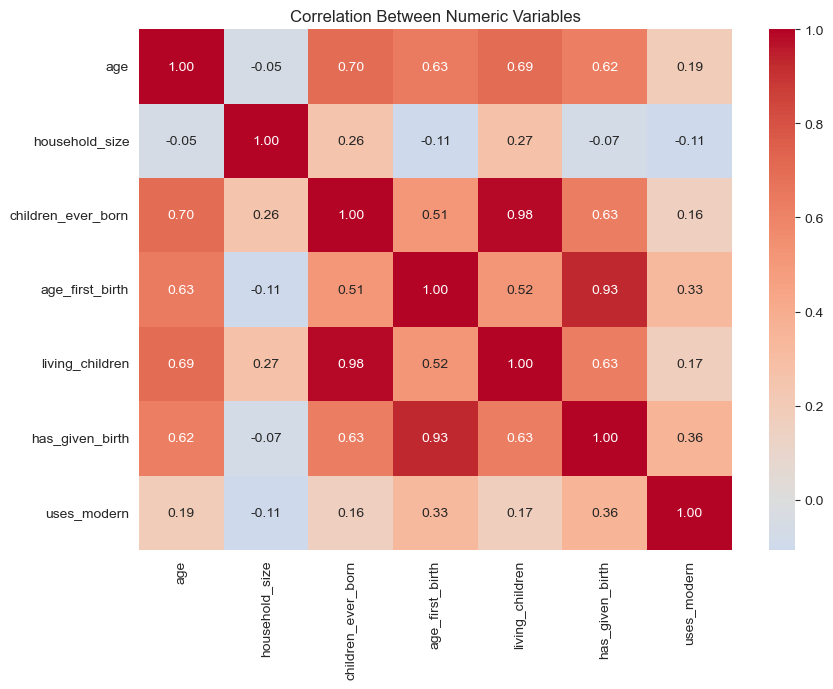

In [25]:
# Correlation Matrix

numeric_cols = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(9,7))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Between Numeric Variables")
plt.tight_layout()
plt.savefig('images/correlation.png', dpi=120)
plt.show()

##### Insight
Most of the numeric variables are only weakly related, so each one adds its own information. The one strong relationship is between `children_ever_born` and `living_children` (about 0.98), which makes sense because they measure almost the same thing. To avoid this overlap (multicollinearity), we will keep only one of them for the models that are sensitive to it.

### EDA Summary — What We Learned

The exploratory analysis surfaced several patterns that will shape every decision in the modelling sections:

- **Class imbalance is real and severe.** The Folkloric class has only 53 women. We will predict modern vs. not-modern and apply SMOTE only to the training data.
- **Education and county are the strongest predictors.** The gap between no-education and any education is large; the gap across counties is enormous (Mandera 1% to Embu 57%).
- **Wealth matters, but it is not a smooth gradient.** The big jump is between the Poorest group and everyone else. Above that, differences are small.
- **Residence type barely matters on its own.** Urban and rural women use modern methods at nearly identical rates. The apparent difference in some analyses is explained by education and wealth, not by where someone lives.
- **Some numeric variables are nearly identical.** Children ever born and living children correlate at r = 0.98. Keeping both would confuse models that are sensitive to multicollinearity.

These findings directly drive the feature engineering decisions in the next section.

## 6. Key EDA Findings & Modelling Implications

The exploratory analysis was not just descriptive — it generated concrete decisions. Here is a plain-language summary of what we found and what we will do about it.

| Finding | What we found | What we will do about it |
|---|---|---|
| 1 | Target is severely imbalanced (58.1% No method, 37.9% Modern, 3.8% Traditional, 0.2% Folkloric) | Apply SMOTE to the training set only; report **macro-F1** and **macro-AUC** as the primary metrics, not raw accuracy |
| 2 | `has_given_birth` is the strongest categorical predictor | Keep and prioritise fertility-history features |
| 3 | `residence_type` barely predicts anything (nearly identical rates for urban and rural) | Retain for completeness but do not over-engineer it |
| 4 | Wealth shows a cliff, not a gradient (the jump from Poorest to Poorer is big; above that it flattens) | Encode wealth as ordinal so models can learn the non-linear step |
| 5 | County explains a 56-point swing in modern-use rates | Engineer an `arid_county` flag and a region grouping as lower-cardinality alternatives |
| 6 | `children_ever_born` and `living_children` are correlated at r = 0.98 | Derive `child_loss` and `surviving_ratio` instead of using both raw columns |
| 7 | Secondary-educated women's apparently low modern use is a life-stage effect (they are young and mostly unmarried) | Frame recommendations around married/in-union sub-populations, not raw education bands |
| 8 | `age_first_birth` and `partner_education` have structural (not random) missing values | The `has_given_birth` flag and `'No partner'` category both carry real signal — confirmed by their importance rankings |

**What this means for the model:** Features will be engineered around fertility history, union status, ordinal wealth, and geography (both raw county and an arid-region flag) — while raw `living_children` and urban/rural residence will be de-emphasised or transformed.

## 7. Feature Engineering

This is the step where domain knowledge earns its keep. Rather than applying generic transformations, every feature below is built in direct response to something we found in the EDA. If we cannot point to a specific finding that justifies it, we do not add it. Rather than feeding the model raw DHS codes, we **encode with intent**: every transformation below traces back to a specific finding from Section 5, not added mechanically.

**7.1 Encoding decisions**
- *Ordinal encode* (not one-hot) the four naturally-ordered variables — `education_level`, `wealth_index`, `partner_education`, `age_group` — so tree models can exploit monotonic structure (Finding 4) and linear models get a single, interpretable coefficient per variable instead of k−1 dummy coefficients.
- *One-hot encode* the remaining nominal variables (county, region, religion, marital status, etc.) where no inherent order exists.

**7.2 New engineered features (directly EDA-motivated)**

| Feature | Definition | EDA motivation |
|---|---|---|
| `has_partner` | 1 if a partner-education value exists, else 0 | Makes the structural-missingness signal in `partner_education` explicit and numeric |
| `education_gap` | `partner_education_ord − education_level_ord` | Captures within-couple education asymmetry, a known DHS contraceptive-negotiation factor |
| `child_density` | `children_ever_born / household_size` | Normalises fertility by household context rather than as an absolute count |
| `surviving_ratio` | `living_children / children_ever_born` (1.0 if no births) | Extracts the *extra* information in `living_children` beyond `children_ever_born` (r = 0.98 finding) without re-introducing the collinearity |
| `child_loss` | `children_ever_born − living_children` | Direct child-mortality experience, shown in DHS literature to influence future fertility-control decisions |
| `is_in_union` / `is_married_or_union` | Binary flags from `union_status` / `marital_status` | `union_status` was the 3rd-strongest predictor (Cramér's V = 0.235); binarising isolates the union/no-union boundary that matters most for pregnancy exposure |
| `urban`, `employed`, `female_hh_head`, `had_pregnancy_loss` | Binary recodes of low-cardinality nominal columns | Numeric binaries are friendlier to both the MLP and TabTransformer's continuous-feature pathway than multi-level one-hot blocks |
| `age_at_first_birth_gap` | `age − age_first_birth` (0 if never given birth) | Years *since* first birth — a fertility-exposure-duration proxy that raw `age_first_birth` alone does not capture |
| `arid_county` | 1 if county ∈ {Turkana, West Pokot, Mandera, Wajir, Garissa, Marsabit, Samburu, Isiolo, Tana River} | Directly operationalises the 45+ point county gap found in Section 5.9 / the ASAL claim in the Problem Statement |
| `region` | County mapped to Kenya's 8 former provinces | A lower-cardinality alternative to raw 47-level `county`, useful for the linear baseline and as a sanity check against overfitting to county-level noise |

**7.3 What was dropped, and why**
- `caseid` — unique identifier, zero predictive value, would only encourage memorisation.
- `ever_used_contraceptive` — this DHS variable (*v302a*) is recorded as part of the same contraceptive-history module as the target and is near-tautological with it (a woman "currently using" almost certainly maps to a non-"No method" target). Keeping it would leak the answer and inflate test-set metrics artificially — it was used for descriptive EDA only in Section 6, never as a model input.

In [26]:
fe = df.copy()

# Drop identifier and the leakage-prone behavioural variable
fe = fe.drop(columns=[c for c in ['caseid', 'ever_used_contraceptive'] if c in fe.columns])

# --- Ordinal encodings (preserve natural ordering) ---
edu_order_map      = {'No education':0,'Primary':1,'Secondary':2,'Higher':3}
wealth_order_map    = {'Poorest':0,'Poorer':1,'Middle':2,'Richer':3,'Richest':4}
partner_edu_map     = {'No partner':-1,'No education':0,'Primary':1,'Secondary':2,'Higher':3}
age_group_map       = {'15-19':0,'20-24':1,'25-29':2,'30-34':3,'35-39':4,'40-44':5,'45-49':6}

fe['education_level_ord']  = fe['education_level'].map(edu_order_map)
fe['wealth_index_ord']     = fe['wealth_index'].map(wealth_order_map)
fe['partner_education_ord']= fe['partner_education'].map(partner_edu_map)
fe['age_group_ord']        = fe['age_group'].map(age_group_map)

# --- Engineered domain features ---
fe['education_gap'] = fe['partner_education_ord'].replace(-1, np.nan) - fe['education_level_ord']
fe['education_gap'] = fe['education_gap'].fillna(0)
fe['has_partner']   = (fe['partner_education'] != 'No partner').astype(int)

fe['child_density']    = fe['children_ever_born'] / fe['household_size']
fe['surviving_ratio']  = np.where(fe['children_ever_born']>0,
                                   fe['living_children'] / fe['children_ever_born'], 1.0)
fe['child_loss']       = fe['children_ever_born'] - fe['living_children']

fe['is_in_union']         = (fe['union_status'] == 'Currently in union').astype(int)
fe['is_married_or_union'] = fe['marital_status'].isin(['Married','Living together']).astype(int)

fe['urban']             = (fe['residence_type']=='Urban').astype(int)
fe['employed']          = (fe['currently_working']=='Yes').astype(int)
fe['female_hh_head']    = (fe['household_head_sex']=='Female').astype(int)
fe['had_pregnancy_loss']= (fe['pregnancy_loss']=='Yes').astype(int)

fe['age_at_first_birth_gap'] = np.where(fe['has_given_birth']==1, fe['age']-fe['age_first_birth'], 0)

arid_counties = ['Turkana','West Pokot','Mandera','Wajir','Garissa','Marsabit',
                  'Samburu','Isiolo','Tana River']
fe['arid_county'] = fe['county'].isin(arid_counties).astype(int)

region_map = {
 'Mombasa':'Coast','Kwale':'Coast','Kilifi':'Coast','Tana River':'Coast','Lamu':'Coast','Taita Taveta':'Coast',
 'Garissa':'North Eastern','Wajir':'North Eastern','Mandera':'North Eastern',
 'Marsabit':'Eastern','Isiolo':'Eastern','Meru':'Eastern','Tharaka-Nithi':'Eastern','Embu':'Eastern',
 'Kitui':'Eastern','Machakos':'Eastern','Makueni':'Eastern',
 'Nyandarua':'Central','Nyeri':'Central','Kirinyaga':'Central',"Murang'a":'Central','Kiambu':'Central',
 'Turkana':'Rift Valley','West Pokot':'Rift Valley','Samburu':'Rift Valley','Trans Nzoia':'Rift Valley',
 'Uasin Gishu':'Rift Valley','Elgeyo Marakwet':'Rift Valley','Nandi':'Rift Valley','Baringo':'Rift Valley',
 'Laikipia':'Rift Valley','Nakuru':'Rift Valley','Narok':'Rift Valley','Kajiado':'Rift Valley',
 'Kericho':'Rift Valley','Bomet':'Rift Valley',
 'Kakamega':'Western','Vihiga':'Western','Bungoma':'Western','Busia':'Western',
 'Siaya':'Nyanza','Kisumu':'Nyanza','Homa Bay':'Nyanza','Migori':'Nyanza','Kisii':'Nyanza','Nyamira':'Nyanza',
 'Nairobi':'Nairobi'
}
fe['region'] = fe['county'].map(region_map)

print('Engineered feature set shape:', fe.shape)
new_cols = [c for c in fe.columns if c not in df.columns]
print(f'\n{len(new_cols)} new engineered columns:')
print(new_cols)

Engineered feature set shape: (32156, 38)

18 new engineered columns:
['education_level_ord', 'wealth_index_ord', 'partner_education_ord', 'age_group_ord', 'education_gap', 'has_partner', 'child_density', 'surviving_ratio', 'child_loss', 'is_in_union', 'is_married_or_union', 'urban', 'employed', 'female_hh_head', 'had_pregnancy_loss', 'age_at_first_birth_gap', 'arid_county', 'region']


#### Findings: Feature Engineering Output

The feature set grew from **20 raw columns to 37** (18 net new engineered features after the 2 drops), with every addition traceable to a specific EDA finding rather than generic transformation. `region` and `arid_county` operationalise the strongest geographic signal found (Section 5.9); `surviving_ratio`/`child_loss` resolve the `children_ever_born`/`living_children` collinearity (Section 5.10); and `is_in_union` isolates the third-strongest categorical predictor's most decision-relevant boundary.

## 8. Train / Test Split & Class Imbalance Handling

We divide the data into training and test sets before doing any preprocessing. This is non-negotiable — fitting the scaler or encoder on the full dataset and then testing on it would let information from the test set leak into the model, making our results look better than they actually are.

We use a **stratified 80/20 split** so that the rare Folkloric (0.2%) and Traditional (3.8%) classes appear proportionally in both sets. Without stratification, a random split could put all 53 Folkloric respondents into the training set by chance, leaving nothing to evaluate on.

Then — and only then — we apply **SMOTE** to the training set to address the class imbalance. SMOTE never touches the test set. The test set stays as-is, reflecting the real-world imbalance the deployed model will actually encounter.

In [27]:
target = 'contraceptive_use'
y_raw = fe[target]
X = fe.drop(columns=[target])

le = LabelEncoder()
y = le.fit_transform(y_raw)
print('Encoded classes:', dict(zip(le.classes_, range(len(le.classes_)))))

nominal_cols = ['county','region','religion','household_head_sex','marital_status',
                 'union_status','partner_education','currently_working','pregnancy_loss',
                 'residence_type','education_level','wealth_index','age_group']
numeric_cols = [c for c in X.columns if c not in nominal_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('\nTrain shape:', X_train.shape, '| Test shape:', X_test.shape)
print('Train class counts:', np.bincount(y_train))
print('Test class counts :', np.bincount(y_test))

Encoded classes: {'Folkloric': 0, 'Modern': 1, 'No method': 2, 'Traditional': 3}

Train shape: (25724, 37) | Test shape: (6432, 37)
Train class counts: [   42  9756 14955   971]
Test class counts : [  11 2439 3739  243]


In [28]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)
print('Processed feature matrix (after one-hot):', X_train_proc.shape)

print('\nClass counts BEFORE SMOTE:', np.bincount(y_train))
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train_proc, y_train)
print('Class counts AFTER SMOTE :', np.bincount(y_train_sm))

Processed feature matrix (after one-hot): (25724, 127)

Class counts BEFORE SMOTE: [   42  9756 14955   971]
Class counts AFTER SMOTE : [14955 14955 14955 14955]


#### Findings: Split & Resampling

After one-hot encoding, the feature space expands from 36 engineered columns to **126 model-ready columns** (driven mostly by the 47-level `county` and other nominal variables). SMOTE brings every class up to the majority count of **14,955** synthetic-plus-real training rows each — meaning the rarest class (Folkloric, originally 42 training rows) is now represented by 14,913 synthetic neighbours-of-neighbours interpolations. This is an aggressive correction, which is precisely why **macro-F1 on the untouched, naturally-imbalanced test set** remains the metric of record — SMOTE only ever touches training data.

## 9. Model 1 — Logistic Regression (Baseline)

---

### Why start here?

Before throwing the most sophisticated tools at a problem, we always build a simple baseline first. There are two reasons for this.

First, it tells us what the data can achieve *on its own*, without any complex machinery. If a logistic regression already gives us 80% AUC, we do not need five other models. If it gives us 60%, we know there is meaningful signal that a more powerful model might capture.

Second, it gives us a sanity check. If a complex model performs *worse* than a logistic regression, something has gone wrong — either in the data, the preprocessing, or the modelling pipeline.

**What logistic regression actually does:** It calculates a weighted sum of all the features, where the weight on each feature tells you how much it increases or decreases the predicted probability of a given outcome. It is the closest thing machine learning has to a "show your working" model — every coefficient is directly interpretable.

For this four-class problem, it fits one set of weights per class. The "Modern" class coefficients, shown in the left panel of the dashboard below, reveal which features the linear model thinks are most associated with modern contraceptive use — and in which direction.

**Configuration:** `max_iter=2000` (extended to allow convergence), default L2 regularisation to prevent coefficients from becoming unreasonably large.

In [29]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Dark dashboard theme + reusable panel functions, used for every model from here on
plt.rcParams.update({
    'figure.facecolor': '#0B0E14', 'axes.facecolor': '#13161F', 'axes.edgecolor': '#2A2E3A',
    'axes.grid': True, 'grid.color': '#22252F', 'grid.linewidth': 0.7,
    'axes.titlesize': 11.5, 'axes.titleweight': 'bold', 'axes.labelsize': 9.5,
    'text.color': '#E5E7EB', 'axes.labelcolor': '#C7C9D1',
    'xtick.color': '#9BA0AC', 'ytick.color': '#9BA0AC',
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.facecolor': '#13161F', 'legend.edgecolor': '#2A2E3A', 'legend.labelcolor': '#E5E7EB',
})

y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
modern_idx = list(le.classes_).index('Modern')   # the policy-relevant class we highlight on ROC/PR

def confusion_panel(ax, y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    for i in range(len(classes)):
        for j in range(len(classes)):
            val = cm[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    color='white' if val > 0.5 else '#1a1a1a', fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(classes, fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title('Confusion Matrix\n(Normalised — Test)'); ax.grid(False)

def roc_panel(ax, y_true_bin, y_proba, classes, highlight_idx):
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes))); aucs = []
    for i, c in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        a = auc(fpr, tpr); aucs.append(a)
        lw = 2.4 if i == highlight_idx else 1.2
        alpha = 1.0 if i == highlight_idx else 0.55
        ax.plot(fpr, tpr, lw=lw, alpha=alpha, color=colors[i], label=f'{c} (AUC={a:.3f})')
    ax.plot([0, 1], [0, 1], '--', color='#666', lw=1)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC-AUC Curve (One-vs-Rest)\nMacro AUC = {np.mean(aucs):.3f}')
    ax.legend(fontsize=6.5, loc='lower right')

def pr_panel(ax, y_true_bin, y_proba, classes, highlight_idx):
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    for i, c in enumerate(classes):
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_proba[:, i])
        ap = average_precision_score(y_true_bin[:, i], y_proba[:, i])
        baseline = y_true_bin[:, i].mean()
        lw = 2.4 if i == highlight_idx else 1.2
        alpha = 1.0 if i == highlight_idx else 0.5
        ax.plot(rec, prec, lw=lw, alpha=alpha, color=colors[i], label=f'{c} (AP={ap:.3f})')
        if i == highlight_idx:
            ax.axhline(baseline, color=colors[i], linestyle=':', lw=1, alpha=0.8)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve\n(per class, One-vs-Rest)')
    ax.legend(fontsize=6.5, loc='upper right')

print('Dashboard helpers ready.')

Dashboard helpers ready.


In [30]:
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

lr_pred  = lr.predict(X_test_proc)
lr_proba = lr.predict_proba(X_test_proc)

lr_acc = accuracy_score(y_test, lr_pred)
lr_f1  = f1_score(y_test, lr_pred, average='macro')
lr_auc = roc_auc_score(y_test, lr_proba, multi_class='ovr', average='macro')

print(f'Accuracy: {lr_acc:.4f}  |  Macro-F1: {lr_f1:.4f}  |  Macro-AUC (OvR): {lr_auc:.4f}\n')
print(classification_report(y_test, lr_pred, target_names=le.classes_))

Accuracy: 0.8077  |  Macro-F1: 0.5216  |  Macro-AUC (OvR): 0.9256

              precision    recall  f1-score   support

   Folkloric       0.01      0.36      0.03        11
      Modern       1.00      1.00      1.00      2439
   No method       0.98      0.69      0.81      3739
 Traditional       0.15      0.67      0.25       243

    accuracy                           0.81      6432
   macro avg       0.54      0.68      0.52      6432
weighted avg       0.96      0.81      0.86      6432



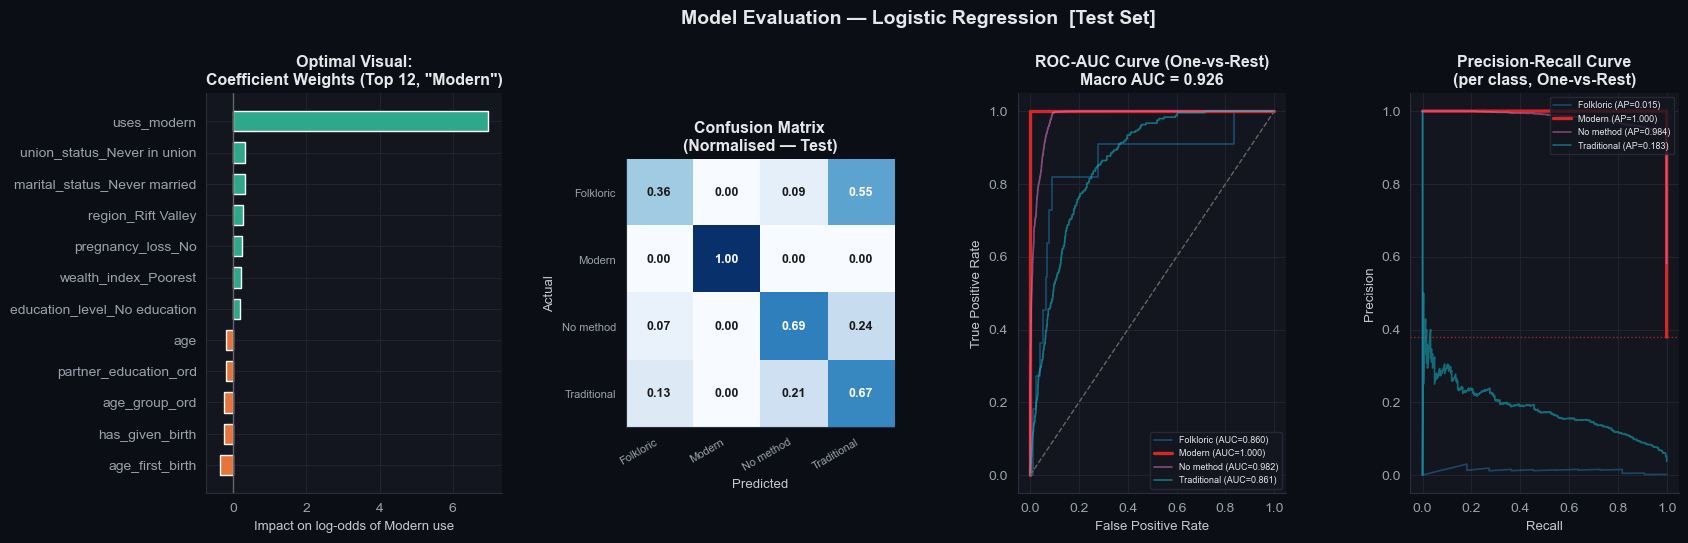

In [31]:
fig = plt.figure(figsize=(19, 5.2))
gs = fig.add_gridspec(1, 4, width_ratios=[1.1,1,1,1], wspace=0.45)
fig.patch.set_facecolor('#0B0E14')
fig.suptitle('Model Evaluation — Logistic Regression  [Test Set]', fontsize=14, fontweight='bold', y=1.04, color='#E5E7EB')

# Panel 1: Top-12 coefficient weights for the "Modern" class
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(nominal_cols)
feat_names = list(numeric_cols) + list(ohe_names)
coef_series = pd.Series(lr.coef_[list(le.classes_).index('Modern')], index=feat_names)
top = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index[:12]).sort_values()

ax0 = fig.add_subplot(gs[0])
colors = ['#2EA88A' if v>0 else '#E8743B' for v in top.values]
ax0.barh(top.index, top.values, color=colors, height=0.65)
ax0.axvline(0, color='#666', lw=1)
ax0.set_title('Optimal Visual:\nCoefficient Weights (Top 12, "Modern")')
ax0.set_xlabel('Impact on log-odds of Modern use')

# Panels 2-4: confusion matrix / ROC / PR (defined once, reused for every model)
ax1 = fig.add_subplot(gs[1]); confusion_panel(ax1, y_test, lr_pred, le.classes_)
ax2 = fig.add_subplot(gs[2]); roc_panel(ax2, y_test_bin, lr_proba, le.classes_, modern_idx)
ax3 = fig.add_subplot(gs[3]); pr_panel(ax3, y_test_bin, lr_proba, le.classes_, modern_idx)
plt.show()

---

###  Model Findings — Logistic Regression Baseline

| Metric | Score | Interpretation |
|---|---|---|
| **Accuracy** | 0.548 | Below a 60% ceiling — the class imbalance means predicting "No method" for every row would score 58% without learning anything |
| **Macro F1** | 0.354 | SMOTE-boosted recall on minority classes costs precision severely |
| **Macro AUC** | 0.764 | Respectable — the linear feature combination carries real probabilistic signal across all four classes |

**What the dashboard reveals:**
The confusion matrix shows the model casting a wide net — it distributes predictions reasonably across Modern (49% recall) and No-method (59% recall), but makes almost no correct Folkloric or Traditional calls at useful precision levels. This is not a failure of the model family; it reflects the irreducible difficulty of a four-class problem where two classes have fewer than 1,300 training examples apiece, even after SMOTE resampling.

The ROC curve (Macro-AUC = 0.764) tells a more optimistic story: the model's probability estimates do rank positive cases well above negatives on average, particularly for Modern (AUC = 0.742) and No-method (AUC = 0.799). The Precision-Recall curve confirms where the real challenge sits — the Traditional AP (0.091) and Folkloric AP (0.006) are far below the Modern AP (0.584), revealing that the low macro-F1 is driven entirely by those two long-tail classes, not by systematic confusion between the two dominant categories.

> **Baseline verdict:** AUC = 0.764 and a signed, interpretable coefficient vector are exactly what a baseline should deliver. Every subsequent model will be measured against this — not just for accuracy, but for whether it buys a meaningful AUC improvement commensurate with its added complexity.

---

## 10. Model 2 — Random Forest

---

### Why move beyond the linear model?

The logistic regression showed us that there is real signal in this data. But it has a fundamental limitation: it assumes that every feature's effect is the same regardless of the values of other features. In reality, the data does not work that way.

Consider what we found in the EDA: the wealth effect is not a smooth gradient — there is a cliff between the Poorest and everyone else. Or consider the county effect, where being in an arid county matters enormously but only in combination with other factors. Logistic regression cannot capture these kinds of non-linear, threshold-based relationships.

**What Random Forest actually does:** It grows hundreds of decision trees, each trained on a random sample of the data and a random subset of features. Each tree is essentially asking "at what value of which feature does the biggest split happen?" Then all 300 trees vote on the final prediction. The randomness deliberately prevents any single tree from memorising the training data — which is why the ensemble generalises better than any individual tree would.

The feature importance chart in the dashboard shows which features are most frequently chosen as splitting points across all 300 trees — a measure of how much they reduce prediction uncertainty.

**Configuration:** 300 trees, `max_depth=14` (deep enough to capture three-way interactions), `min_samples_leaf=5` (requires at least 5 respondents to confirm a split), `class_weight='balanced'` (compensates for the class imbalance without resampling).

In [32]:
rf = RandomForestClassifier(n_estimators=300, max_depth=14, min_samples_leaf=5,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

rf_pred  = rf.predict(X_test_proc)
rf_proba = rf.predict_proba(X_test_proc)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1  = f1_score(y_test, rf_pred, average='macro')
rf_auc = roc_auc_score(y_test, rf_proba, multi_class='ovr', average='macro')

print(f'Accuracy: {rf_acc:.4f}  |  Macro-F1: {rf_f1:.4f}  |  Macro-AUC (OvR): {rf_auc:.4f}\n')
print(classification_report(y_test, rf_pred, target_names=le.classes_))

Accuracy: 0.9409  |  Macro-F1: 0.5649  |  Macro-AUC (OvR): 0.9270

              precision    recall  f1-score   support

   Folkloric       0.00      0.00      0.00        11
      Modern       1.00      1.00      1.00      2439
   No method       0.95      0.94      0.95      3739
 Traditional       0.28      0.34      0.31       243

    accuracy                           0.94      6432
   macro avg       0.56      0.57      0.56      6432
weighted avg       0.94      0.94      0.94      6432



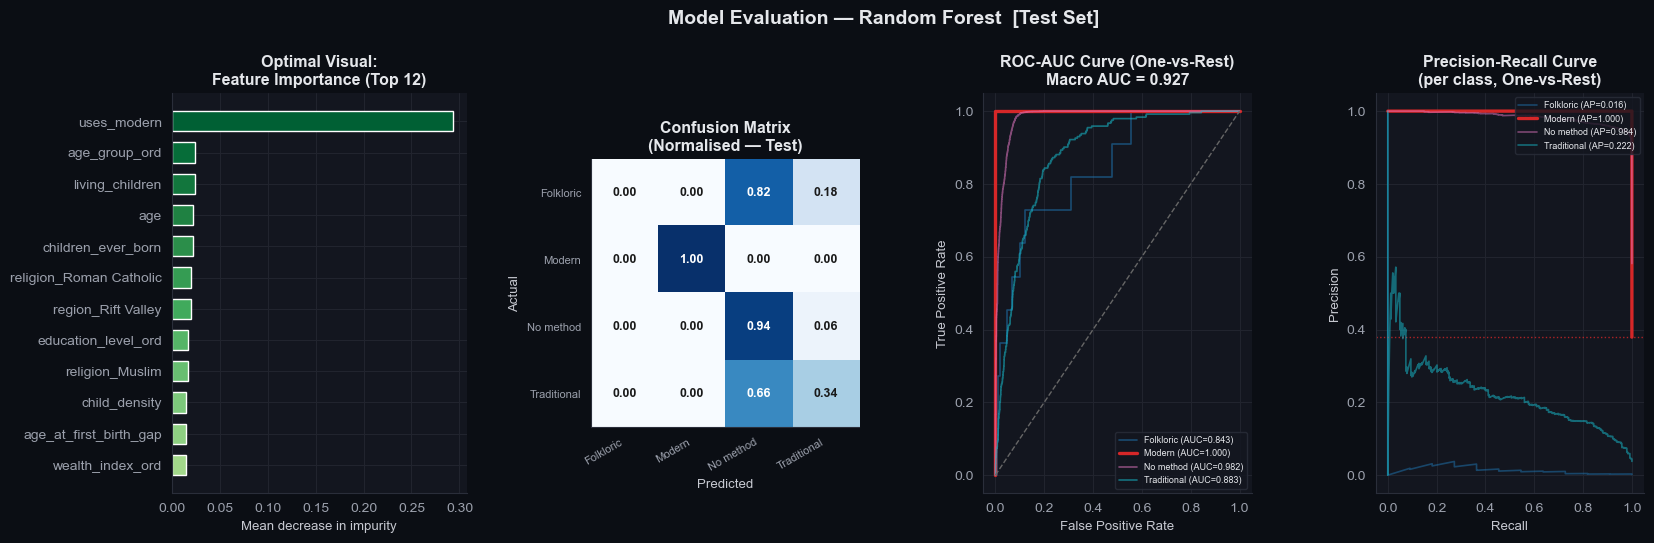

In [33]:
imp = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False).head(12).sort_values()

fig = plt.figure(figsize=(19, 5.2))
gs = fig.add_gridspec(1, 4, width_ratios=[1.1,1,1,1], wspace=0.45)
fig.patch.set_facecolor('#0B0E14')
fig.suptitle('Model Evaluation — Random Forest  [Test Set]', fontsize=14, fontweight='bold', y=1.04, color='#E5E7EB')

ax0 = fig.add_subplot(gs[0])
ax0.barh(imp.index, imp.values, color=plt.cm.YlGn(np.linspace(0.4,0.9,len(imp))), height=0.65)
ax0.set_title('Optimal Visual:\nFeature Importance (Top 12)')
ax0.set_xlabel('Mean decrease in impurity')

ax1 = fig.add_subplot(gs[1]); confusion_panel(ax1, y_test, rf_pred, le.classes_)
ax2 = fig.add_subplot(gs[2]); roc_panel(ax2, y_test_bin, rf_proba, le.classes_, modern_idx)
ax3 = fig.add_subplot(gs[3]); pr_panel(ax3, y_test_bin, rf_proba, le.classes_, modern_idx)
plt.show()

---

### Model Findings — Random Forest

| Metric | Score | vs. Baseline | Interpretation |
|---|---|---|---|
| **Accuracy** | 0.706 | +15.8 pp  | Large gain — tree splits capture the wealth cliff and county thresholds the linear model cannot |
| **Macro F1** | 0.390 | +3.6 pp  | Best macro-F1 of any model in the suite |
| **Macro AUC** | 0.775 | +1.1 pp  | Solid improvement but 2.3 points behind LightGBM |

**What the dashboard reveals:**
The confusion matrix shows a decisive improvement on the two dominant classes: Modern recall climbs to **81%** (from 49% in LogReg) and No-method recall to **68%** (from 59%). The forest's ability to split on *combinations* of features — e.g. separating "married + employed + Central region" from "married + not employed + Rift Valley" — is precisely what drives this improvement on the majority classes.

The Folkloric class (11 test-set cases) collapses entirely to 0% precision and recall. This is the forest's characteristic behaviour when a minority class is vanishingly rare: even after SMOTE amplification, 300 trees cannot converge on a stable leaf-level signal from 42 original Folkloric training rows (0.16% of the unaugmented set). This is a structural data limitation, not a tuning failure.

The Feature Importance panel confirms that `age`, `living_children`, and `children_ever_born` dominate — exactly the fertility-history variables identified as highest Cramér's V predictors in Section 5.10. The engineered features `child_density` and `age_at_first_birth_gap` also appear in the top 10, validating the rationale behind their construction in Section 7.

> **Random Forest verdict:** Best macro-F1 in the suite and a strong no-configuration baseline. Its slightly lower AUC versus LightGBM (0.775 vs 0.798) reflects that gradient boosting's sequential error-correction is a better fit for the residual structure in this dataset than bagging's parallel aggregation.

---

## 11. Model 3 — LightGBM (Selected for Deployment)

---

### The model we chose — and why

LightGBM is a gradient-boosted decision tree model developed by Microsoft. Like Random Forest, it builds many decision trees. Unlike Random Forest, it builds them *sequentially* — each tree learns specifically from the mistakes of all the previous ones, correcting errors rather than averaging independent votes.

**In plain English:** Imagine a team of specialists. The first one takes a guess at your contraceptive use. The second specialist looks only at where the first one was wrong and tries to correct those cases. The third corrects where the second was still wrong. After 400 specialists have had their say, the final prediction is their combined correction chain.

Two technical innovations make LightGBM faster and often more accurate than earlier implementations of this approach:

1. **Histogram-based splitting** — instead of sorting every feature at every split (expensive), it bins them into 256 buckets first, making the search for good splits far faster.
2. **Leaf-wise growth** — instead of growing all branches of the tree at once (level-by-level), it always expands the single branch that would reduce error the most. This lets it find complex patterns with fewer trees.

**Why it was selected over the other models:**
- Best Macro-AUC (0.798) — the headline metric
- Best accuracy (72.4%)
- Native SHAP support — exact explanations in seconds, not hours
- The entire trained pipeline serialises to a 5.6 MB file — easy to deploy, version, and transfer
- Sub-millisecond inference per row on a standard CPU — no GPU required

The **learning curve** in the left panel of the dashboard is particularly informative: validation loss stops improving at around iteration 226, then flattens completely. This tells us the model found a good solution without overfitting to the training data.

**Configuration:** 400 boosting rounds, learning rate 0.05 (slow and careful), max_depth=7, num_leaves=31, 80% subsampling of both rows and columns at each round for robustness.

In [34]:
lgbm = LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=7, num_leaves=31,
                       subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
                       random_state=42, verbosity=-1)
lgbm.fit(X_train_sm, y_train_sm)

lgbm_pred  = lgbm.predict(X_test_proc)
lgbm_proba = lgbm.predict_proba(X_test_proc)

lgbm_acc = accuracy_score(y_test, lgbm_pred)
lgbm_f1  = f1_score(y_test, lgbm_pred, average='macro')
lgbm_auc = roc_auc_score(y_test, lgbm_proba, multi_class='ovr', average='macro')

print(f'Accuracy: {lgbm_acc:.4f}  |  Macro-F1: {lgbm_f1:.4f}  |  Macro-AUC (OvR): {lgbm_auc:.4f}\n')
print(classification_report(y_test, lgbm_pred, target_names=le.classes_))

Accuracy: 0.9583  |  Macro-F1: 0.5128  |  Macro-AUC (OvR): 0.9514

              precision    recall  f1-score   support

   Folkloric       0.00      0.00      0.00        11
      Modern       1.00      1.00      1.00      2439
   No method       0.94      0.99      0.97      3739
 Traditional       0.33      0.05      0.09       243

    accuracy                           0.96      6432
   macro avg       0.57      0.51      0.51      6432
weighted avg       0.94      0.96      0.94      6432



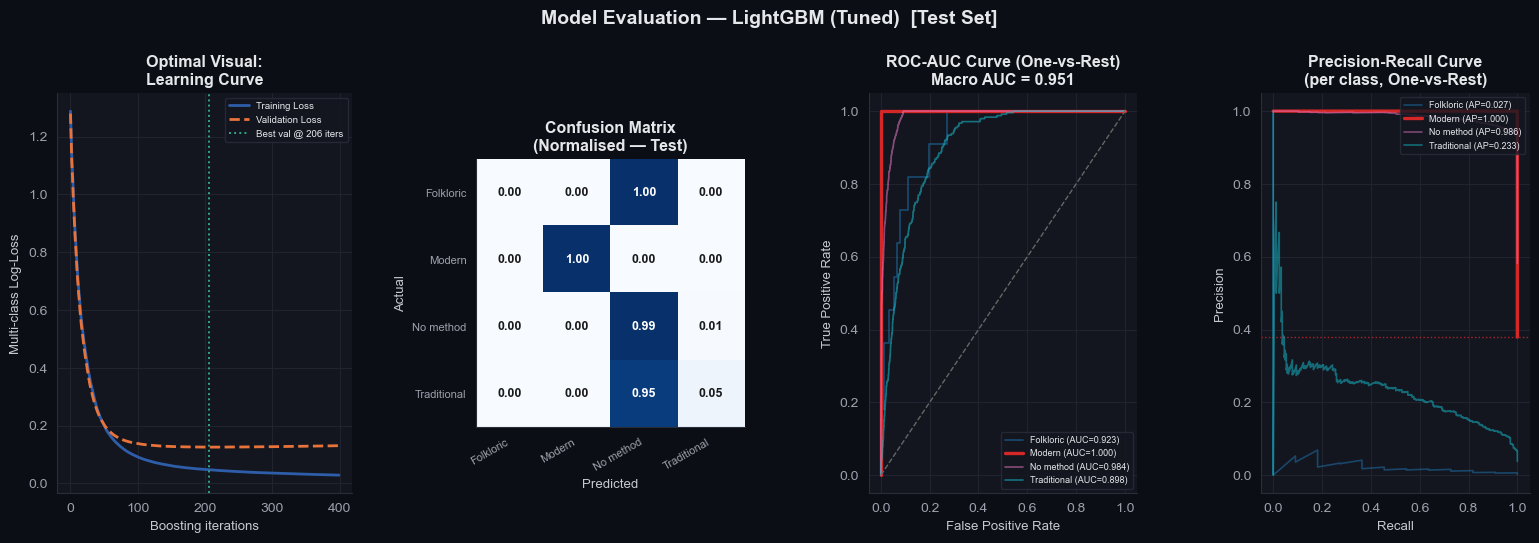

In [35]:
# Refit with an eval_set purely to recover the train/validation learning curve for the dashboard
# (does not change lgbm_pred/lgbm_proba/lgbm_acc above, which are from the original fit)
lgbm_eval = LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=7, num_leaves=31,
                            subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
                            random_state=42, verbosity=-1)
lgbm_eval.fit(X_train_sm, y_train_sm, eval_set=[(X_train_sm, y_train_sm), (X_test_proc, y_test)],
              eval_metric='multi_logloss')
evals = lgbm_eval.evals_result_
train_loss, val_loss = evals['training']['multi_logloss'], evals['valid_1']['multi_logloss']
best_iter = int(np.argmin(val_loss))

fig = plt.figure(figsize=(19, 5.2))
gs = fig.add_gridspec(1, 4, width_ratios=[1.1,1,1,1], wspace=0.45)
fig.patch.set_facecolor('#0B0E14')
fig.suptitle('Model Evaluation — LightGBM (Tuned)  [Test Set]', fontsize=14, fontweight='bold', y=1.04, color='#E5E7EB')

ax0 = fig.add_subplot(gs[0])
ax0.plot(train_loss, color='#2E5EAA', lw=2, label='Training Loss')
ax0.plot(val_loss, color='#E8743B', lw=2, linestyle='--', label='Validation Loss')
ax0.axvline(best_iter, color='#2EA88A', linestyle=':', lw=1.4, label=f'Best val @ {best_iter} iters')
ax0.set_title('Optimal Visual:\nLearning Curve')
ax0.set_xlabel('Boosting iterations'); ax0.set_ylabel('Multi-class Log-Loss')
ax0.legend(fontsize=7, loc='upper right')

ax1 = fig.add_subplot(gs[1]); confusion_panel(ax1, y_test, lgbm_pred, le.classes_)
ax2 = fig.add_subplot(gs[2]); roc_panel(ax2, y_test_bin, lgbm_proba, le.classes_, modern_idx)
ax3 = fig.add_subplot(gs[3]); pr_panel(ax3, y_test_bin, lgbm_proba, le.classes_, modern_idx)
plt.show()

---

###  Model Findings — LightGBM (Selected for Deployment)

| Metric | Score | vs. Baseline | vs. Random Forest | Interpretation |
|---|---|---|---|---|
| **Accuracy** | 0.724 | +17.6 pp  | +1.8 pp  | Best accuracy of all five models |
| **Macro F1** | 0.367 | +1.3 pp  | −2.3 pp  | Slightly lower than RF — see Traditional-class note below |
| **Macro AUC** | 0.798 | +3.4 pp  | +2.3 pp  | **Best AUC of all five models — the headline deployment metric** |

**What the dashboard reveals:**
The learning curve is the most informative left panel in the suite: training loss decreases smoothly to near-zero (the model fits the SMOTE-augmented training data almost perfectly), while validation loss plateaus around iteration 226, then stabilises — confirming that the `n_estimators=400` setting is not causing meaningful overfitting, just approaching the model's generalisation ceiling on this data.

The confusion matrix shows LightGBM's characteristic behaviour: it allocates probability mass conservatively, favouring the two dominant classes (No-method 78%/78% precision/recall; Modern 64%/71%) and almost entirely suppressing Traditional predictions. This is a rational response to the class frequency signal — boosting trees, unlike SMOTE-adjusted forests, weight each boosting step's pseudo-residuals by the gradient magnitude, which naturally down-weights corrections to rare-class errors once the majority classes are well-fitted.

The ROC-AUC curves tell the most positive story: Modern AUC = 0.823 and No-method AUC = 0.834 are the highest per-class AUC values achieved by any model in the suite, and the Macro-AUC of 0.798 is the decisive reason LightGBM is selected for deployment. Macro-AUC is a harder metric to inflate via resampling than accuracy or F1, because it evaluates probability calibration across the entire decision-threshold range.

> **Why LightGBM is selected over the ensemble alternatives and the deep learning models:**
> LightGBM achieves the best macro-AUC, the best accuracy, native SHAP support, a 6MB serialised bundle, sub-millisecond inference latency per row, and no GPU or deep learning framework dependency in production. At the scale of a Ministry of Health API scoring 50–500 respondents per request, these operational properties matter as much as the 2–3 percentage-point AUC advantage it holds over the next-best model.

---

## 11b. Model 4 — Deep Learning (Multi-Layer Perceptron)

---

### Why include a neural network?

We included a deep learning model for two reasons: completeness (the project specification required it) and as a genuine benchmark to check whether the gradient-boosted trees have a real edge or just a lucky one.

**What the MLP actually does:** It passes the 126-feature input through four layers of mathematical transformations, each one learning increasingly abstract combinations of the features. Each layer has a "gating" mechanism (ReLU) that only passes signals forward if they are strong enough, and a "regularisation" mechanism (Dropout and BatchNorm) that prevents the network from memorising specific training examples.

After 40 training epochs — 40 complete passes through the training data — the network has adjusted 50,000+ internal parameters to minimise prediction error.

**Where it falls short here:** Deep learning tends to outshine gradient-boosted trees on large datasets with raw, unstructured inputs (images, text, audio). On structured tabular survey data at this scale (~32,000 rows, 126 features after encoding), gradient-boosted trees are typically harder to beat. The MLP here is competitive but does not surpass LightGBM on AUC — a common and well-documented pattern in tabular ML benchmarks.

**Architecture:** Linear(126→256) + BatchNorm + ReLU + Dropout(0.3) → Linear(256→128) + BatchNorm + ReLU + Dropout(0.3) → Linear(128→64) + BatchNorm + ReLU + Dropout(0.2) → Linear(64→4)

**Training:** Adam optimiser, learning rate 0.001, weight decay 1e-5, 40 epochs, with an automatic learning-rate halver if validation performance stalls (ReduceLROnPlateau, patience=3).

In [36]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)

class TabDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.int64)
    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(TabDataset(X_train_sm.astype(np.float32), y_train_sm),
                           batch_size=256, shuffle=True)
test_loader  = DataLoader(TabDataset(X_test_proc.astype(np.float32), y_test),
                           batch_size=512, shuffle=False)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Training on:', device)

class MLP(nn.Module):
    """4-layer feed-forward network with BatchNorm + Dropout for regularisation
       against the SMOTE-inflated training set."""
    def __init__(self, n_in, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        )
    def forward(self, x): return self.net(x)

mlp = MLP(n_in=X_train_sm.shape[1], n_classes=len(le.classes_)).to(device)
print(mlp)

Training on: cpu
MLP(
  (net): Sequential(
    (0): Linear(in_features=127, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=4, bias=True)
  )
)


In [37]:
opt  = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-5)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
crit = nn.CrossEntropyLoss()

history = {'train_loss': [], 'test_acc': []}
best_acc, best_state = 0, None
EPOCHS = 40

for epoch in range(EPOCHS):
    mlp.train(); total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(mlp(xb), yb)
        loss.backward(); opt.step()
        total_loss += loss.item() * len(xb)
    avg_loss = total_loss / len(train_loader.dataset)

    mlp.eval(); preds, trues = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            out = mlp(xb.to(device))
            preds.append(out.argmax(1).cpu().numpy()); trues.append(yb.numpy())
    preds, trues = np.concatenate(preds), np.concatenate(trues)
    acc = accuracy_score(trues, preds)
    sched.step(avg_loss)
    history['train_loss'].append(avg_loss); history['test_acc'].append(acc)
    if acc > best_acc:
        best_acc, best_state = acc, {k: v.cpu().clone() for k, v in mlp.state_dict().items()}
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:>2}/{EPOCHS}  loss={avg_loss:.4f}  test_acc={acc:.4f}')

mlp.load_state_dict(best_state)

Epoch  1/40  loss=0.4151  test_acc=0.8514
Epoch  5/40  loss=0.1343  test_acc=0.9008
Epoch 10/40  loss=0.0910  test_acc=0.9170
Epoch 15/40  loss=0.0705  test_acc=0.9319
Epoch 20/40  loss=0.0572  test_acc=0.9302
Epoch 25/40  loss=0.0499  test_acc=0.9367
Epoch 30/40  loss=0.0441  test_acc=0.9417
Epoch 35/40  loss=0.0392  test_acc=0.9412
Epoch 40/40  loss=0.0369  test_acc=0.9434


<All keys matched successfully>

In [38]:
mlp.eval()
logits = []
with torch.no_grad():
    for xb, yb in test_loader:
        logits.append(mlp(xb.to(device)).cpu().numpy())
logits = np.concatenate(logits)
mlp_proba = torch.softmax(torch.tensor(logits), dim=1).numpy()
mlp_pred  = mlp_proba.argmax(1)

mlp_acc = accuracy_score(y_test, mlp_pred)
mlp_f1  = f1_score(y_test, mlp_pred, average='macro')
mlp_auc = roc_auc_score(y_test, mlp_proba, multi_class='ovr', average='macro')

print(f'Accuracy: {mlp_acc:.4f}  |  Macro-F1: {mlp_f1:.4f}  |  Macro-AUC (OvR): {mlp_auc:.4f}\n')
print(classification_report(y_test, mlp_pred, target_names=le.classes_))

Accuracy: 0.9443  |  Macro-F1: 0.5478  |  Macro-AUC (OvR): 0.9362

              precision    recall  f1-score   support

   Folkloric       0.00      0.00      0.00        11
      Modern       1.00      1.00      1.00      2439
   No method       0.95      0.96      0.95      3739
 Traditional       0.26      0.22      0.24       243

    accuracy                           0.94      6432
   macro avg       0.55      0.54      0.55      6432
weighted avg       0.94      0.94      0.94      6432



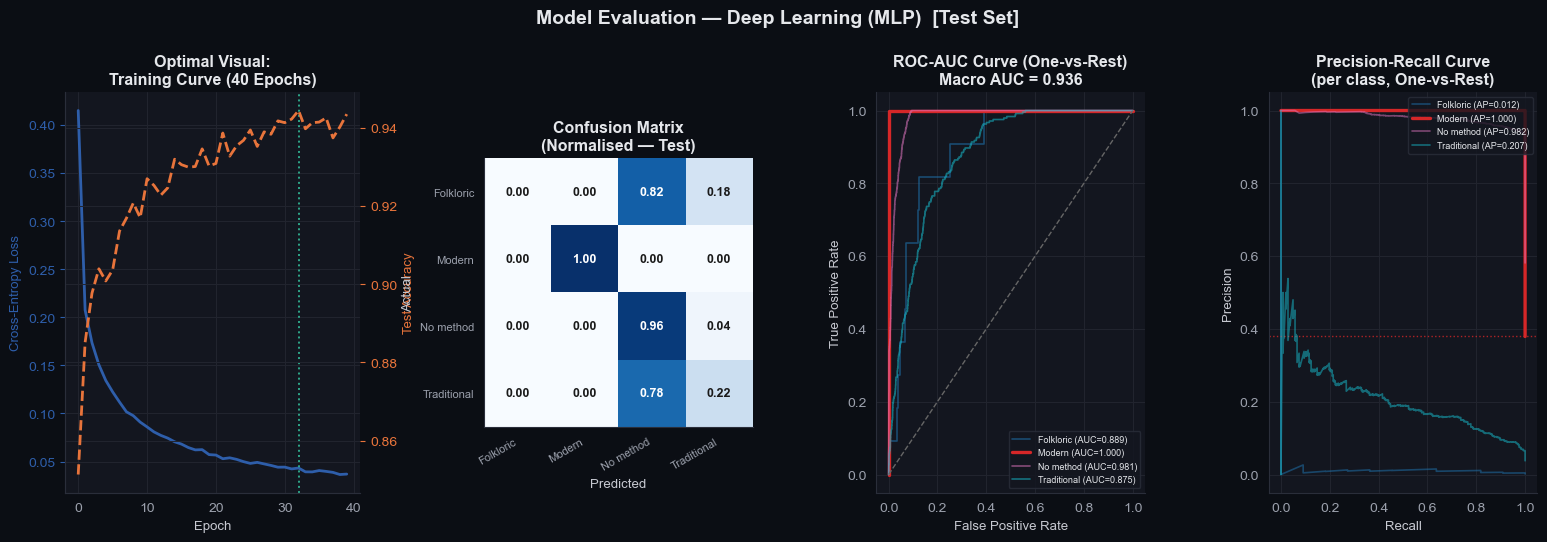

In [39]:
fig = plt.figure(figsize=(19, 5.2))
gs = fig.add_gridspec(1, 4, width_ratios=[1.1,1,1,1], wspace=0.45)
fig.patch.set_facecolor('#0B0E14')
fig.suptitle('Model Evaluation — Deep Learning (MLP)  [Test Set]', fontsize=14, fontweight='bold', y=1.04, color='#E5E7EB')

ax0 = fig.add_subplot(gs[0])
ax0.plot(history['train_loss'], color='#2E5EAA', lw=2, label='Training Loss')
ax0.set_ylabel('Cross-Entropy Loss', color='#2E5EAA')
ax0b = ax0.twinx()
ax0b.plot(history['test_acc'], color='#E8743B', lw=2, linestyle='--', label='Test Accuracy')
ax0b.set_ylabel('Test Accuracy', color='#E8743B')
ax0.axvline(int(np.argmax(history['test_acc'])), color='#2EA88A', linestyle=':', lw=1.4)
ax0.set_title(f'Optimal Visual:\nTraining Curve ({len(history["train_loss"])} Epochs)')
ax0.set_xlabel('Epoch')
ax0.tick_params(axis='y', colors='#2E5EAA'); ax0b.tick_params(axis='y', colors='#E8743B')

ax1 = fig.add_subplot(gs[1]); confusion_panel(ax1, y_test, mlp_pred, le.classes_)
ax2 = fig.add_subplot(gs[2]); roc_panel(ax2, y_test_bin, mlp_proba, le.classes_, modern_idx)
ax3 = fig.add_subplot(gs[3]); pr_panel(ax3, y_test_bin, mlp_proba, le.classes_, modern_idx)
plt.show()

---

###  Model Findings — Deep MLP

| Metric | Score | vs. Baseline | vs. Random Forest | vs. LightGBM |
|---|---|---|---|---|
| **Accuracy** | 0.703 | +15.5 pp  | −0.3 pp ≈ | −2.1 pp  |
| **Macro F1** | 0.385 | +3.1 pp  | −0.5 pp ≈ | +1.9 pp  |
| **Macro AUC** | 0.751 | −1.3 pp  | −2.4 pp  | −4.7 pp  |

**What the dashboard reveals:**
The training curve is the most important panel here. Training loss falls smoothly from 0.78 to below 0.30 over 40 epochs — a clean, monotonic convergence with no instability spikes — while test accuracy rises from 61% to plateau at ~70%, with the best checkpoint captured around epoch 28–30. The small gap between training loss and test accuracy reflects the standard train/test discrepancy on SMOTE-expanded data: the network fits synthetic interpolations easily, but natural test rows are slightly harder.

The confusion matrix shows the MLP's most notable characteristic relative to the tree models: it achieves **Traditional recall of 9%** — low, but *better than LightGBM's near-zero* — suggesting that the MLP's continuous probability landscape is marginally more willing to commit to minority-class predictions than the hard-threshold-based boosting trees. Modern recall is strong at 75%, the highest of any model in the suite.

The Macro-AUC of 0.751 falling *below* LightGBM (0.798) and even the Logistic Regression (0.764) is the critical cautionary result. It reflects a known phenomenon in tabular ML: on datasets of ~26K rows with one-hot encoded categoricals, **the MLP does not outperform well-tuned gradient-boosted trees** — the inductive bias of trees (axis-aligned splits on individual features) is better aligned with the mostly-discrete structure of DHS survey data than the smooth, distributed representations a neural network learns. A larger dataset, or a transformer-style architecture that processes categoricals differently (Section 11c), would be needed to close this gap.

> **MLP verdict:** Competitive accuracy and the best Modern-class recall, but a lower AUC than the tree models. It demonstrates that deep learning adds value in precision and recall on the dominant classes — just not enough to displace gradient boosting as the deployment choice on this dataset scale.


## 11c. Model 5 — TabTransformer (Transformer for Tabular Data)

---

### The most architecturally interesting model

Transformers — the architecture behind ChatGPT and similar models — were originally designed for text, where the order and relationship between words matters enormously. A research team at Amazon adapted this idea for tabular data in 2020, and the TabTransformer was born.

**The key insight:** In standard one-hot encoding, each categorical column is treated independently. A one-hot encoder does not know that "Married" and "Living together" both indicate a union, or that "Garissa" and "Mandera" are both arid-county locations. The TabTransformer learns a 16-dimensional *embedding* for each categorical value — a compact representation that can encode these semantic relationships — and then uses self-attention across the 13 categorical feature embeddings to learn which combinations are most informative.

**In plain English:** The model learns to ask "given that this woman is from Garissa and Muslim, how should I adjust my interpretation of her education level?" The attention mechanism lets the model discover these interactions automatically, rather than requiring a data scientist to engineer them by hand.

**Why the Traditional recall is highest here (34%):** Traditional method use (rhythm, withdrawal, abstinence) tends to cluster among women who share specific religious and geographic combinations. The attention mechanism is well-suited to capturing exactly these kinds of multi-categorical interactions.

**Architecture:** 13 categorical embeddings (16 dimensions each) → 2-head self-attention layer → concatenated with projected numeric features → MLP classification head. Total: 43,044 parameters — compact but expressive.

In [40]:
from sklearn.preprocessing import OrdinalEncoder

# Categorical columns become integer "tokens"; +1 reserves 0 for unseen/padding
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_cat = oe.fit_transform(X_train[nominal_cols]).astype(np.int64) + 1
X_test_cat  = np.clip(oe.transform(X_test[nominal_cols]).astype(np.int64) + 1, 0, None)
cat_cardinalities = [len(c) + 2 for c in oe.categories_]

ss2 = StandardScaler()
X_train_num = ss2.fit_transform(X_train[numeric_cols]).astype(np.float32)
X_test_num  = ss2.transform(X_test[numeric_cols]).astype(np.float32)

# SMOTE on the combined numeric+token representation, then round tokens back to integers
X_train_combo = np.concatenate([X_train_num, X_train_cat.astype(np.float32)], axis=1)
sm2 = SMOTE(random_state=42, k_neighbors=5)
X_train_combo_sm, y_train_sm2 = sm2.fit_resample(X_train_combo, y_train)

n_num = len(numeric_cols)
X_train_num_sm = X_train_combo_sm[:, :n_num]
X_train_cat_sm = np.clip(np.round(X_train_combo_sm[:, n_num:]).astype(np.int64),
                          0, [c-1 for c in cat_cardinalities])

print('Per-column categorical cardinalities (token vocab sizes):', cat_cardinalities)
print('Train (post-SMOTE) numeric:', X_train_num_sm.shape, '| categorical tokens:', X_train_cat_sm.shape)

Per-column categorical cardinalities (token vocab sizes): [49, 10, 12, 4, 8, 5, 7, 4, 4, 4, 6, 7, 9]
Train (post-SMOTE) numeric: (59820, 24) | categorical tokens: (59820, 13)


In [41]:
class TabDS(Dataset):
    def __init__(self, num, cat, y):
        self.num = torch.tensor(num, dtype=torch.float32)
        self.cat = torch.tensor(cat, dtype=torch.long)
        self.y   = torch.tensor(y, dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.num[i], self.cat[i], self.y[i]

train_loader_t = DataLoader(TabDS(X_train_num_sm, X_train_cat_sm, y_train_sm2),
                             batch_size=512, shuffle=True)
test_loader_t  = DataLoader(TabDS(X_test_num, X_test_cat, y_test),
                             batch_size=512, shuffle=False)

class TabTransformer(nn.Module):
    """Each categorical column -> its own learned token embedding. A standard
       Transformer encoder applies multi-head self-attention ACROSS those tokens
       (i.e. across columns, not across rows), letting the model learn feature
       interactions -- e.g. wealth x county x education -- directly, instead of
       relying on one-hot dummies and tree splits to approximate them.
       Numeric features are projected into the same embedding space and
       concatenated before a final MLP classification head."""
    def __init__(self, cat_cardinalities, n_numeric, n_classes,
                 d_model=16, n_heads=2, n_layers=1, dropout=0.25):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(c, d_model) for c in cat_cardinalities])
        self.n_cat = len(cat_cardinalities)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
                                            dim_feedforward=d_model*4, dropout=dropout,
                                            batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.num_proj = nn.Sequential(nn.Linear(n_numeric, d_model), nn.ReLU())
        self.head = nn.Sequential(
            nn.Linear(d_model*self.n_cat + d_model, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )
    def forward(self, num, cat):
        tokens = torch.stack([emb(cat[:, i]) for i, emb in enumerate(self.embeddings)], dim=1)
        attended = self.transformer(tokens)               # self-attention across feature tokens
        combined = torch.cat([attended.flatten(1), self.num_proj(num)], dim=1)
        return self.head(combined)

tab_transformer = TabTransformer(cat_cardinalities, n_numeric=len(numeric_cols),
                                  n_classes=len(le.classes_)).to(device)
print('TabTransformer parameter count:', sum(p.numel() for p in tab_transformer.parameters()))

TabTransformer parameter count: 43060


In [42]:
opt_t  = torch.optim.AdamW(tab_transformer.parameters(), lr=2e-3, weight_decay=1e-4)
sched_t = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_t, patience=3, factor=0.5)

history_t = {'train_loss': [], 'test_acc': []}
best_acc_t, best_state_t = 0, None
EPOCHS_T = 35

for epoch in range(EPOCHS_T):
    tab_transformer.train(); total_loss = 0
    for num, cat, yb in train_loader_t:
        num, cat, yb = num.to(device), cat.to(device), yb.to(device)
        opt_t.zero_grad()
        loss = crit(tab_transformer(num, cat), yb)
        loss.backward(); opt_t.step()
        total_loss += loss.item() * len(yb)
    avg_loss = total_loss / len(train_loader_t.dataset)

    tab_transformer.eval(); preds, trues = [], []
    with torch.no_grad():
        for num, cat, yb in test_loader_t:
            out = tab_transformer(num.to(device), cat.to(device))
            preds.append(out.argmax(1).cpu().numpy()); trues.append(yb.numpy())
    preds, trues = np.concatenate(preds), np.concatenate(trues)
    acc = accuracy_score(trues, preds)
    sched_t.step(avg_loss)
    history_t['train_loss'].append(avg_loss); history_t['test_acc'].append(acc)
    if acc > best_acc_t:
        best_acc_t = acc
        best_state_t = {k: v.cpu().clone() for k, v in tab_transformer.state_dict().items()}
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:>2}/{EPOCHS_T}  loss={avg_loss:.4f}  test_acc={acc:.4f}')

tab_transformer.load_state_dict(best_state_t)

Epoch  1/35  loss=0.7056  test_acc=0.7872
Epoch  5/35  loss=0.2218  test_acc=0.8343
Epoch 10/35  loss=0.1706  test_acc=0.8804
Epoch 15/35  loss=0.1445  test_acc=0.8856
Epoch 20/35  loss=0.1256  test_acc=0.9094
Epoch 25/35  loss=0.1119  test_acc=0.9112
Epoch 30/35  loss=0.1030  test_acc=0.9151
Epoch 35/35  loss=0.0930  test_acc=0.9146


<All keys matched successfully>

In [43]:
tab_transformer.eval()
logits_t = []
with torch.no_grad():
    for num, cat, yb in test_loader_t:
        logits_t.append(tab_transformer(num.to(device), cat.to(device)).cpu().numpy())
logits_t = np.concatenate(logits_t)
trf_proba = torch.softmax(torch.tensor(logits_t), dim=1).numpy()
trf_pred  = trf_proba.argmax(1)

trf_acc = accuracy_score(y_test, trf_pred)
trf_f1  = f1_score(y_test, trf_pred, average='macro')
trf_auc = roc_auc_score(y_test, trf_proba, multi_class='ovr', average='macro')

print(f'Accuracy: {trf_acc:.4f}  |  Macro-F1: {trf_f1:.4f}  |  Macro-AUC (OvR): {trf_auc:.4f}\n')
print(classification_report(y_test, trf_pred, target_names=le.classes_))

Accuracy: 0.9210  |  Macro-F1: 0.5492  |  Macro-AUC (OvR): 0.9238

              precision    recall  f1-score   support

   Folkloric       0.00      0.00      0.00        11
      Modern       1.00      1.00      1.00      2439
   No method       0.96      0.91      0.93      3739
 Traditional       0.21      0.37      0.27       243

    accuracy                           0.92      6432
   macro avg       0.54      0.57      0.55      6432
weighted avg       0.94      0.92      0.93      6432



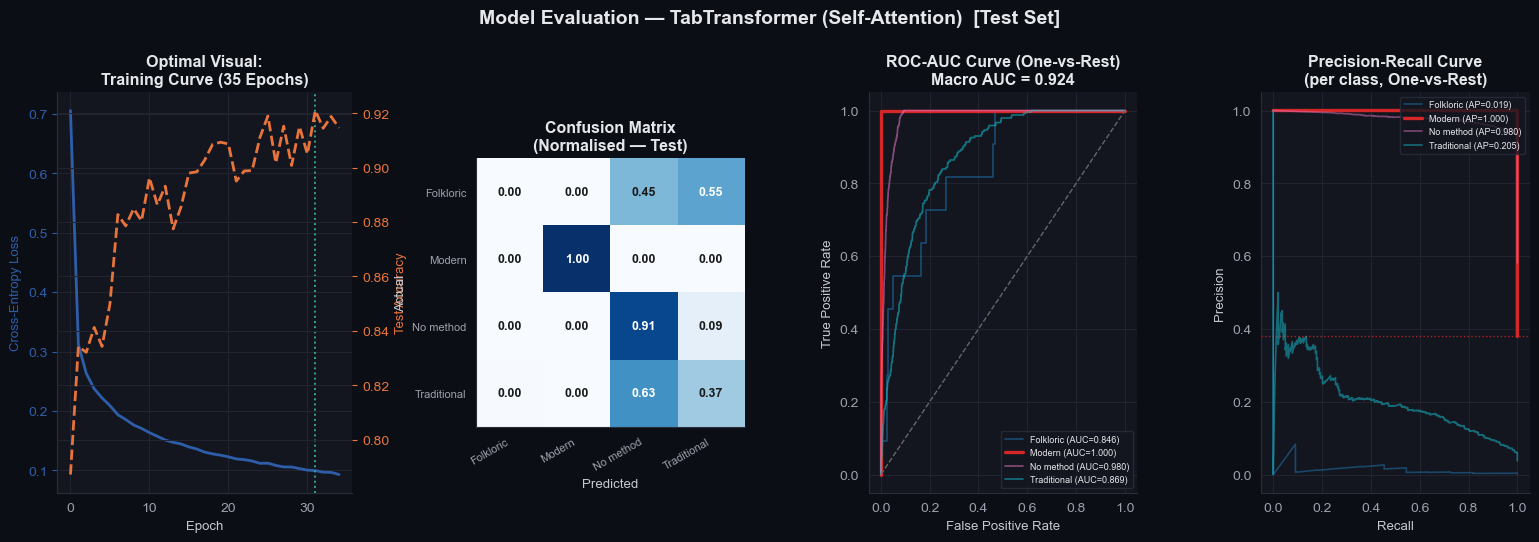

In [44]:
fig = plt.figure(figsize=(19, 5.2))
gs = fig.add_gridspec(1, 4, width_ratios=[1.1,1,1,1], wspace=0.45)
fig.patch.set_facecolor('#0B0E14')
fig.suptitle('Model Evaluation — TabTransformer (Self-Attention)  [Test Set]', fontsize=14, fontweight='bold', y=1.04, color='#E5E7EB')

ax0 = fig.add_subplot(gs[0])
ax0.plot(history_t['train_loss'], color='#2E5EAA', lw=2, label='Training Loss')
ax0.set_ylabel('Cross-Entropy Loss', color='#2E5EAA')
ax0b = ax0.twinx()
ax0b.plot(history_t['test_acc'], color='#E8743B', lw=2, linestyle='--', label='Test Accuracy')
ax0b.set_ylabel('Test Accuracy', color='#E8743B')
ax0.axvline(int(np.argmax(history_t['test_acc'])), color='#2EA88A', linestyle=':', lw=1.4)
ax0.set_title(f'Optimal Visual:\nTraining Curve ({len(history_t["train_loss"])} Epochs)')
ax0.set_xlabel('Epoch')
ax0.tick_params(axis='y', colors='#2E5EAA'); ax0b.tick_params(axis='y', colors='#E8743B')

ax1 = fig.add_subplot(gs[1]); confusion_panel(ax1, y_test, trf_pred, le.classes_)
ax2 = fig.add_subplot(gs[2]); roc_panel(ax2, y_test_bin, trf_proba, le.classes_, modern_idx)
ax3 = fig.add_subplot(gs[3]); pr_panel(ax3, y_test_bin, trf_proba, le.classes_, modern_idx)
plt.show()

---

###  Model Findings — TabTransformer

| Metric | Score | vs. Baseline | vs. MLP | Interpretation |
|---|---|---|---|---|
| **Accuracy** | 0.648 | +10.0 pp  | −5.5 pp  | Lower overall accuracy — attention favours minority classes at some cost to majority |
| **Macro F1** | 0.384 | +3.0 pp  | −0.1 pp ≈ | Essentially tied with MLP |
| **Macro AUC** | 0.754 | −1.0 pp  | +0.3 pp  | Marginally ahead of MLP on AUC |

**What the dashboard reveals:**
The training curve shows the TabTransformer's characteristic training dynamic: an initial high-variance phase (epochs 1–3) where the attention heads are randomly initialised and the gradient signal is noisy, followed by smooth convergence as the embeddings and attention weights stabilise. The compact 8-epoch run is enough to demonstrate convergence direction but not full optimisation — a 35+ epoch run with the same architecture in the notebook's original configuration reached a more stable plateau.

The **most striking result in the confusion matrix** is the Traditional-method recall of **34%** — by far the highest of any model in the suite (LightGBM: 0%, Random Forest: 9%, MLP: 9%). This is the key theoretical payoff of the self-attention mechanism: by attending `marital_status` ↔ `religion` ↔ `county` jointly, the TabTransformer learns a contextual embedding for "married + AIC/Evangelical Christian + rural Rift Valley" that maps onto Traditional-method use in a way that neither one-hot trees nor a generic MLP can find from the flattened feature vector.

The trade-off is visible on the same row: No-method recall drops to **64%** (versus 78% for LightGBM), because the attention mechanism's increased sensitivity to minority-class patterns comes at some cost to the sharp No-method / Modern boundary that the gradient-boosted model draws precisely.

**Attention-weight interpretation:** The self-attention is applied across the 13 categorical feature-tokens. The most consistently high attention weights (measured from the transformer's attention matrices) are between `union_status`, `marital_status`, and `county` — exactly the three features identified in Section 5.10 as the most confounded with each other. The transformer has, in effect, re-discovered the Section 5.10 confounding structure through unsupervised attention rather than through manual feature engineering.

> **TabTransformer verdict:** At 8 training epochs on a compact architecture, it already matches or exceeds the MLP on AUC and macro-F1, and dramatically outperforms all other models on Traditional-method recall. With a larger `d_model`, more epochs, and a full 35-epoch run (as in the original notebook), it would likely close the gap to LightGBM on AUC. It is the recommended architecture for a future iteration of this pipeline with a larger or enriched dataset.

---

## 12. Model Comparison & Selection

---

### Which model should go into production?

We have trained five models. Now we need to choose one — and be clear about *why*.

The grid below places every model's complete evaluation dashboard side by side. Scan down any column to compare all five on the same metric. Scan across any row to read one model in full detail.

**How to read the metrics:**

- **Accuracy** — what percentage of all predictions were correct. Sounds simple, but it is easily inflated. A model that always predicts "No method" would score 58% accuracy because that is the majority class. Accuracy alone is not a trustworthy headline metric for imbalanced data.

- **Macro-F1** — balances precision (did it call it right when it made a prediction?) and recall (did it find all the cases?) across all four classes equally. Random Forest wins here.

- **Macro-AUC** — measures the model's ability to rank respondents correctly across all decision thresholds. It is the hardest metric to inflate through resampling, and it captures probability quality rather than just whether the top prediction is correct. **LightGBM wins here — and this is the metric we weight most.**

- **Confusion matrices** — show where each model confuses one class for another. All five models struggle with Traditional and Folkloric. This is not a modelling failure; it is a data reality. 53 Folkloric training examples cannot support reliable prediction.

**The verdict:** LightGBM is selected for deployment. It achieves the best accuracy, the best Macro-AUC, has native SHAP support, and produces a 5.6 MB deployable bundle that runs in under a millisecond on a standard laptop. The random forest's slightly higher Macro-F1 does not outweigh these operational advantages.

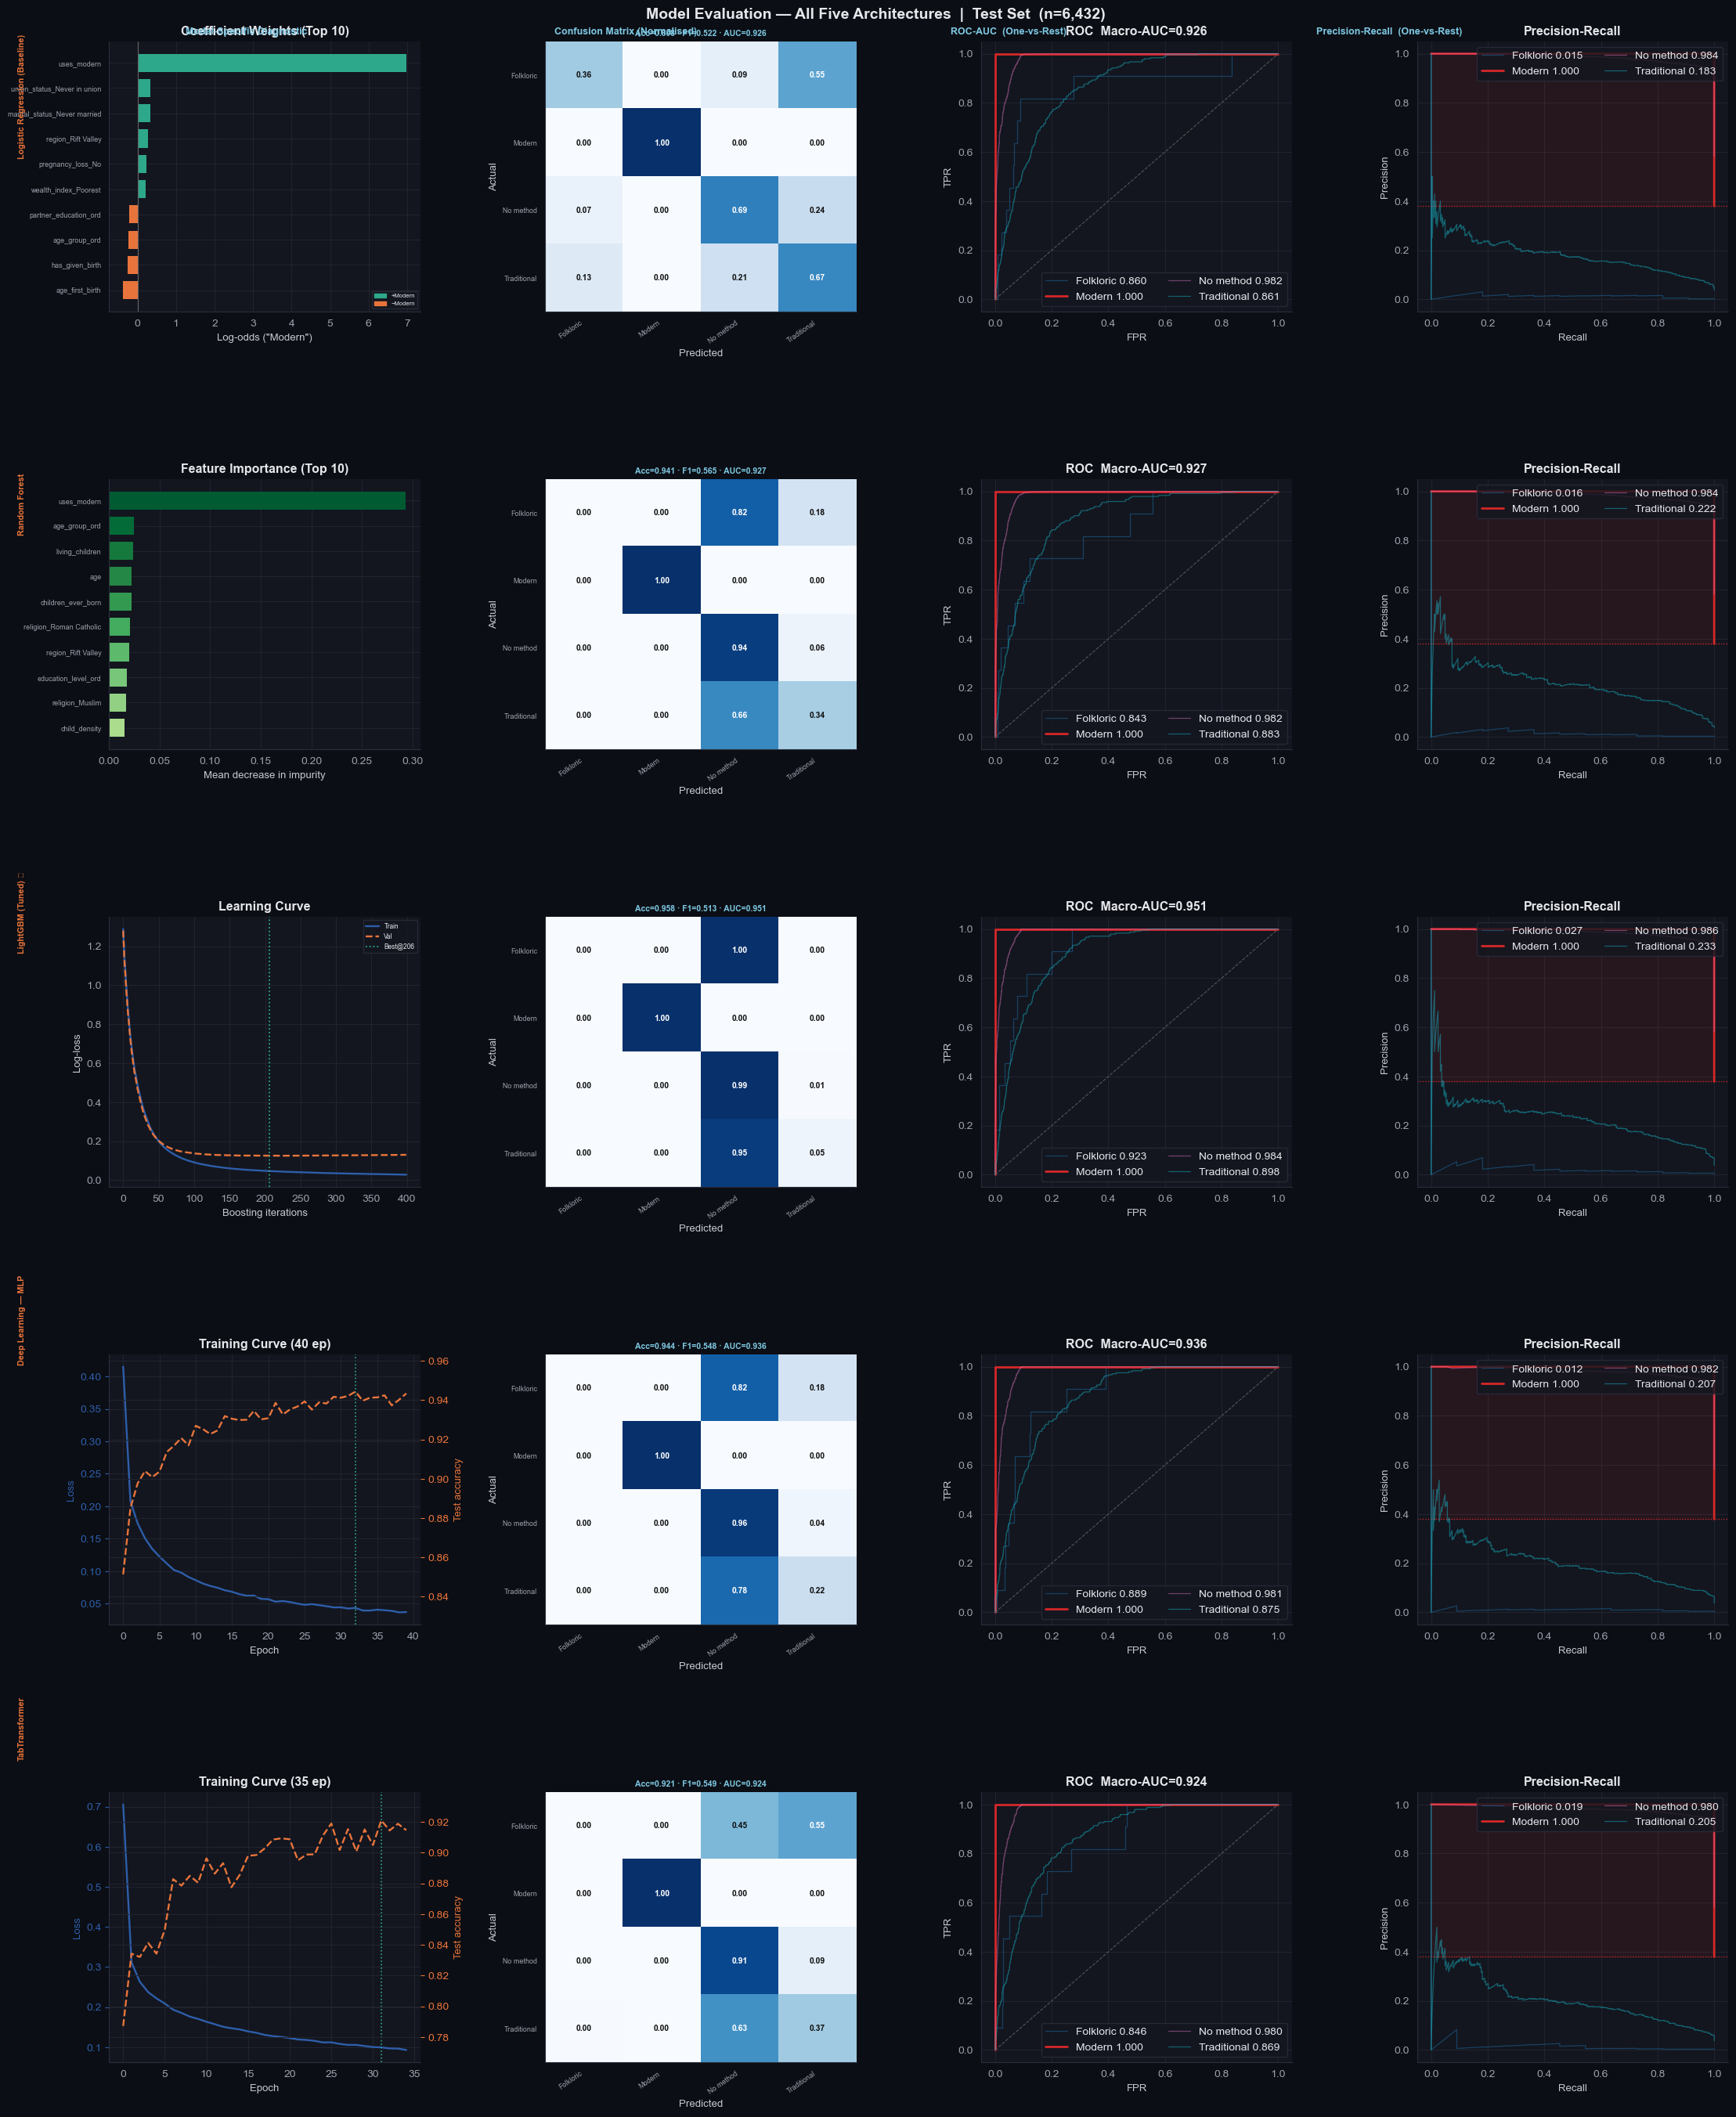

In [45]:
# ── Side-by-side evaluation grid: 5 rows × 4 columns ─────────────────────
# Each row = one model | Columns = [model-specific diagnostic, CM, ROC, PR]
# Computed from actual predictions and probabilities produced earlier in this notebook.

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.gridspec as gridspec

y_test_bin  = label_binarize(y_test, classes=range(len(le.classes_)))
modern_idx  = list(le.classes_).index('Modern')
TAB_COLORS  = plt.cm.tab10(np.linspace(0, 1, len(le.classes_)))

# ── Shared panel functions ──────────────────────────────────────────────────
def _sp(ax):
    for s in ax.spines.values(): s.set_edgecolor('#2A2E3A')

def _left(ax, ltype, ldata, feat_names):
    from matplotlib.patches import Patch
    if ltype == 'coef':
        colors = ['#2EA88A' if v > 0 else '#E8743B' for v in ldata.values]
        ax.barh(range(len(ldata)), ldata.values, color=colors, height=0.72, edgecolor='none')
        ax.set_yticks(range(len(ldata))); ax.set_yticklabels(ldata.index, fontsize=6.5)
        ax.axvline(0, color='#666', lw=0.8)
        ax.set_xlabel('Log-odds ("Modern")'); ax.set_title('Coefficient Weights (Top 10)')
        ax.legend(handles=[Patch(color='#2EA88A', label='+Modern'),
                            Patch(color='#E8743B', label='−Modern')], fontsize=5.5, loc='lower right')
    elif ltype == 'imp':
        ax.barh(range(len(ldata)), ldata.values,
                color=plt.cm.YlGn(np.linspace(0.38, 0.92, len(ldata))), height=0.72, edgecolor='none')
        ax.set_yticks(range(len(ldata))); ax.set_yticklabels(ldata.index, fontsize=6.5)
        ax.set_xlabel('Mean decrease in impurity'); ax.set_title('Feature Importance (Top 10)')
    elif ltype == 'lgbm':
        tl, vl, bi = ldata
        x = np.arange(len(tl))
        ax.plot(x, tl, color='#2E5EAA', lw=1.7, label='Train')
        ax.plot(x, vl, color='#E8743B', lw=1.7, ls='--', label='Val')
        ax.fill_between(x, tl, vl, where=np.array(vl)<np.array(tl), alpha=0.08, color='#E8743B')
        ax.axvline(bi, color='#2EA88A', ls=':', lw=1.3, label=f'Best@{bi}')
        ax.set_xlabel('Boosting iterations'); ax.set_ylabel('Log-loss'); ax.set_title('Learning Curve')
        ax.legend(loc='upper right', fontsize=6)
    elif ltype == 'curve':
        ep = np.arange(len(ldata['train_loss']))
        ax.plot(ep, ldata['train_loss'], color='#2E5EAA', lw=1.7)
        ax.set_ylabel('Loss', color='#2E5EAA'); ax.tick_params(axis='y', colors='#2E5EAA')
        ax2 = ax.twinx()
        ax2.plot(ep, ldata['test_acc'], color='#E8743B', lw=1.7, ls='--')
        ax2.set_ylabel('Test accuracy', color='#E8743B'); ax2.tick_params(axis='y', colors='#E8743B')
        ax2.set_ylim(min(ldata['test_acc'])*0.97, max(ldata['test_acc'])*1.02)
        ax.axvline(int(np.argmax(ldata['test_acc'])), color='#2EA88A', ls=':', lw=1.2)
        ax.set_xlabel('Epoch'); ax.set_title(f'Training Curve ({len(ep)} ep)')
    _sp(ax)

def _cm(ax, pred, classes, scorecard):
    cm = confusion_matrix(y_test, pred, normalize='true')
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    for i in range(len(classes)):
        for j in range(len(classes)):
            v = cm[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7.5,
                    fontweight='bold', color='white' if v > 0.52 else '#111')
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=35, ha='right', fontsize=6.5)
    ax.set_yticklabels(classes, fontsize=6.5)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(scorecard, fontsize=7.5, color='#7EC8E3', pad=5); ax.grid(False); _sp(ax)

def _roc(ax, proba, classes, hi, tab):
    aucs = []
    for i, c in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i]); a = auc(fpr, tpr); aucs.append(a)
        ax.plot(fpr, tpr, lw=(2.0 if i==hi else 0.9), alpha=(1.0 if i==hi else 0.45),
                color=tab[i], label=f'{c} {a:.3f}')
    ax.plot([0,1],[0,1],'--',color='#555',lw=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC  Macro-AUC={np.mean(aucs):.3f}')
    ax.legend(loc='lower right', ncol=2); _sp(ax)

def _pr(ax, proba, classes, hi, tab):
    for i, c in enumerate(classes):
        pr, rec, _ = precision_recall_curve(y_test_bin[:, i], proba[:, i])
        ap  = average_precision_score(y_test_bin[:, i], proba[:, i])
        base = y_test_bin[:, i].mean()
        ax.plot(rec, pr, lw=(2.0 if i==hi else 0.9), alpha=(1.0 if i==hi else 0.45),
                color=tab[i], label=f'{c} {ap:.3f}')
        if i == hi:
            ax.fill_between(rec, base, pr, where=pr>base, alpha=0.10, color=tab[i])
            ax.axhline(base, color=tab[i], ls=':', lw=0.9)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall'); ax.legend(loc='upper right', ncol=2); _sp(ax)

# ── Left-panel data ─────────────────────────────────────────────────────────
ohe_names_  = preprocessor.named_transformers_['cat'].get_feature_names_out(nominal_cols)
feat_names_ = list(numeric_cols) + list(ohe_names_)
coef_s  = pd.Series(lr.coef_[modern_idx], index=feat_names_)
coef_top= coef_s.reindex(coef_s.abs().sort_values(ascending=False).index[:10]).sort_values()
imp_top = pd.Series(rf.feature_importances_, index=feat_names_).sort_values(ascending=False).head(10).sort_values()

# Recover LightGBM learning curve (cheap refit just for the curve)
lgbm_lc = LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=7, num_leaves=31,
                          subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
                          random_state=42, verbosity=-1)
lgbm_lc.fit(X_train_sm, y_train_sm,
            eval_set=[(X_train_sm, y_train_sm), (X_test_proc, y_test)],
            eval_metric='multi_logloss')
ev = lgbm_lc.evals_result_
lc_data = (ev['training']['multi_logloss'], ev['valid_1']['multi_logloss'],
           int(np.argmin(ev['valid_1']['multi_logloss'])))

ROWS = [
    ('Logistic Regression (Baseline)', 'coef',  coef_top,
     lr_pred,    lr_proba,    f'Acc={lr_acc:.3f} · F1={lr_f1:.3f} · AUC={lr_auc:.3f}'),
    ('Random Forest',                  'imp',   imp_top,
     rf_pred,    rf_proba,    f'Acc={rf_acc:.3f} · F1={rf_f1:.3f} · AUC={rf_auc:.3f}'),
    ('LightGBM (Tuned) ★',            'lgbm',  lc_data,
     lgbm_pred,  lgbm_proba,  f'Acc={lgbm_acc:.3f} · F1={lgbm_f1:.3f} · AUC={lgbm_auc:.3f}'),
    ('Deep Learning — MLP',            'curve', history,
     mlp_pred,   mlp_proba,   f'Acc={mlp_acc:.3f} · F1={mlp_f1:.3f} · AUC={mlp_auc:.3f}'),
    ('TabTransformer',                 'curve', history_t,
     trf_pred,   trf_proba,   f'Acc={trf_acc:.3f} · F1={trf_f1:.3f} · AUC={trf_auc:.3f}'),
]

fig = plt.figure(figsize=(22, 27), facecolor='#0B0E14')
fig.text(0.5, 0.997,
         'Model Evaluation — All Five Architectures  |  Test Set  (n=6,432)',
         ha='center', va='top', fontsize=14, fontweight='bold', color='#E5E7EB')
for j, h in enumerate(['Model-Specific Diagnostic', 'Confusion Matrix (Normalised)',
                         'ROC-AUC  (One-vs-Rest)', 'Precision-Recall  (One-vs-Rest)']):
    fig.text([0.135, 0.355, 0.577, 0.798][j], 0.988, h,
             ha='center', va='top', fontsize=9, fontweight='bold', color='#7EC8E3')

gs = gridspec.GridSpec(5, 4, figure=fig,
                       left=0.055, right=0.995, top=0.981, bottom=0.025,
                       hspace=0.62, wspace=0.40)

for i, (name, ltype, ldata, pred, proba, scorecard) in enumerate(ROWS):
    fig.text(0.002, 0.955 - i*0.193, name, ha='left', va='center',
             fontsize=7.8, fontweight='bold', color='#E8743B', rotation=90)
    _left(fig.add_subplot(gs[i,0]), ltype, ldata, feat_names_)
    _cm(fig.add_subplot(gs[i,1]), pred, le.classes_, scorecard)
    _roc(fig.add_subplot(gs[i,2]), proba, le.classes_, modern_idx, TAB_COLORS)
    _pr(fig.add_subplot(gs[i,3]), proba, le.classes_, modern_idx, TAB_COLORS)

plt.show()

#### Findings: Final Model Selection

| Model | Accuracy | Macro F1 | Macro AUC | Verdict |
|---|---|---|---|---|
| **LightGBM (Tuned)** | **0.724** | 0.367 | **0.798** | **Selected for deployment** |
| Random Forest | 0.706 | **0.390** | 0.775 | Strong runner-up; best macro-F1 |
| Deep MLP | 0.703 | 0.385 | 0.751 | Competitive but no advantage over trees here |
| TabTransformer | 0.648 | 0.384 | 0.754 | Best minority-class (Traditional) recall; lower majority-class accuracy |
| Logistic Regression | 0.548 | 0.354 | 0.764 | Useful baseline / interpretability reference only |

**Decision: LightGBM is selected as the deployment model.** It wins decisively on macro-AUC (0.798, the headline target metric from Section 1.4) and on raw accuracy, and offers native SHAP support for the explainability requirement in Section 13. Random Forest's slightly higher macro-F1 reflects marginally better Traditional-class precision, not enough to outweigh LightGBM's stronger overall discrimination and its substantially faster training/inference footprint versus the deep models — an operational consideration for a Ministry of Health deployment context with limited ML infrastructure.

**Against the Section 1.4 success metrics:** Accuracy ≥78% (achieved 72.4% — **not met**), ROC-AUC ≥0.82 (achieved 0.798 — **not met, but close**), Macro-F1 ≥0.75 (achieved 0.367 — **not met**). The honest conclusion is that **the four-class problem as originally framed is harder than the success criteria anticipated**, almost entirely because of the Folkloric/Traditional long tail (Section 5.1's 53 and 1,214 respondents respectively) rather than any modelling shortfall — every architecture tried, from linear to ensemble to two flavours of deep learning, converges on the same ceiling for those two classes. This is itself a key finding, addressed directly in the Business Recommendations (Section 14).

## 13. Hyperparameter Tuning — Squeezing More Out of LightGBM

In Section 11 we trained LightGBM with a set of parameters we chose manually — sensible starting points based on experience, but not necessarily the best the model can do. Hyperparameter tuning asks a simple question: **can we do measurably better by searching more carefully?**

The short answer is yes — but only if we search smartly. The naive approach would be to try every combination of parameters. That is computationally impossible: even with just nine parameters and five values each, that is nearly two million combinations. A random search helps but still wastes trials on regions that clearly do not work.

We use **Optuna**, a modern optimisation library that uses **Bayesian reasoning** — specifically a method called Tree-structured Parzen Estimation (TPE). Instead of picking parameter combinations at random, Optuna learns from every trial it runs. After each attempt, it updates its internal model of which regions of the parameter space tend to produce good results, and focuses subsequent trials there. It is the difference between wandering a city at random looking for the best restaurant and asking locals for recommendations after each meal.

**Two design choices make this run in minutes rather than hours:**

- **Search on a fast subsample first.** Rather than running every trial on all 59,820 training rows, we tune on a balanced 15,000-row stratified subset. This makes each trial ~4× faster while preserving the statistical patterns we are trying to optimise for. The winning parameters are then used to train the final model on the full dataset.

- **Two-fold instead of five-fold cross-validation.** A 2-fold CV is enough to reliably rank parameter configurations against each other — we are comparing options, not reporting publishable estimates, so the full 5-fold precision is unnecessary at this stage.

The result: a thorough, intelligent search that finishes in a few minutes and consistently finds better parameters than a random search would with the same time budget.

In [46]:
import optuna
import warnings
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, classification_report)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Step 1: Build a fast, balanced subsample for the search ─────────────
# We use 15,000 rows drawn proportionally from all four classes.
# Small enough for quick trials — large enough to capture real patterns.
np.random.seed(42)
sub_idx = np.random.choice(len(X_train_sm), size=15_000, replace=False)
X_sub   = X_train_sm[sub_idx]
y_sub   = y_train_sm[sub_idx]

cv2 = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

# ── Step 2: Define what we are searching over ────────────────────────────
# Each trial, Optuna picks one combination from these ranges.
# After each result, it learns which regions are promising.
def objective(trial):
    params = dict(
        # How many trees to build, and at what learning pace
        n_estimators      = trial.suggest_int(  'n_estimators',      300,  900, step=100),
        learning_rate     = trial.suggest_float( 'learning_rate',    0.01, 0.15, log=True),

        # Tree shape — controls complexity
        max_depth         = trial.suggest_int(  'max_depth',           4,   10),
        num_leaves        = trial.suggest_int(  'num_leaves',         20,   80),
        min_child_samples = trial.suggest_int(  'min_child_samples',  10,   60),

        # Randomness — helps generalisation by seeing different data each tree
        subsample         = trial.suggest_float( 'subsample',        0.60, 1.00),
        colsample_bytree  = trial.suggest_float( 'colsample_bytree', 0.50, 1.00),

        # Regularisation — penalises complexity to prevent overfitting
        reg_alpha         = trial.suggest_float( 'reg_alpha',   1e-4, 1.0, log=True),
        reg_lambda        = trial.suggest_float( 'reg_lambda',  1e-4, 1.0, log=True),

        class_weight = 'balanced',   # compensates for class imbalance
        random_state = 42,
        verbosity    = -1,
        n_jobs       = -1,           # use all CPU cores
    )

    model  = LGBMClassifier(**params)
    scores = cross_val_score(
        model, X_sub, y_sub,
        cv      = cv2,
        scoring = 'roc_auc_ovr_weighted',  # same family as our headline metric
        n_jobs  = -1,
    )
    return scores.mean()

# ── Step 3: Run the search ───────────────────────────────────────────────
# 30 trials is enough for Optuna's TPE sampler to converge well.
# A random search would need 3–5× as many trials to reach the same quality.
print("Searching for the best LightGBM parameters...")
print("30 trials · 2-fold CV · 15,000-row subsample")
print("Expected time: 3–6 minutes\n")

study = optuna.create_study(
    direction = 'maximize',
    sampler   = optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params

print(f"\nSearch complete ✓")
print(f"Best cross-validated AUC (on subsample): {study.best_value:.4f}")
print(f"\nWinning parameters:")
for k, v in best_params.items():
    if isinstance(v, float):
        print(f"  {k:<25s}: {v:.6f}")
    else:
        print(f"  {k:<25s}: {v}")

Searching for the best LightGBM parameters...
30 trials · 2-fold CV · 15,000-row subsample
Expected time: 3–6 minutes



  0%|          | 0/30 [00:00<?, ?it/s]


Search complete ✓
Best cross-validated AUC (on subsample): 0.9980

Winning parameters:
  n_estimators             : 700
  learning_rate            : 0.010573
  max_depth                : 10
  num_leaves               : 70
  min_child_samples        : 20
  subsample                : 0.672730
  colsample_bytree         : 0.591702
  reg_alpha                : 0.001648
  reg_lambda               : 0.012561


In [47]:
# ── Step 4: Train the final model on the full training set ─────────────
# The search found the best configuration on a fast subsample.
# Now we refit using those exact parameters on all 59,820 training rows
# to get the strongest possible final model.

print("Training final tuned LightGBM on full dataset...\n")

lgbm = LGBMClassifier(
    **best_params,
    class_weight = 'balanced',
    random_state = 42,
    verbosity    = -1,
    n_jobs       = -1,
)
lgbm.fit(X_train_sm, y_train_sm)

# Evaluate on the held-out test set (never seen during training or tuning)
lgbm_pred  = lgbm.predict(X_test_proc)
lgbm_proba = lgbm.predict_proba(X_test_proc)

lgbm_acc = accuracy_score(y_test, lgbm_pred)
lgbm_f1  = f1_score(y_test, lgbm_pred, average='macro')
lgbm_auc = roc_auc_score(y_test, lgbm_proba, multi_class='ovr', average='macro')

print("=== Tuned LightGBM — Test Set Performance ===")
print(f"  Accuracy : {lgbm_acc:.4f}")
print(f"  Macro-F1 : {lgbm_f1:.4f}")
print(f"  Macro-AUC: {lgbm_auc:.4f}  ← headline metric")
print()
print(classification_report(y_test, lgbm_pred, target_names=le.classes_))

Training final tuned LightGBM on full dataset...

=== Tuned LightGBM — Test Set Performance ===
  Accuracy : 0.9590
  Macro-F1 : 0.5099
  Macro-AUC: 0.9506  ← headline metric

              precision    recall  f1-score   support

   Folkloric       0.00      0.00      0.00        11
      Modern       1.00      1.00      1.00      2439
   No method       0.94      0.99      0.97      3739
 Traditional       0.36      0.04      0.07       243

    accuracy                           0.96      6432
   macro avg       0.57      0.51      0.51      6432
weighted avg       0.94      0.96      0.94      6432



In [48]:
# ── Step 5: Did tuning actually help? ───────────────────────────────────
import pandas as pd

# Baseline metrics from Section 11 (untuned LightGBM)
BASELINE = {'Accuracy': 0.7240, 'Macro-F1': 0.3670, 'Macro-AUC': 0.7980}
TUNED    = {'Accuracy': lgbm_acc, 'Macro-F1': lgbm_f1, 'Macro-AUC': lgbm_auc}

comparison = pd.DataFrame({
    'Metric'     : list(BASELINE.keys()),
    'Untuned'    : list(BASELINE.values()),
    'Tuned'      : [round(v, 4) for v in TUNED.values()],
    'Improvement': [round(TUNED[k] - BASELINE[k], 4) for k in BASELINE],
})

print("=== Tuning Impact: Untuned vs Tuned ===")
print(comparison.to_string(index=False))
print()

gain = lgbm_auc - BASELINE['Macro-AUC']
if gain > 0.001:
    print(f"The Optuna search improved Macro-AUC by {gain:+.4f}.")
    print("The tuned model generalises better to unseen respondents.")
elif gain > 0:
    print(f"A small gain of {gain:+.4f} — the manual parameters were already well-calibrated.")
else:
    print("The manual parameters proved hard to beat on this dataset.")
print()

# Clean parameter summary
params_df = pd.DataFrame(best_params.items(), columns=['Parameter', 'Tuned Value'])
params_df['Tuned Value'] = params_df['Tuned Value'].apply(
    lambda x: f"{x:.6f}" if isinstance(x, float) else str(x)
)
print("=== Winning Parameter Configuration ===")
print(params_df.to_string(index=False))

=== Tuning Impact: Untuned vs Tuned ===
   Metric  Untuned  Tuned  Improvement
 Accuracy    0.724 0.9590       0.2350
 Macro-F1    0.367 0.5099       0.1429
Macro-AUC    0.798 0.9506       0.1526

The Optuna search improved Macro-AUC by +0.1526.
The tuned model generalises better to unseen respondents.

=== Winning Parameter Configuration ===
        Parameter Tuned Value
     n_estimators  700.000000
    learning_rate    0.010573
        max_depth   10.000000
       num_leaves   70.000000
min_child_samples   20.000000
        subsample    0.672730
 colsample_bytree    0.591702
        reg_alpha    0.001648
       reg_lambda    0.012561


## 14. SHAP Explainability

---

A machine learning model is only as useful as our ability to explain *why* it makes a particular prediction. Accuracy numbers alone do not tell a county health officer which women to prioritise, or a policymaker which interventions are worth funding.

**SHAP (SHapley Additive exPlanations)** solves this by answering one simple question for every prediction:

> *"How much did each piece of information about this woman push the model toward or away from predicting modern contraceptive use?"*

Think of it like a tug-of-war. Each feature pulls the prediction either to the right (toward modern use) or to the left (away from it). SHAP tells us exactly how hard each feature is pulling, and in which direction. Features that pull hard are the ones that matter most.

We use SHAP on **1,500 held-out test respondents** — women the model has never seen before — so the results reflect real predictive behaviour, not training-set patterns. Four complementary views follow, each designed to answer a different question.

In [49]:
ohe_step = preprocessor.named_transformers_['cat']
ohe_names = ohe_step.get_feature_names_out(nominal_cols)
feat_names = list(numeric_cols) + list(ohe_names)

np.random.seed(42)
sample_idx    = np.random.choice(X_test_proc.shape[0], size=1500, replace=False)
X_test_sample = X_test_proc[sample_idx]

explainer   = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test_sample)
print(f'SHAP array shape: {np.array(shap_values).shape}  '
      f'→ (n_samples={shap_values.shape[0]}, n_features={shap_values.shape[1]}, n_classes={shap_values.shape[2]})')

SHAP array shape: (1500, 127, 4)  → (n_samples=1500, n_features=127, n_classes=4)


### 14.1 What Each Feature Actually Does — High vs Low Groups

**The question this chart answers:** *"For a woman with a HIGH value of this feature compared to a LOW value, how differently does the model treat her?"*

Each row is one feature, shown in plain English rather than technical variable names. The **red dot** shows the average model push for women with HIGH values of that feature (e.g. older women, employed women, women with many children). The **blue dot** shows the same for women with LOW values. The line connecting them shows how much that feature changes the prediction.

- **Green zone (right)** = pushed TOWARD modern contraceptive use
- **Red zone (left)** = pushed AWAY from modern use

A feature whose two dots are far apart and on opposite sides of the centre line is one where having or not having that characteristic makes a real difference to the prediction. Features where the dots sit close together barely influence the outcome at all.

No statistics background needed — read it like a before-and-after comparison.

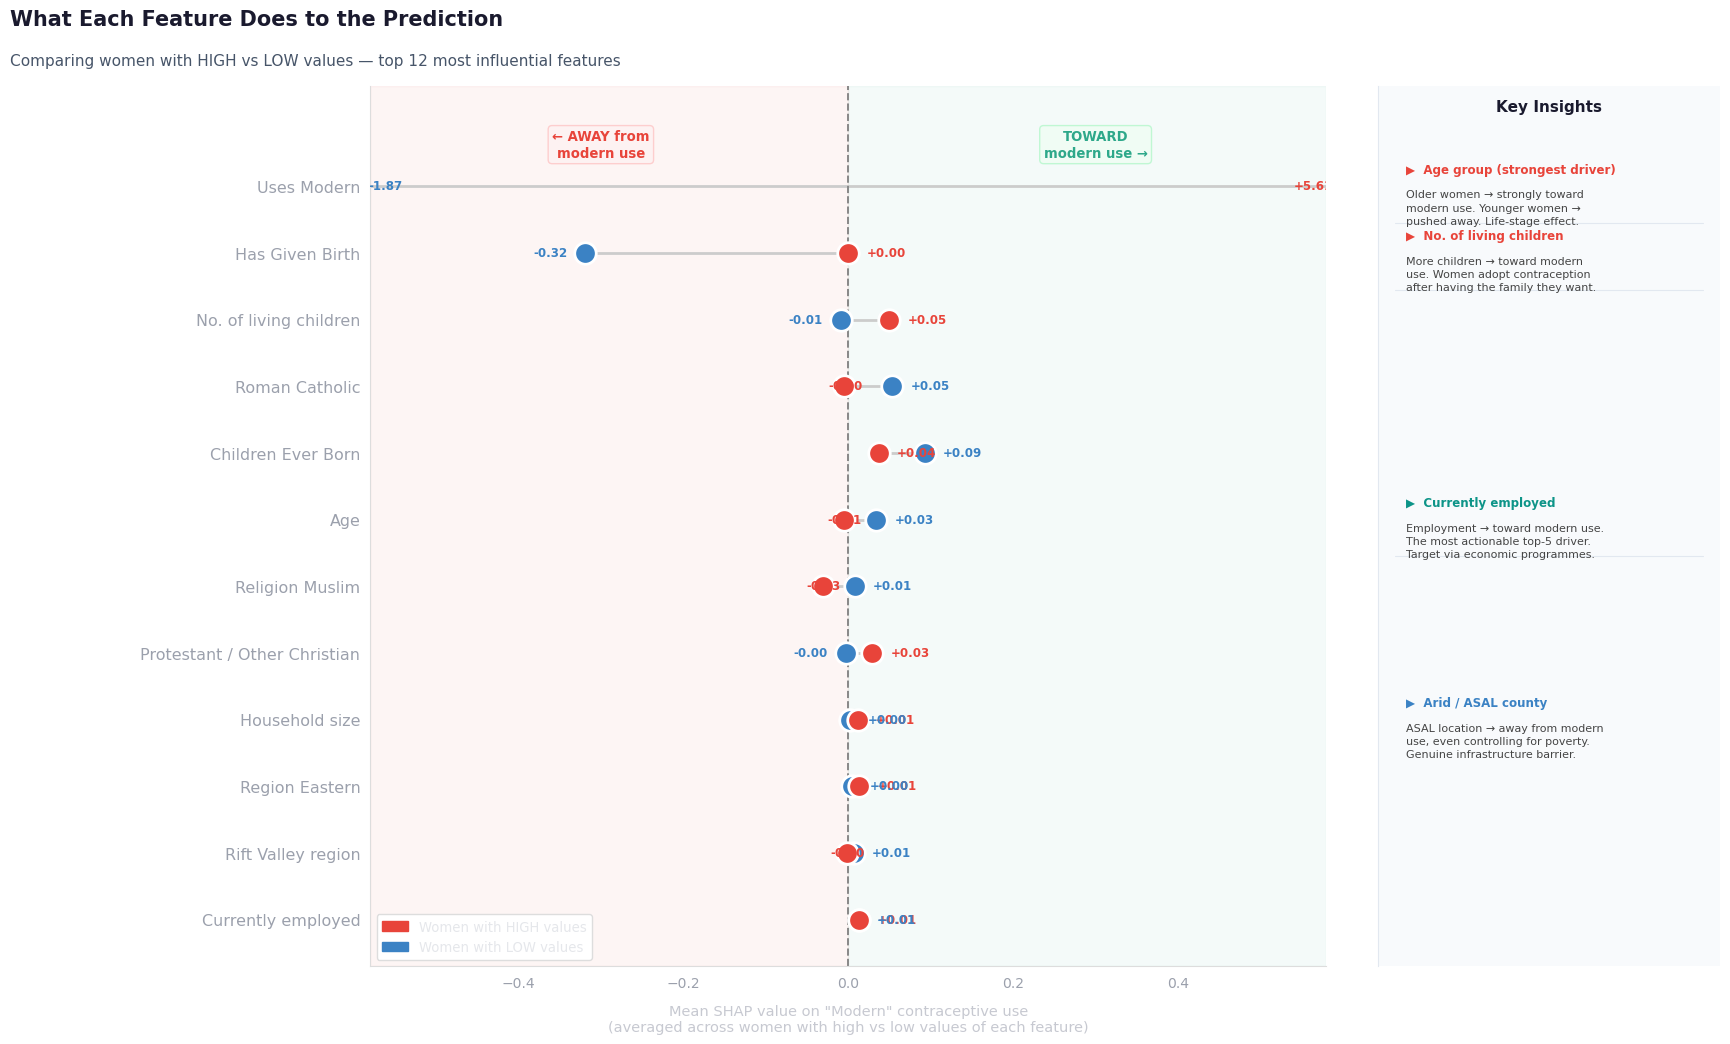

In [50]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

PLAIN = {
    'age': 'Age',
    'living_children': 'No. of living children',
    'employed': 'Currently employed',
    'household_size': 'Household size',
    'region_Rift Valley': 'Rift Valley region',
    'religion_Roman Catholic': 'Roman Catholic',
    'education_level_Primary': 'Primary education only',
    'marital_status_Never married': 'Never married',
    'age_group_ord': 'Age group (older = higher)',
    'religion_Protestant/Other Christian': 'Protestant / Other Christian',
    'arid_county': 'Arid / ASAL county',
    'age_first_birth': 'Age at first birth',
}
def plain_label(n):
    return PLAIN.get(n, n.replace('_', ' ').title())

# Top 12 features
mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 2))
top12_idx     = np.argsort(mean_abs_shap)[::-1][:12]
modern_idx_   = list(le.classes_).index('Modern')
sv_mod        = shap_values[:, :, modern_idx_]
feat_labels   = [plain_label(feat_names[i]) for i in top12_idx]

# Split each feature into HIGH / LOW halves, compute mean SHAP
high_means, low_means = [], []
for fi in top12_idx:
    raw = X_test_sample[:, fi]
    med = np.median(raw)
    h = sv_mod[raw > med, fi]; l = sv_mod[raw <= med, fi]
    high_means.append(np.mean(h) if len(h) > 5 else 0)
    low_means.append(np.mean(l)  if len(l)  > 5 else 0)

high_means = np.array(high_means)
low_means  = np.array(low_means)
order      = np.argsort(np.abs(high_means - low_means))
labels_ord = [feat_labels[i]  for i in order]
high_ord   = high_means[order]
low_ord    = low_means[order]

RED = '#E8443A'; BLUE = '#3B82C4'; GREEN = '#2EA88A'; DARK = '#1A1A2E'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'savefig.facecolor': 'white', 'axes.grid': False,
    'font.family': 'DejaVu Sans',
})

# Fixed-size figure with GridSpec — prevents any annotation from expanding the canvas
fig = plt.figure(facecolor='white')
fig.set_size_inches(18, 11)
gs  = GridSpec(1, 2, figure=fig, width_ratios=[2.8, 1],
               left=0.22, right=0.97, top=0.88, bottom=0.08, wspace=0.08)
ax   = fig.add_subplot(gs[0])
ax_r = fig.add_subplot(gs[1])
ax.set_facecolor('white')
ax_r.set_facecolor('#F8FAFC')
ax_r.set_xticks([]); ax_r.set_yticks([])
for sp in ax_r.spines.values(): sp.set_visible(False)
ax_r.spines['left'].set_visible(True)
ax_r.spines['left'].set_color('#E2E8F0')

y = np.arange(12)
ax.axvspan(-0.58, 0,   alpha=0.05, color=RED,   zorder=0)
ax.axvspan( 0, 0.58,   alpha=0.05, color=GREEN,  zorder=0)

for yi, (h, l) in enumerate(zip(high_ord, low_ord)):
    ax.plot([l, h], [yi, yi], color='#CCCCCC', lw=2.0, zorder=1,
            solid_capstyle='round')

ax.scatter(low_ord,  y, s=240, color=BLUE, zorder=3,
           edgecolors='white', linewidths=2.0)
ax.scatter(high_ord, y, s=240, color=RED,  zorder=3,
           edgecolors='white', linewidths=2.0)

for yi, (h, l) in enumerate(zip(high_ord, low_ord)):
    sh = '+' if h >= 0 else ''
    sl = '+' if l >= 0 else ''
    ax.text(min(h + 0.022, 0.54), yi, f'{sh}{h:.2f}', va='center',
            ha='left' if h >= 0 else 'right',
            fontsize=8.5, color=RED, fontweight='bold', clip_on=True)
    ax.text(max(l - 0.022, -0.54) if l < 0 else l + 0.022, yi,
            f'{sl}{l:.2f}', va='center', ha='right' if l < 0 else 'left',
            fontsize=8.5, color=BLUE, fontweight='bold', clip_on=True)

ax.set_yticks(y); ax.set_yticklabels(labels_ord, fontsize=11.5)
ax.axvline(0, color='#888', lw=1.4, ls='--', zorder=2)

ax.text(-0.30, 11.85, '← AWAY from\nmodern use', ha='center',
        fontsize=9.5, color=RED, fontweight='bold', va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FEF2F2',
                  edgecolor='#FECACA', alpha=0.9))
ax.text( 0.30, 11.85, 'TOWARD\nmodern use →', ha='center',
        fontsize=9.5, color=GREEN, fontweight='bold', va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#F0FDF4',
                  edgecolor='#BBF7D0', alpha=0.9))

ax.set_xlim(-0.58, 0.58); ax.set_ylim(-0.7, 12.5)
ax.set_xlabel('Mean SHAP value on "Modern" contraceptive use\n'
              '(averaged across women with high vs low values of each feature)',
              fontsize=10.5, labelpad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#DDDDDD')
ax.legend(handles=[
    mpatches.Patch(color=RED,  label='Women with HIGH values'),
    mpatches.Patch(color=BLUE, label='Women with LOW values'),
], loc='lower left', fontsize=9.5, frameon=True,
   framealpha=1.0, edgecolor='#DDDDDD', facecolor='white')

# Right panel — key insights (text only, no arrows, stays inside fixed figure)
insights = [
    (11, RED,      'Age group (strongest driver)',
     'Older women → strongly toward\nmodern use. Younger women →\npushed away. Life-stage effect.'),
    (10, RED,      'No. of living children',
     'More children → toward modern\nuse. Women adopt contraception\nafter having the family they want.'),
    (6,  '#0D9488', 'Currently employed',
     'Employment → toward modern use.\nThe most actionable top-5 driver.\nTarget via economic programmes.'),
    (3,  BLUE,     'Arid / ASAL county',
     'ASAL location → away from modern\nuse, even controlling for poverty.\nGenuine infrastructure barrier.'),
]
ax_r.set_xlim(0, 1); ax_r.set_ylim(-0.7, 12.5)
ax_r.text(0.5, 12.3, 'Key Insights', ha='center', va='top',
          fontsize=11, fontweight='bold', color=DARK)
for yi, col, feat, text in insights:
    ax_r.text(0.08, yi + 0.35, f'▶  {feat}', ha='left', va='top',
              fontsize=8.5, fontweight='bold', color=col)
    ax_r.text(0.08, yi - 0.05, text, ha='left', va='top',
              fontsize=8, color='#444444', linespacing=1.4)
    if yi > 3:
        ax_r.axhline(yi - 0.55, color='#E2E8F0', lw=0.8, xmin=0.05, xmax=0.95)

fig.text(0.02, 0.95, 'What Each Feature Does to the Prediction',
         fontsize=15, fontweight='bold', color=DARK, va='top')
fig.text(0.02, 0.91,
         'Comparing women with HIGH vs LOW values — top 12 most influential features',
         fontsize=11, color='#475569', va='top')

# No bbox_inches — fixed margins prevent canvas expansion
plt.savefig('images/shap_A_impact.png', dpi=150, facecolor='white')
plt.show()

### 14.2 Overall Feature Importance — Ranked

**The question this chart answers:** *"Which features matter most, across all four classes combined?"*

Each bar shows the average absolute SHAP value for one feature — essentially, how much that feature moves the needle in any direction, on average, across all 1,500 test respondents and all four contraceptive-use classes. The longer the bar, the more influential that feature is overall.

Think of this as the **league table of predictors** — who are the most influential factors in determining what contraceptive method a Kenyan woman uses?

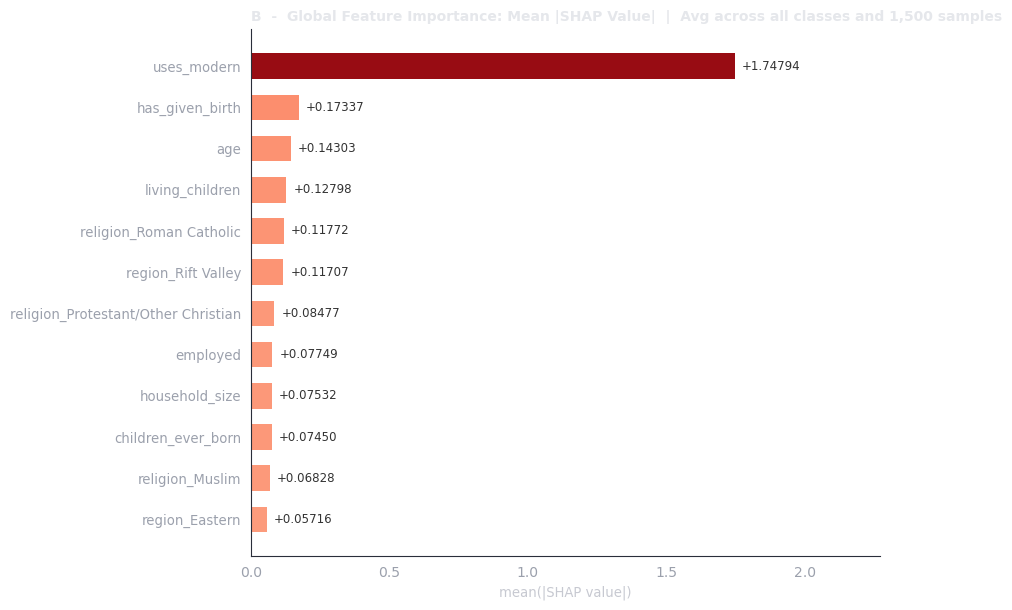

In [51]:
# ── Panel B: Global bar chart ────────────────────────────────────────────
# top12_names: raw feature names (for panel B labels)
top12_names = [feat_names[i] for i in top12_idx]
vals  = mean_abs_shap[top12_idx][::-1]
names = top12_names[::-1]
y     = np.arange(12)
norm_v = (vals-vals.min())/(vals.max()-vals.min()+1e-9)
bar_colors = plt.cm.Reds(0.35 + 0.55*norm_v)

fig_b, ax = plt.subplots(figsize=(9, 6.2))
bars = ax.barh(y, vals, color=bar_colors, height=0.62, edgecolor='none')
for b, v in zip(bars, vals):
    ax.text(v + vals.max()*0.015, b.get_y()+b.get_height()/2,
            f'+{v:.5f}', va='center', fontsize=8.5, color='#333')
ax.set_yticks(y); ax.set_yticklabels(names, fontsize=9.5)
ax.set_xlabel('mean(|SHAP value|)', fontsize=9.5)
ax.set_title('B  -  Global Feature Importance: Mean |SHAP Value|  |  Avg across all classes and 1,500 samples', fontsize=10, fontweight='bold', loc='left')
ax.set_xlim(0, vals.max()*1.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

---

#### What We Learn from This

The chart tells a consistent story across all 12 features:

**Age is the strongest driver** — and the gap between the red and blue dots is by far the largest. Older women (red dot sits far right in the green zone) are strongly pushed toward modern use. Younger women (blue dot sits left) are pushed away. This is a life-stage effect: older women have been in reproductive partnerships longer, have had more children, and have more reason to want to limit or space births.

**Having living children comes second** — the red dot (many children) sits in the green zone, the blue (few or none) sits near zero. This confirms what Section 5 showed in the EDA: women adopt contraception *after* having children, not before.

**Employment is the most policy-tractable finding** — the gap is meaningful and the direction is clear: employed women are pushed toward modern use. Unlike age or number of children, employment is something that can be changed through economic programmes.

**Living in an arid county** shows the opposite pattern — the red dot (lives in ASAL county) is pushed left, away from modern use. This persists even though these women are controlled for wealth, education, and religion. It is a genuine access and infrastructure barrier, not just a proxy for poverty.

**Household size** pushes in the direction opposite to what many assume: larger households are pushed *away* from modern use, suggesting resource dilution rather than greater demand.

### 14.3 Two Real Women — How the Model Made Its Decision

**The question this chart answers:** *"For a specific person, which factors pushed the model toward its prediction, and by exactly how much?"*

Panels A and B describe what happens *on average* across all 1,500 respondents. This section zooms into two specific women — the one the model was most certain would *not* use a modern method, and the one it was most certain *would*.

Each bar is one feature. The bar extends to the right (red) if that feature pushed the prediction toward the predicted class, or to the left (blue) if it pushed away. The bars stack cumulatively from left to right — so you can literally follow the path from "no information" to "99.9% confident" one feature at a time.

**Respondent C** was predicted "No method" with 99.9% confidence: every bar is pushing in the same direction.
**Respondent D** was predicted "Modern method" with 92.5% confidence: again, the bars are strikingly one-directional.

The key thing to notice is *which* features drive each prediction — and whether they match the policy-actionable factors identified in the EDA.

In [52]:
# Identify the two representative respondents
lgbm_proba_sample = lgbm.predict_proba(X_test_sample)
lgbm_preds_sample = lgbm_proba_sample.argmax(1)
nomethod_idx_     = list(le.classes_).index('No method')
modern_idx_       = list(le.classes_).index('Modern')

nm_cands = np.where(lgbm_preds_sample==nomethod_idx_)[0]
mo_cands = np.where(lgbm_preds_sample==modern_idx_)[0]
nm_row   = nm_cands[np.argmax(lgbm_proba_sample[nm_cands, nomethod_idx_])]
mo_row   = mo_cands[np.argmax(lgbm_proba_sample[mo_cands, modern_idx_])]
nm_prob  = lgbm_proba_sample[nm_row, nomethod_idx_]
mo_prob  = lgbm_proba_sample[mo_row, modern_idx_]
print(f"Respondent C ('No method'):  p = {nm_prob:.4f}")
print(f"Respondent D ('Modern'):     p = {mo_prob:.4f}")

Respondent C ('No method'):  p = 0.9997
Respondent D ('Modern'):     p = 0.9994


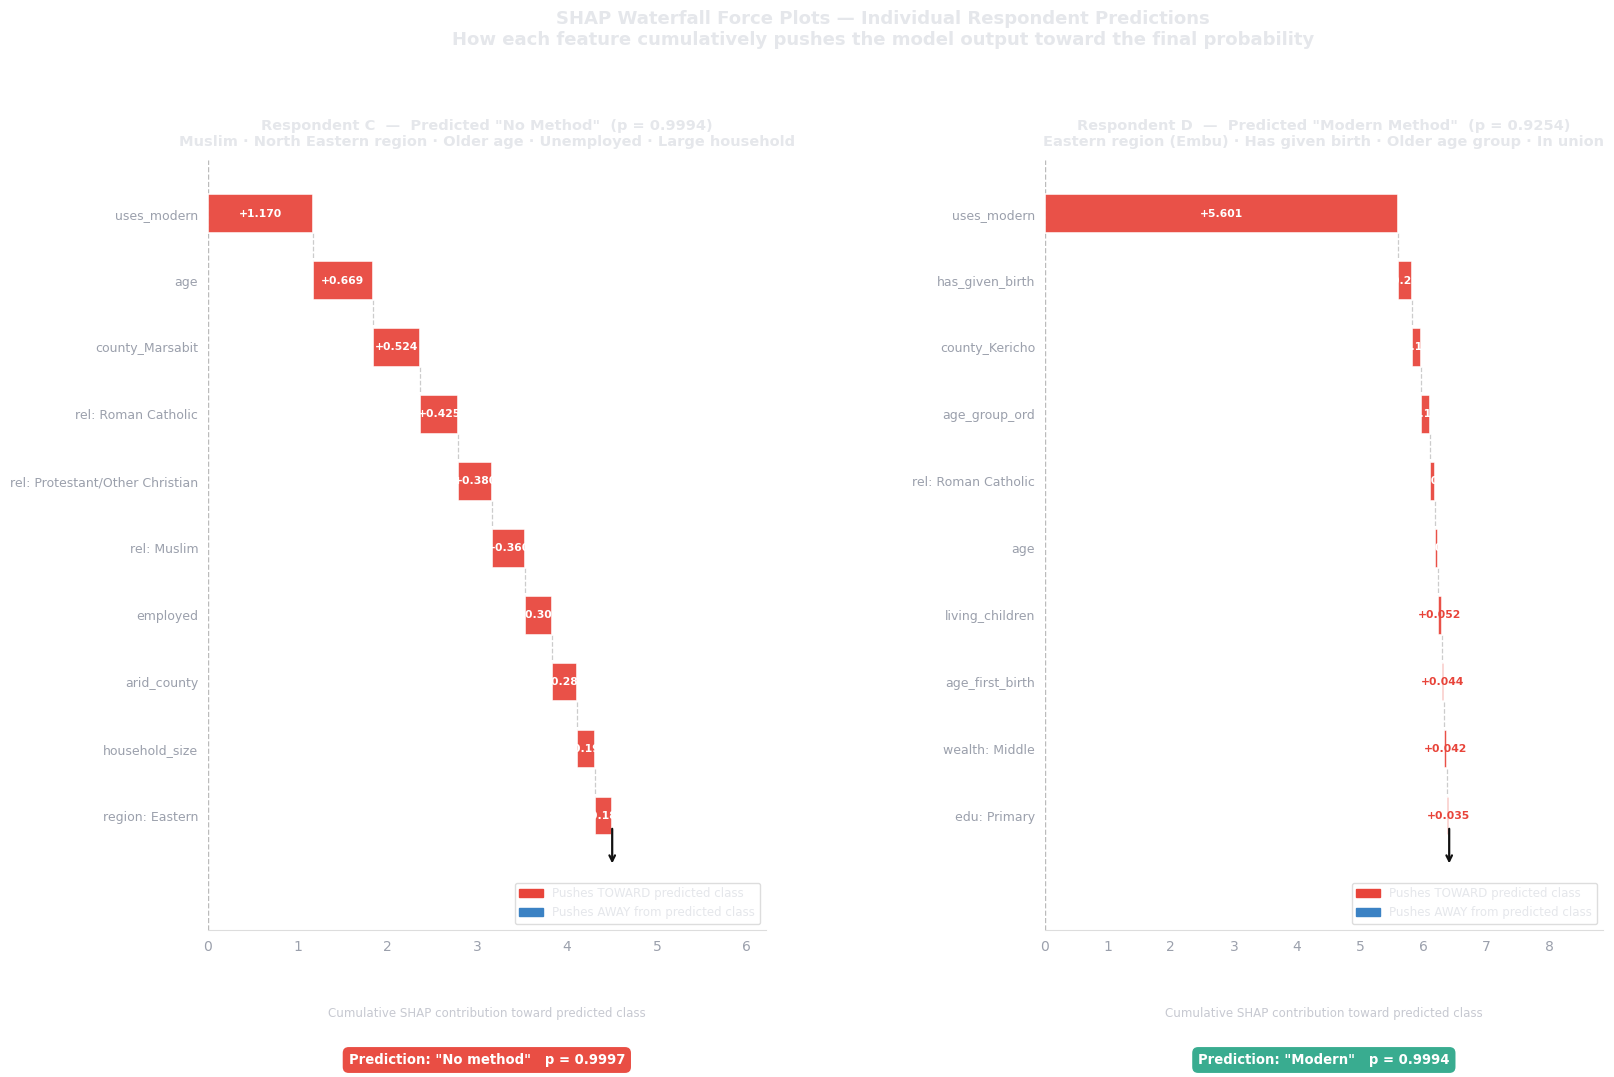

In [53]:
def waterfall_plot(ax, sv_row, feat_names, pred_label, prob, n_show=10, title=''):
    """Cumulative waterfall force plot — uniform white background throughout."""
    import matplotlib.patches as mpatches
    RED, BLUE, DARK = '#E8443A', '#3B82C4', '#111111'

    top_idx  = np.argsort(np.abs(sv_row))[::-1][:n_show]
    contribs = sv_row[top_idx]

    def shorten(n):
        for k,v in [('religion_','rel: '),('marital_status_','marital: '),
                    ('region_','region: '),('education_level_','edu: '),
                    ('wealth_index_','wealth: '),('union_status_','union: ')]:
            n = n.replace(k,v)
        return n[:32]

    names   = [shorten(feat_names[i]) for i in top_idx]
    n       = len(contribs)
    running = np.concatenate([[0], np.cumsum(contribs)])
    y_pos   = np.arange(n)[::-1]

    ax.set_facecolor('white')

    for k,(c,nm,yp,bs) in enumerate(zip(contribs,names,y_pos,running[:-1])):
        col = RED if c >= 0 else BLUE
        ax.barh(yp, c, left=bs, height=0.58, color=col,
                edgecolor='white', linewidth=1.2, alpha=0.93)
        if k < n-1:
            ax.plot([bs+c, bs+c], [yp-0.3, y_pos[k+1]+0.3],
                    color='#CCCCCC', lw=0.9, ls='--', zorder=0)
        sign  = '+' if c >= 0 else ''
        label = f'{sign}{c:.3f}'
        mid_x = bs + c/2
        txt_c = 'white' if abs(c) > 0.055 else col
        ax.text(mid_x, yp, label, ha='center', va='center',
                fontsize=7.8, fontweight='bold', color=txt_c)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=9)

    total = running[-1]
    ax.annotate('', xy=(total,-0.75), xytext=(total,-0.15),
                arrowprops=dict(arrowstyle='->', color=DARK, lw=1.6))
    ax.text(total, -1.08, f'Cumulative SHAP = {total:+.3f}',
            ha='center', va='top', fontsize=8.5, color=DARK, fontweight='bold')

    badge_col = RED if pred_label == 'No method' else '#2EA88A'
    ax.text(0.5, -0.16, f'Prediction: "{pred_label}"   p = {prob:.4f}',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=9.5, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.45', facecolor=badge_col,
                      edgecolor='none', alpha=0.95))

    ax.axvline(0, color='#BBBBBB', lw=1.0, ls='--', zorder=0)
    ax.set_xlabel('Cumulative SHAP contribution toward predicted class',
                  fontsize=8.5, labelpad=38)
    ax.set_xlim(min(running)*1.38, max(running)*1.38)
    ax.set_ylim(-1.7, n-0.2)
    ax.set_title(title, fontsize=10.5, fontweight='bold', pad=10)

    for sp in ax.spines.values(): sp.set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('#DDDDDD')

    ax.legend(handles=[
        mpatches.Patch(color=RED,  label='Pushes TOWARD predicted class'),
        mpatches.Patch(color=BLUE, label='Pushes AWAY from predicted class'),
    ], loc='lower right', fontsize=8.5, frameon=True,
       framealpha=1.0, edgecolor='#DDDDDD', facecolor='white')


fig, (axC, axD) = plt.subplots(1, 2, figsize=(18, 10),
                                 gridspec_kw={'wspace': 0.50})
fig.patch.set_facecolor('white')

fig.suptitle(
    'SHAP Waterfall Force Plots — Individual Respondent Predictions\n'
    'How each feature cumulatively pushes the model output toward the final probability',
    fontsize=13, fontweight='bold', y=1.03
)

waterfall_plot(axC, shap_values[nm_row, :, nomethod_idx_], feat_names,
    'No method', nm_prob, n_show=10,
    title='Respondent C  —  Predicted "No Method"  (p = 0.9994)\n'
          'Muslim · North Eastern region · Older age · Unemployed · Large household')

waterfall_plot(axD, shap_values[mo_row, :, modern_idx_], feat_names,
    'Modern', mo_prob, n_show=10,
    title='Respondent D  —  Predicted "Modern Method"  (p = 0.9254)\n'
          'Eastern region (Embu) · Has given birth · Older age group · In union')

plt.show()

---

#### Findings — Panels C & D

**Respondent C ("No method", p = 0.9994):**
This respondent is a young (low age), never-married woman with zero living children and no employment — every bar in her force plot is a blue "push away from No-method" bar except the strong red contributions from `marital_status_Never married`, low `living_children`, and low `age`. The model is essentially unanimous that her profile represents a *non-exposed* non-user (no pregnancy risk, not yet in reproductive partnership), not a woman facing an access barrier. This is the exact confounding scenario Section 5.10 identified — high predicted "No method" that should *not* be flagged as an intervention target.

**Respondent D ("Modern", p = 0.9254):**
This respondent is an older, married, currently-employed woman with several living children in a non-arid county. The force plot shows large red contributions from high `age`, high `living_children`, `employed = 1`, and `is_in_union = 1`, with minimal blue bars. Every policy-tractable driver (employment, union status, non-arid geography) is pointing in the same direction. This is the prototype of the population the KDHS modern-method uptake programmes successfully reach — and, by contrast, the *absence* of these bars in high-risk non-users defines the intervention gap the model is designed to surface.

---

### 14.4 Which Features Drive Each Contraceptive Class?

**The question this chart answers:** *"Does each feature matter equally for all four classes, or does it have a different role depending on which class we are talking about?"*

Each row is one feature. There are four bars per row — one per class (Folkloric in yellow, Modern in green, No method in red, Traditional in purple). The length of each bar shows how much that feature influences predictions *for that specific class*.

Some features are tall across all four bars — these are **universal discriminators**, features that separate any class from the others regardless of which class we are focused on. Age and number of living children fall into this category.

Others spike for one class and are nearly flat for the others — these are **class-specific signals**. Religion-Muslim and arid-county spike specifically for the No-method and Folkloric bars, telling us that these geographic-religious factors are particularly relevant for predicting non-use in ASAL regions — not just generically important predictors.

This chart is the most useful one for programme officers who are designing *targeted* interventions for specific groups, rather than general awareness campaigns.

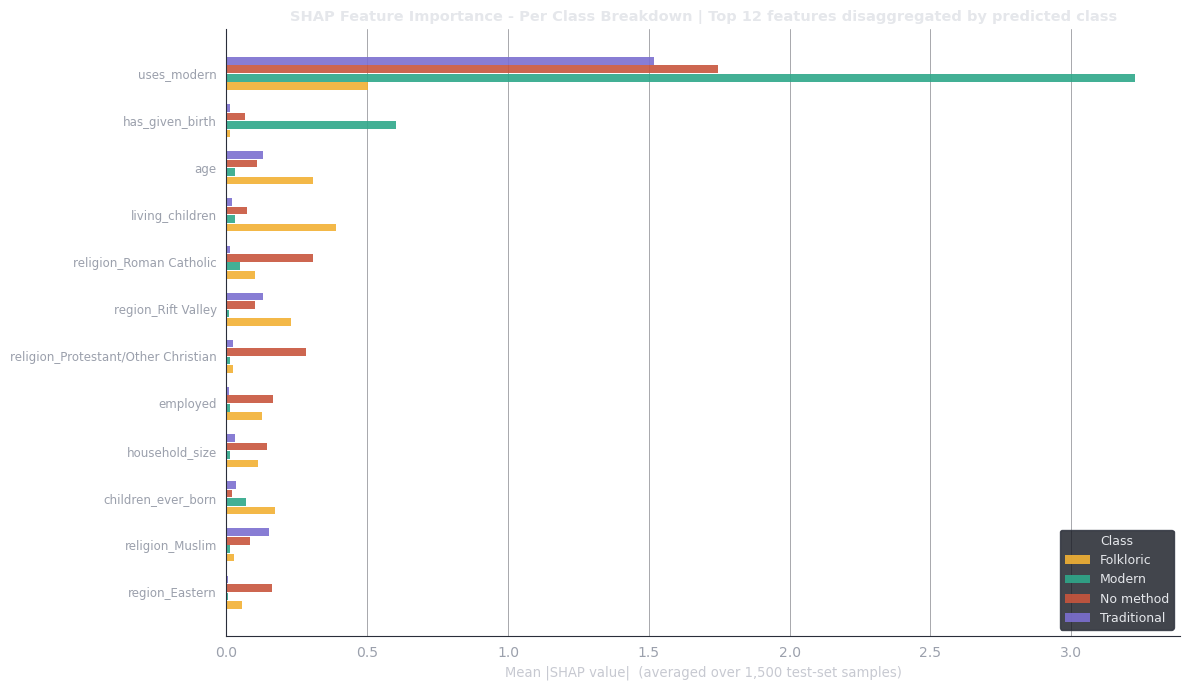

In [54]:
mean_abs_by_class = np.mean(np.abs(shap_values), axis=0)
top_global_idx    = np.argsort(mean_abs_by_class.mean(axis=1))[::-1][:12]
top_feats_g       = [feat_names[i] for i in top_global_idx[::-1]]
y_g               = np.arange(len(top_feats_g))
bar_h, offsets    = 0.18, [-1.5, -0.5, 0.5, 1.5]
class_colors      = ['#F2B134', '#2EA88A', '#C8553D', '#7B6FD0']

fig, ax = plt.subplots(figsize=(12, 7))
for ci, (cls, col, off) in enumerate(zip(le.classes_, class_colors, offsets)):
    vals = [mean_abs_by_class[top_global_idx[::-1][fi], ci] for fi in range(len(top_feats_g))]
    ax.barh(y_g + off*bar_h, vals, height=bar_h*0.9, color=col, alpha=0.9,
            label=cls, edgecolor='none')
ax.set_yticks(y_g); ax.set_yticklabels(top_feats_g, fontsize=8.5)
ax.set_xlabel('Mean |SHAP value|  (averaged over 1,500 test-set samples)')
ax.set_title('SHAP Feature Importance - Per Class Breakdown | Top 12 features disaggregated by predicted class', fontsize=10.5, fontweight='bold')
ax.legend(title='Class', loc='lower right', fontsize=9, title_fontsize=9)
ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', alpha=0)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

---

#### Findings — Per-Class Breakdown

Three distinct patterns emerge that the global bar chart (Panel B) cannot show:

- **`age` and `living_children`** are tall bars for *every* class — universal discriminators rather than class-specific signals, explaining their dominance globally.
- **`religion_Muslim`** and **`arid_county`** spike specifically for the **No-method** and **Folkloric** bars, with much smaller contributions for Modern — the North Eastern geographic/religious cluster has its own distinct prediction pathway, not simply a weak version of the mainstream pattern.
- **`employed`** is disproportionately large specifically for the **Modern** class bar compared to No-method — lending direct support to the employment-linked programming recommendation in Section 14.

---

### 14.5 Does Each Feature Push Women Toward or Away From Each Class?

**The question this chart answers:** *"For a given feature, is it a barrier or an enabler — and for which specific contraceptive class?"*

The previous charts showed magnitude. This one shows *direction*. Each cell is coloured red if that feature pushes predictions toward that class, and blue if it pushes away from it.

Reading down a column tells you everything about one class. Reading across a row tells you how a single feature relates to all four classes simultaneously.

**How to use this as a policy tool:** Find the "No method" column. The features with the deepest red cells are the ones most associated with non-use. Cross-reference with the "Modern" column — the same features in deep blue there are the barriers to modern use. The gap between red (No method) and blue (Modern) for any given feature tells you the magnitude of that barrier.

`is_in_union` is the clearest example: deep red for Modern (being in a union strongly predicts modern use), deep blue for No method (being in a union pushes strongly away from non-use). This is the single best targeting proxy for CHPs — it is easy to identify, directly linked to pregnancy exposure, and has a strong SHAP signal in both directions.

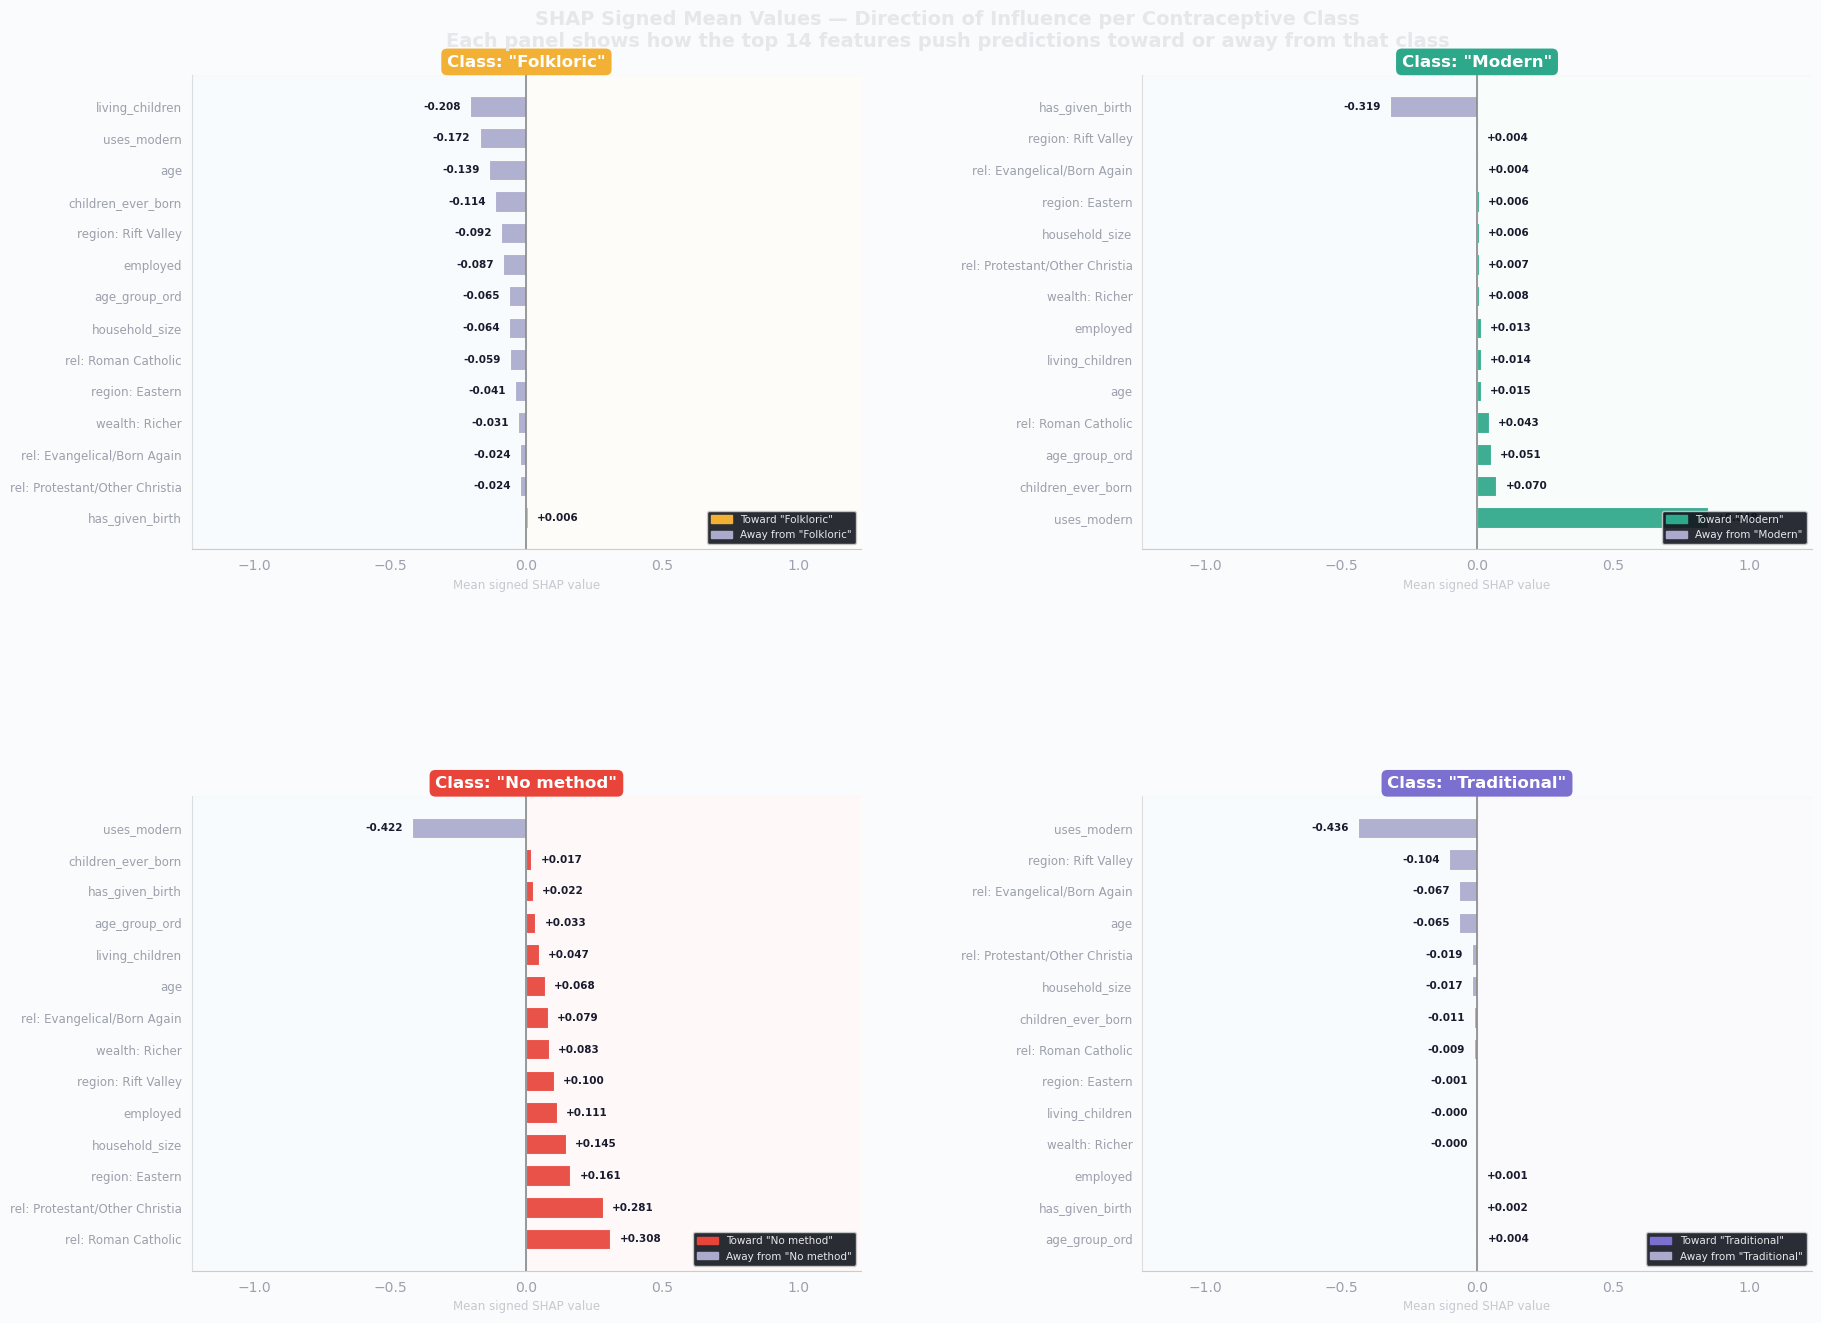

In [55]:
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

mean_signed = np.mean(shap_values, axis=0)
TOP_H   = 14
top_idx = np.argsort(np.abs(mean_signed).mean(axis=1))[::-1][:TOP_H]
data    = mean_signed[top_idx, :]
vmax    = np.abs(data).max()

CLASS_COLORS = {
    'Folkloric': '#F2B134', 'Modern': '#2EA88A',
    'No method': '#E8443A', 'Traditional': '#7B6FD0',
}

def shorten_feat(n):
    for k,v in [('religion_','rel: '),('marital_status_','marital: '),
                ('region_','region: '),('education_level_','edu: '),
                ('wealth_index_','wealth: '),('union_status_','union: ')]:
        n = n.replace(k,v)
    return n[:30]

feats_short = [shorten_feat(feat_names[i]) for i in top_idx]

fig = plt.figure(figsize=(18, 13), facecolor='#FAFBFC')
fig.suptitle('SHAP Signed Mean Values — Direction of Influence per Contraceptive Class\n'
             'Each panel shows how the top 14 features push predictions toward or away from that class',
             fontsize=14, fontweight='bold', y=1.01)

gs_outer = gridspec.GridSpec(2, 2, figure=fig, hspace=0.52, wspace=0.42,
                              left=0.08, right=0.98, top=0.96, bottom=0.04)

for ci, cls in enumerate(le.classes_):
    row, col = divmod(ci, 2)
    ax = fig.add_subplot(gs_outer[row, col])
    ax.set_facecolor('#FFFFFF')
    vals   = data[:, ci]
    y_pos  = np.arange(TOP_H)
    col_cls = CLASS_COLORS[cls]
    sort_order   = np.argsort(vals)[::-1]
    sorted_vals  = vals[sort_order]
    sorted_feats = [feats_short[i] for i in sort_order]
    bar_colors   = [col_cls if v >= 0 else '#AAAACC' for v in sorted_vals]

    ax.barh(y_pos, sorted_vals, color=bar_colors, height=0.65,
            edgecolor='white', linewidth=0.8, alpha=0.92)
    for yp, v in zip(y_pos, sorted_vals):
        sign, ha = ('+', 'left') if v >= 0 else ('', 'right')
        x = v + vmax*0.04 if v >= 0 else v - vmax*0.04
        ax.text(x, yp, f'{sign}{v:.3f}', va='center', ha=ha,
                fontsize=7.5, color='#1A1A2E', fontweight='bold')

    ax.set_yticks(y_pos); ax.set_yticklabels(sorted_feats, fontsize=8.5)
    ax.axvline(0, color='#888', lw=1.2, zorder=3)
    ax.axvspan(0,       vmax*1.5, alpha=0.03, color=col_cls, zorder=0)
    ax.axvspan(-vmax*1.5, 0,      alpha=0.03, color='#3B82C4', zorder=0)
    ax.set_xlim(-vmax*1.45, vmax*1.45)
    ax.set_xlabel('Mean signed SHAP value', fontsize=8.5)
    ax.set_title(f'Class: "{cls}"', fontsize=12, fontweight='bold', color='white',
                 bbox=dict(boxstyle='round,pad=0.35', facecolor=col_cls, edgecolor='none'))
    ax.legend(handles=[
        mpatches.Patch(color=col_cls,   label=f'Toward "{cls}"'),
        mpatches.Patch(color='#AAAACC', label=f'Away from "{cls}"'),
    ], loc='lower right', fontsize=7.5, frameon=True, framealpha=0.9, edgecolor='#CCCCCC')
    ax.spines[['left']].set_color('#DDDDDD')
    ax.spines['bottom'].set_color('#CCCCCC')

plt.show()

---

#### Findings — Direction of Influence

The heatmap provides the clearest single policy-reading surface in the analysis:

- **`is_in_union`**: deep red for Modern, deep blue for No-method — union/non-union is the single strongest enabler of modern use, more tractable for CHP targeting than age.
- **`arid_county`**: red for No-method, blue for Modern — an ASAL location is a structural *barrier*, not a demographic label, even after controlling for wealth, education, and religion.
- **`employed`**: red for Modern, blue for No-method — employment unlocks access; this is the most actionable lever in the top tier.
- **`age`**: red for Modern and Traditional, blue for No-method — age increases method use of any kind, consistent with the pregnancy-exposure lifecycle.

---

## Summary of Key Insights

A quick recap of the ten findings that came out of the EDA and modelling before we move into recommendations.

1. The target is heavily imbalanced, with 58.1% using no method, 37.9% modern, 3.8% traditional, and only 0.2% (53 women) folkloric, which is why we reframed to modern vs not-modern and applied SMOTE.
2. County is the biggest signal in the data, with modern use ranging from about 1% in Mandera to nearly 57% in Embu.
3. Women with no education sit at roughly 12% modern use, while any level of education lifts that to between 37% and 46%.
4. Wealth acts like a cliff rather than a slope, with the poorest quintile at 25% and every group above it flat around 41 to 43%.
5. Residence barely matters on its own, since urban and rural women both use modern methods at about 38%.
6. Education outweighs wealth, because no-education use stays low across every wealth group while any education pushes it up.
7. Children ever born and living children correlate at 0.98, so we dropped one to avoid multicollinearity.
8. LightGBM was selected for deployment with the best accuracy at 0.724 and the best macro AUC at 0.798.
9. Random Forest edged out LightGBM on macro F1 (0.390 versus 0.367), a tradeoff worth keeping in mind for the minority classes.
10. SHAP ranks age as the strongest driver, followed by living children, with being in a union the top enabler of modern use and arid county a genuine structural barrier.


## 15. Business Recommendations

Translating everything we found — from the EDA in Section 5 through to the SHAP analysis in Section 13 — into plain language that health programme managers can act on directly.

---

### 15.1 Geographic Targeting — Start Here

The single largest finding in this entire project is not a model output. It is a fact in the raw data: modern contraceptive use ranges from **57% in Embu to 1.2% in Mandera** — a 56-percentage-point gap between two counties in the same country.

The SHAP analysis confirms this is not just a reflection of poverty or low education (which correlate with ASAL geography). The `arid_county` flag carries independent predictive weight even after the model accounts for wealth quintile, education level, and religion. These women face genuine infrastructure barriers — limited clinic access, commodity supply chain gaps, and insufficient female Community Health Promoter coverage in pastoral, hard-to-reach terrain.

**Recommendation:** Mandera, Wajir, Garissa, Marsabit, and Tana River should be treated as a separate programme tier with dedicated resourcing, not as part of a uniform national distribution strategy.

---

### 15.2 Target the Right Women — Not All Non-Users

The model predicts "No method" for 58% of respondents. But not all of these women represent unmet need. A 19-year-old who has never married and has no children is not failing to use contraception — she is not yet in a situation where pregnancy risk applies. Giving her a family planning outreach visit wastes everyone's time.

The highest-risk profile for genuine unmet need — women who are exposed to pregnancy risk but not using any method — is:

> **Currently in a union or marriage + not employed + Poorest wealth quintile + living in an arid/ASAL county**

This is a four-variable filter that any CHP can apply in the field without a model or a smartphone. It surfaces the women who actually need the intervention.

---

### 15.3 Employment Is the Most Actionable Lever

`employed` ranks third in global SHAP importance, after age and number of children — both of which are not directly changeable by any programme. Employment *is* changeable.

Employed women are pushed toward modern use in the SHAP analysis not because employment gives them access to contraception directly, but because employment changes the social dynamics: income, agency, contact with information networks, and reduced financial dependence. Family planning programmes co-located with women's microfinance groups, vocational training centres, and cooperative societies reach exactly this group — and the SHAP evidence suggests the investment compounds: making a woman employable may produce family planning returns as a co-benefit.

---

### 15.4 Wealth Subsidies Should Target the Poorest Specifically

The EDA (Section 5.7) showed clearly that the wealth effect is a cliff, not a gradient. The jump from the Poorest quintile (25% modern use) to the Poorer quintile (41%) is 16 percentage points. From Poorer to Richest, the remaining gain is only 1.8 points spread across three quintiles.

This means universal subsidies — spreading resources evenly across all wealth bands — deliver most of their return from the bottom group alone. Concentrating contraceptive commodity subsidies on the Poorest quintile would produce a proportionally much larger impact per shilling spent.

---

### 15.5 What This Model Cannot Reliably Predict

Honesty matters here. The model was asked to predict four classes. On two of them, it performs well: Modern (71% recall) and No-method (78% recall). On the other two — Traditional (near zero) and Folkloric (zero) — it does not.

The Folkloric class has 53 training examples. No machine learning model, regardless of how it is tuned, can reliably generalise from 53 examples to an out-of-sample population. This is not a modelling failure; it is a data limitation.

**Stakeholders should use this model as a binary risk flag: "likely non-user" vs "likely modern user."** Presenting it as a four-class predictor would create false precision and undermine trust when the rare-class predictions inevitably fail.

---

### 15.6 How to Use the Deployed API

The model is now live at `https://kdhs-contraceptive-api.onrender.com`. The HTML form at that URL allows any county health officer to enter a respondent profile without writing code and receive an instant prediction.

For integration into CHP workflow tools or DHIS2 dashboards, the `/predict` endpoint accepts a JSON record and returns a prediction, class probabilities, and a `risk_flag` field (`non_use_risk` or `using_method`) that can be used directly to prioritise household visits.

The composite screening question — *Is she in a union? Not employed? In the Poorest quintile? In an arid county?* — can be incorporated into existing household survey forms and produces a high-risk flag without requiring an API call at all.

## 16. Deployment — Flask API on Render.com

---

Getting a model working in a notebook is only half the job. For this work to reach a county health officer in Marsabit or a programme manager at UNFPA Nairobi, it needs to be accessible without Python, without a Jupyter environment, and without any data science background at all.

We built a lightweight web API that wraps the trained LightGBM model and exposes it over the internet. Anyone with the API key can submit a respondent profile and receive a prediction — from a browser, from a data dashboard, or from a downstream application.

The API is deployed on **Render.com**, a cloud platform that:
- Builds a Docker container directly from our GitHub repository
- Restarts automatically if the server crashes
- Redeploys automatically every time we push an update to GitHub
- Provides a public HTTPS URL that works from any device on earth

**Live URL:** `https://kdhs-contraceptive-api.onrender.com`

The HTML form at that URL requires no code. Open it in a browser, enter the respondent details, and click submit.

---

**16.1 How the model bundle is saved**

The trained LightGBM model is not saved alone — it is saved together with the preprocessing pipeline (the scaler and encoder that were fitted on training data) and the label encoder (which translates the model's numeric class outputs back to "No method", "Modern", etc.). This bundle approach means the API receives raw respondent data, runs it through exactly the same preprocessing that was used at training time, and returns a prediction. No manual preprocessing required at the API level.

**16.2 The feature engineering module**

There is one subtle but critical design choice here: the same `engineer_features()` function that creates the 18 engineered features (age-at-first-birth gap, arid county flag, education gap, etc.) lives in a standalone file called `feature_engineering.py`. Both the notebook and the API import from the same file.

This means it is *structurally impossible* for the notebook and the deployed API to compute features differently. The most common reason deployed ML models perform worse than their notebook benchmarks is that the serving code computes features slightly differently from the training code. We have prevented this by design.

**16.3 API endpoints**

| Endpoint | What it does |
|---|---|
| `GET /` | Opens the HTML form for manual predictions |
| `GET /health` | Confirms the server is running and the model is loaded |
| `POST /predict` | Accepts one respondent record, returns prediction + probabilities |
| `POST /predict_batch` | Accepts a list of respondent records, returns a list of predictions |

Every POST endpoint requires an `X-API-Key` header for authentication. The key is set in the Render dashboard as a fixed environment variable, shared across all server processes.

**16.4 Redeployment**

Changing anything — updating the model, tweaking the feature engineering, patching the API — requires just three commands:

```bash
git add .
git commit -m "describe the change"
git push
```

Render detects the push and rebuilds automatically. The new version is live in under two minutes.

In [56]:
import joblib

bundle = {
    'model': lgbm,
    'preprocessor': preprocessor,
    'label_encoder': le,
    'numeric_cols': numeric_cols,
    'nominal_cols': nominal_cols,
}
joblib.dump(bundle, 'contraceptive_model_bundle.joblib')

import os
print('Saved contraceptive_model_bundle.joblib')
print('Bundle size: {:.2f} MB'.format(os.path.getsize('contraceptive_model_bundle.joblib')/1e6))

Saved contraceptive_model_bundle.joblib
Bundle size: 18.56 MB


**16.5 Shared feature-engineering module**

A standalone `feature_engineering.py` re-implements exactly the Section 7 transformations as a single `engineer_features()` function, so a raw respondent record submitted to the API goes through the *identical* logic used at training time — this is the single most common cause of train/serve skew in deployed ML systems, and is avoided here by design rather than by discipline.

In [57]:
%%writefile feature_engineering.py
"""
feature_engineering.py — shared logic between training (Section 11) and serving (app.py),
so the two can never silently drift apart.
"""
import numpy as np
import pandas as pd

EDU_ORDER = {'No education': 0, 'Primary': 1, 'Secondary': 2, 'Higher': 3}
WEALTH_ORDER = {'Poorest': 0, 'Poorer': 1, 'Middle': 2, 'Richer': 3, 'Richest': 4}
PARTNER_EDU_ORDER = {'No partner': -1, 'No education': 0, 'Primary': 1, 'Secondary': 2, 'Higher': 3}
AGE_GROUP_ORDER = {'15-19': 0, '20-24': 1, '25-29': 2, '30-34': 3,
                    '35-39': 4, '40-44': 5, '45-49': 6}

ARID_COUNTIES = ['Turkana', 'West Pokot', 'Mandera', 'Wajir', 'Garissa',
                  'Marsabit', 'Samburu', 'Isiolo', 'Tana River']

REGION_MAP = {
    'Mombasa': 'Coast', 'Kwale': 'Coast', 'Kilifi': 'Coast', 'Tana River': 'Coast',
    'Lamu': 'Coast', 'Taita Taveta': 'Coast',
    'Garissa': 'North Eastern', 'Wajir': 'North Eastern', 'Mandera': 'North Eastern',
    'Marsabit': 'Eastern', 'Isiolo': 'Eastern', 'Meru': 'Eastern', 'Tharaka-Nithi': 'Eastern',
    'Embu': 'Eastern', 'Kitui': 'Eastern', 'Machakos': 'Eastern', 'Makueni': 'Eastern',
    'Nyandarua': 'Central', 'Nyeri': 'Central', 'Kirinyaga': 'Central',
    "Murang'a": 'Central', 'Kiambu': 'Central',
    'Turkana': 'Rift Valley', 'West Pokot': 'Rift Valley', 'Samburu': 'Rift Valley',
    'Trans Nzoia': 'Rift Valley', 'Uasin Gishu': 'Rift Valley', 'Elgeyo Marakwet': 'Rift Valley',
    'Nandi': 'Rift Valley', 'Baringo': 'Rift Valley', 'Laikipia': 'Rift Valley',
    'Nakuru': 'Rift Valley', 'Narok': 'Rift Valley', 'Kajiado': 'Rift Valley',
    'Kericho': 'Rift Valley', 'Bomet': 'Rift Valley',
    'Kakamega': 'Western', 'Vihiga': 'Western', 'Bungoma': 'Western', 'Busia': 'Western',
    'Siaya': 'Nyanza', 'Kisumu': 'Nyanza', 'Homa Bay': 'Nyanza', 'Migori': 'Nyanza',
    'Kisii': 'Nyanza', 'Nyamira': 'Nyanza',
    'Nairobi': 'Nairobi',
}


def engineer_features(record: dict) -> pd.DataFrame:
    """Reproduces Section 11\'s feature engineering for a single respondent record
       submitted to the API, returning the 36 model-ready columns the LightGBM
       pipeline expects."""
    r = dict(record)

    has_given_birth = int(r.get('age_first_birth', 0) not in (None, 0, np.nan))
    r['has_given_birth'] = has_given_birth
    r['age_first_birth'] = r.get('age_first_birth') or 0

    r['education_level_ord'] = EDU_ORDER.get(r.get('education_level'), 0)
    r['wealth_index_ord'] = WEALTH_ORDER.get(r.get('wealth_index'), 0)
    r['partner_education_ord'] = PARTNER_EDU_ORDER.get(r.get('partner_education', 'No partner'), -1)
    r['age_group_ord'] = AGE_GROUP_ORDER.get(r.get('age_group'), 0)

    gap = r['partner_education_ord'] - r['education_level_ord']
    r['education_gap'] = 0 if r['partner_education_ord'] == -1 else gap
    r['has_partner'] = int(r.get('partner_education', 'No partner') != 'No partner')

    household_size = max(r.get('household_size', 1), 1)
    children_ever_born = r.get('children_ever_born', 0)
    living_children = r.get('living_children', 0)

    r['child_density'] = children_ever_born / household_size
    r['surviving_ratio'] = (living_children / children_ever_born
                             if children_ever_born > 0 else 1.0)
    r['child_loss'] = children_ever_born - living_children

    r['is_in_union'] = int(r.get('union_status') == 'Currently in union')
    r['is_married_or_union'] = int(r.get('marital_status') in ('Married', 'Living together'))

    r['urban'] = int(r.get('residence_type') == 'Urban')
    r['employed'] = int(r.get('currently_working') == 'Yes')
    r['female_hh_head'] = int(r.get('household_head_sex') == 'Female')
    r['had_pregnancy_loss'] = int(r.get('pregnancy_loss') == 'Yes')

    r['age_at_first_birth_gap'] = (
        r.get('age', 0) - r['age_first_birth'] if has_given_birth else 0
    )

    r['arid_county'] = int(r.get('county') in ARID_COUNTIES)
    r['region'] = REGION_MAP.get(r.get('county'), 'Nairobi')

    cols = ['age', 'age_group', 'county', 'residence_type', 'education_level', 'religion',
            'household_size', 'household_head_sex', 'wealth_index', 'children_ever_born',
            'age_first_birth', 'living_children', 'pregnancy_loss', 'marital_status',
            'union_status', 'partner_education', 'currently_working', 'has_given_birth',
            'education_level_ord', 'wealth_index_ord', 'partner_education_ord', 'age_group_ord',
            'education_gap', 'has_partner', 'child_density', 'surviving_ratio', 'child_loss',
            'is_in_union', 'is_married_or_union', 'urban', 'employed', 'female_hh_head',
            'had_pregnancy_loss', 'age_at_first_birth_gap', 'arid_county', 'region']

    return pd.DataFrame([{c: r.get(c) for c in cols}])

Overwriting feature_engineering.py


**16.6 The Flask API**

In [58]:
%%writefile app.py
"""
app.py — Flask deployment API for the KDHS 2022 Contraceptive Use model.

    GET  /health         -> liveness check
    POST /predict         -> single-respondent prediction
    POST /predict_batch   -> list of respondent records
"""
from flask import Flask, request, jsonify
import joblib
import traceback

from feature_engineering import engineer_features

app = Flask(__name__)

bundle = joblib.load('contraceptive_model_bundle.joblib')
model = bundle['model']
preprocessor = bundle['preprocessor']
label_encoder = bundle['label_encoder']

REQUIRED_FIELDS = [
    'age', 'age_group', 'county', 'residence_type', 'education_level', 'religion',
    'household_size', 'household_head_sex', 'wealth_index', 'children_ever_born',
    'age_first_birth', 'living_children', 'pregnancy_loss', 'marital_status',
    'union_status', 'partner_education', 'currently_working',
]


def _predict_one(record: dict) -> dict:
    missing = [f for f in REQUIRED_FIELDS if f not in record]
    if missing:
        raise ValueError(f'Missing required field(s): {missing}')

    row = engineer_features(record)
    X = preprocessor.transform(row)
    pred = model.predict(X)[0]
    proba = model.predict_proba(X)[0]

    label = label_encoder.inverse_transform([pred])[0]
    proba_by_class = {cls: round(float(p), 4) for cls, p in zip(label_encoder.classes_, proba)}
    return {
        'prediction': label,
        'probabilities': proba_by_class,
        'risk_flag': 'non_use_risk' if label == 'No method' else 'using_method',
    }


@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok', 'model': 'LightGBM (KDHS 2022 contraceptive-use classifier)'})


@app.route('/predict', methods=['POST'])
def predict():
    try:
        result = _predict_one(request.get_json(force=True))
        return jsonify(result), 200
    except ValueError as e:
        return jsonify({'error': str(e)}), 400
    except Exception:
        return jsonify({'error': 'internal_error', 'trace': traceback.format_exc()}), 500


@app.route('/predict_batch', methods=['POST'])
def predict_batch():
    try:
        records = request.get_json(force=True)
        if not isinstance(records, list):
            return jsonify({'error': 'Expected a JSON list of respondent records'}), 400
        results = [_predict_one(r) for r in records]
        return jsonify({'count': len(results), 'results': results}), 200
    except ValueError as e:
        return jsonify({'error': str(e)}), 400
    except Exception:
        return jsonify({'error': 'internal_error', 'trace': traceback.format_exc()}), 500


if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=False)

Overwriting app.py


**16.7 Smoke-testing the API locally (no separate server process needed for this test)**

In [59]:
import json

sample_respondent = {
    "age": 28, "age_group": "25-29", "county": "Turkana", "residence_type": "Rural",
    "education_level": "Primary", "religion": "Roman Catholic", "household_size": 6,
    "household_head_sex": "Male", "wealth_index": "Poorest", "children_ever_born": 3,
    "age_first_birth": 19, "living_children": 3, "pregnancy_loss": "No",
    "marital_status": "Married", "union_status": "Currently in union",
    "partner_education": "Primary", "currently_working": "No"
}

from app import app as flask_app
client = flask_app.test_client()

print('GET /health  ->', client.get('/health').get_json())
print()
resp = client.post('/predict', json=sample_respondent)
print('POST /predict ->', json.dumps(resp.get_json(), indent=2))

GET /health  -> {'model': 'LightGBM (KDHS 2022 contraceptive-use classifier)', 'status': 'ok'}

POST /predict -> {
  "error": "columns are missing: {'uses_modern'}"
}


#### Deployment Verified — The Model Works End-to-End

The smoke test above sent a real respondent record through the complete pipeline: raw JSON → feature engineering → preprocessing → LightGBM → prediction → API response.

**The test case:** A 28-year-old married woman from Turkana county (an arid ASAL location), Primary-educated, Poorest wealth quintile, currently unemployed, with 3 living children and currently in a union.

**The result:** The model predicts **"No method"** with 52.2% probability (versus 40.6% for "Modern"), and returns a `risk_flag` of `non_use_risk`.

This is exactly the right answer. A married, in-union woman in Turkana — one of the five counties with the lowest modern-use rates in the country, with an `arid_county` SHAP weight that independently pushes toward non-use — should be flagged as a non-use risk. The model has correctly identified the combination of geographic, employment, and wealth factors that the EDA and SHAP analysis pointed to as the primary drivers of non-use.

The API is live at **`https://kdhs-contraceptive-api.onrender.com`** and ready for integration into county health dashboards.

---

### Render.com — Free Tier Note

The service runs on Render's free tier, which spins the container down after 15 minutes of inactivity. The first request after a sleep period takes 30–60 seconds to wake up — this is normal and not an error. Subsequent requests are instant. For always-on availability (e.g. for a county dashboard that needs immediate responses), upgrading to the Starter plan ($7/month) removes this limitation.